# Tesis — Yield Curve Inversions and Household Saving Behavior

This notebook studies how **yield curve inversions** affect the **personal saving rate** using monthly U.S. data from FRED (January 1982 – February 2026).

---

## Models used

| Model | Purpose |
|---|---|
| **VAR (Vector Autoregression)** | Lag-order selection via AIC/BIC for the LP controls |
| **Local Projections — OLS (Jordà 2005)** | Main model: IRFs of saving rate to yield curve shocks at horizons h = 0…24 months |
| **Panel Local Projections** | Heterogeneous IRFs stratified by household income/wealth quintile |

## Shocks analyzed

| Experiment | Shock variable | Definition | IRF scaling |
|---|---|---|---|
| **Experiment 1** |  | Binary dummy = 1 if 10Y–3M spread < 0 | Levels (pp change in saving rate) |
| **Experiment 2** |  | Continuous yield curve spread (10Y–3M, %) | ×−10 → response to a 10 bp decline |

## Robustness checks (Section 3.10)

1. **Lag sensitivity** — vary p ∈ {1,2,3,4} and check IRF stability
2. **Placebo test** — shuffle  500 times; compare true IRF vs. placebo band
3. **Inflation as outcome** — same LP with ΔCPI as LHS (falsification test)
4. **Rolling window / structural breaks** — 15-year rolling windows + pre/post-2020 split
5. **Alternative shock definitions** — Δspread, severity-weighted dummy, cumulative inversion depth

---

**Data source:** [FRED — Federal Reserve Bank of St. Louis](https://fred.stlouisfed.org/)

**Variables:** CPI (→ annualised inflation), PSAVERT, T10Y3M, DFF, UNRATE, DSPI (→ DPI growth), USREC recession dummy

## 0. Setup — Install & Load Packages

In [27]:
# Install if needed — run once
# !pip install pandas numpy matplotlib seaborn statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("All packages loaded successfully.")

All packages loaded successfully.


## 1. Data — Load & Prepare

### 1.1 Load CSV Files

In [ ]:
# Update this path if your folder is in a different location
data_path = "C:/Users/cufa9/Documents/Master/UdeSA/Tesis"

cpi = pd.read_csv(data_path + "/input/CPIAUCSL.csv")
psr = pd.read_csv(data_path + "/input/PSAVERT.csv")
t10y3m  = pd.read_csv(data_path + "/input/T10Y3M.csv")
gs10 = pd.read_csv(data_path + "/input/GS10.csv")
tb3ms = pd.read_csv(data_path + "/input/TB3MS.csv")
fff = pd.read_csv(data_path + "/input/DFF.csv")
u = pd.read_csv(data_path + "/input/UNRATE.csv")
dspi = pd.read_csv(data_path + "/input/DSPI.csv")

print(f"Rows loaded — CPI: {len(cpi)} | PSR: {len(psr)} | T10Y3M: {len(t10y3m)} | GS10: {len(gs10)} | TB3MS: {len(tb3ms)} | FFF: {len(fff)} | U: {len(u)} | DSPI: {len(dspi)}")

Rows loaded — CPI: 949 | PSR: 804 | YC: 11525 | FFF: 26188 | U: 938 | DSPI: 805


### 1.2 Parse Dates & Clean Data

In [ ]:
# --- Parse dates ---
cpi["observation_date"]    = pd.to_datetime(cpi["observation_date"])
psr["observation_date"]    = pd.to_datetime(psr["observation_date"])
t10y3m["observation_date"] = pd.to_datetime(t10y3m["observation_date"])
gs10["observation_date"]   = pd.to_datetime(gs10["observation_date"])
tb3ms["observation_date"]  = pd.to_datetime(tb3ms["observation_date"])
fff["observation_date"]    = pd.to_datetime(fff["observation_date"])
u["observation_date"]      = pd.to_datetime(u["observation_date"])
dspi["observation_date"]   = pd.to_datetime(dspi["observation_date"])

# --- NA counts ---
series_map = {
    "T10Y3M":   (t10y3m, "T10Y3M"),
    "GS10":     (gs10,   "GS10"),
    "TB3MS":    (tb3ms,  "TB3MS"),
    "PSAVERT":  (psr,    "PSAVERT"),
    "CPIAUCSL": (cpi,    "CPIAUCSL"),
    "DFF":      (fff,    "DFF"),
    "UNRATE":   (u,      "UNRATE"),
    "DSPI":     (dspi,   "DSPI"),
}
for label, (df, col) in series_map.items():
    print(f"NA count in {label}: {df[col].isna().sum()}")

# --- Coerce to numeric (blanks/dots become NaN) ---
t10y3m["T10Y3M"]   = pd.to_numeric(t10y3m["T10Y3M"], errors="coerce")
gs10["GS10"]       = pd.to_numeric(gs10["GS10"], errors="coerce")
tb3ms["TB3MS"]     = pd.to_numeric(tb3ms["TB3MS"], errors="coerce")
psr["PSAVERT"]     = pd.to_numeric(psr["PSAVERT"], errors="coerce")
cpi["CPIAUCSL"]    = pd.to_numeric(cpi["CPIAUCSL"], errors="coerce")
fff["DFF"]         = pd.to_numeric(fff["DFF"], errors="coerce")
u["UNRATE"]        = pd.to_numeric(u["UNRATE"], errors="coerce")
dspi["DSPI"]       = pd.to_numeric(dspi["DSPI"], errors="coerce")

NA count in T10Y3M: 480
NA count in PSR: 0
NA count in T10Y3M: 1
NA count in FFF: 0
NA count in U: 1
NA count in T10Y3M: 0


### 1.3 Aggregate Yield Curve from Daily to Monthly

In [ ]:
# --- T10Y3M: aggregate daily -> monthly (robustness check series) ---
t10y3m["observation_date"] = t10y3m["observation_date"].dt.to_period("M").dt.to_timestamp()
t10y3m_monthly = t10y3m.groupby("observation_date", as_index=False)["T10Y3M"].mean()

print(f"Monthly T10Y3M observations: {len(t10y3m_monthly)}")
print(t10y3m_monthly.head())

# --- DFF: aggregate daily -> monthly ---
fff["observation_date"] = fff["observation_date"].dt.to_period("M").dt.to_timestamp()
fff_monthly = fff.groupby("observation_date", as_index=False)["DFF"].mean()

print(f"\nMonthly DFF observations: {len(fff_monthly)}")
print(fff_monthly.head())

Monthly YC observations: 531
Monthly FFF observations: 861


,observation_date,DFF
0,1954-07-01,0.799355
1,1954-08-01,1.220645
2,1954-09-01,1.066667
3,1954-10-01,0.848710
4,1954-11-01,0.833667


### 1.4 Filter to Sample Period & Merge

In [31]:
start_date = pd.Timestamp("1982-01-01")
end_date   = pd.Timestamp("2026-02-01")

cpi_trimmed = cpi.query("observation_date >= @start_date and observation_date <= @end_date")
psr_trimmed = psr.query("observation_date >= @start_date and observation_date <= @end_date")
yc_trimmed  = yc_monthly.query("observation_date >= @start_date and observation_date <= @end_date")

fff_trimmed  = fff_monthly.query("observation_date >= @start_date and observation_date <= @end_date")
u_trimmed = u.query("observation_date >= @start_date and observation_date <= @end_date")
dspi_trimmed = dspi.query("observation_date >= @start_date and observation_date <= @end_date")

# Inner join on observation_date
df_final = cpi_trimmed \
    .merge(psr_trimmed, on="observation_date") \
    .merge(yc_trimmed,  on="observation_date") \
    .merge(fff_trimmed, on="observation_date") \
    .merge(u_trimmed, on="observation_date") \
    .merge(dspi_trimmed, on="observation_date")

print(f"Final dataset dimensions: {df_final.shape}")
df_final.head()

Final dataset dimensions: (528, 7)


,observation_date,CPIAUCSL,PSAVERT,T10Y3M,DFF,UNRATE,DSPI
0,1982-01-01,94.4,12.6,1.676000,13.220645,8.6,2361.2
1,1982-02-01,94.7,12.0,0.146111,14.779286,8.9,2374.8
2,1982-03-01,94.7,12.1,0.546522,14.677742,9.0,2380.6
3,1982-04-01,95.0,12.8,0.527143,14.937000,9.3,2405.5
4,1982-05-01,95.9,12.2,0.908500,14.454839,9.4,2409.8


### 1.5 Plot Raw Data

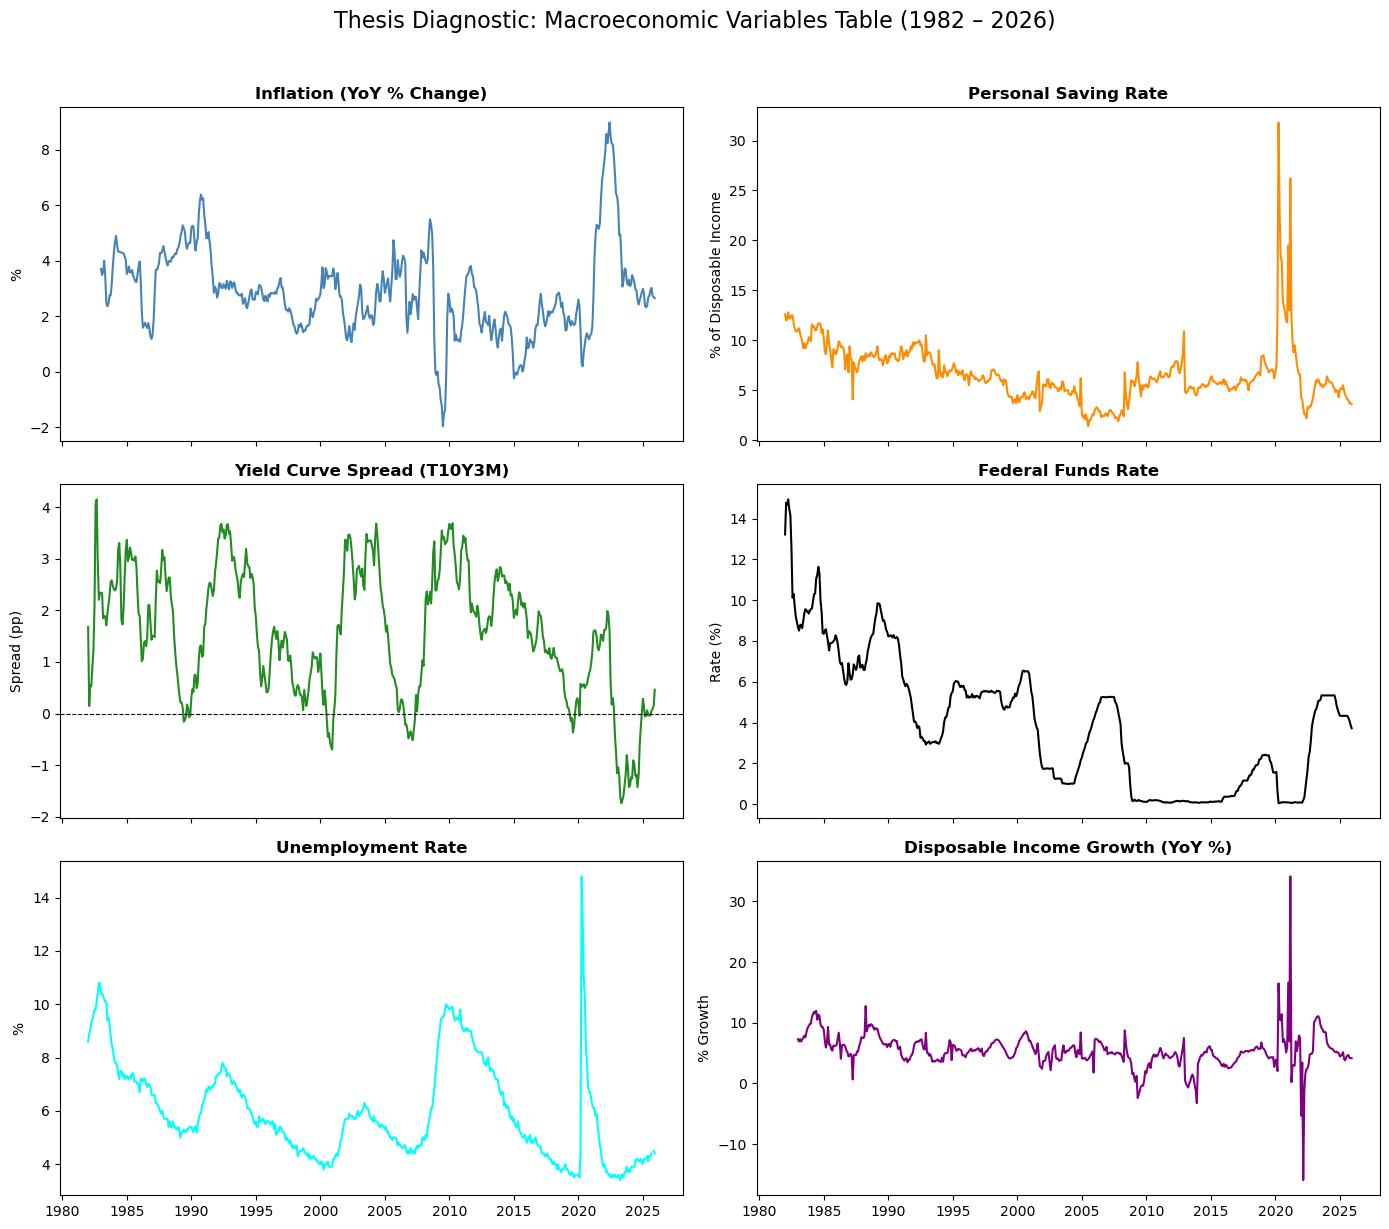

In [32]:
import matplotlib.pyplot as plt

# 1. Setup the 3x2 Grid
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
ax = axes.flatten()  # This turns the 3x2 matrix into a simple list of 6 items

# Row 1: Inflation & Savings
# Using % Change for CPI (Inflation) makes it a better diagnostic
ax[0].plot(df_final["observation_date"], df_final["CPIAUCSL"].pct_change(12)*100, color="steelblue")
ax[0].set_title("Inflation (YoY % Change)", fontweight="bold")
ax[0].set_ylabel("%")

ax[1].plot(df_final["observation_date"], df_final["PSAVERT"], color="darkorange")
ax[1].set_title("Personal Saving Rate", fontweight="bold")
ax[1].set_ylabel("% of Disposable Income")

# Row 2: Yield Curve & Fed Funds Rate
ax[2].plot(df_final["observation_date"], df_final["T10Y3M"], color="forestgreen")
ax[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
ax[2].set_title("Yield Curve Spread (T10Y3M)", fontweight="bold")
ax[2].set_ylabel("Spread (pp)")

ax[3].plot(df_final["observation_date"], df_final["DFF"], color="black")
ax[3].set_title("Federal Funds Rate", fontweight="bold")
ax[3].set_ylabel("Rate (%)")

# Row 3: Unemployment & Income Growth
ax[4].plot(df_final["observation_date"], df_final["UNRATE"], color="cyan")
ax[4].set_title("Unemployment Rate", fontweight="bold")
ax[4].set_ylabel("%")

# Using % Change for Income (Real-ish growth)
ax[5].plot(df_final["observation_date"], df_final["DSPI"].pct_change(12)*100, color="purple")
ax[5].set_title("Disposable Income Growth (YoY %)", fontweight="bold")
ax[5].set_ylabel("% Growth")

# Clean up layout
fig.suptitle("Thesis Diagnostic: Macroeconomic Variables Table (1982 – 2026)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Stationarity & Autocorrelation Checks

### 2.1 Transform CPI → Annualised Monthly Inflation Rate

The raw CPI is a **price level index** (baseline 1982–1984 = 100), not an inflation rate.
To convert it into a usable inflation series we apply three steps:

**Step 1 — Log difference** instead of a regular difference, because we care about *proportional* changes in prices, not absolute ones. A 10-point increase from 100 to 110 (10% inflation) is very different from a 10-point increase from 300 to 310 (3.3% inflation). The log difference handles this correctly:

$$\ln(CPI_t) - \ln(CPI_{t-1}) = \ln\left(\frac{CPI_t}{CPI_{t-1}}\right) \approx \text{monthly growth rate (decimal)}$$

**Step 2 — Multiply by 100** to convert the decimal into a percentage point (e.g. `0.003` → `0.3%`).

**Step 3 — Multiply by 12** to annualise the monthly rate, making it directly comparable to how inflation is reported in policy discussions and the news (e.g. the Fed's 2% annual target).

Steps 2 and 3 are combined into a single ×1200 factor:

$$\text{Inflation}_t = \left[\ln(CPI_t) - \ln(CPI_{t-1})\right] \times 1200$$

The resulting series can be interpreted as: *"if CPI kept growing at this month's rate for a full year, what would the annual inflation rate be?"*


Additionally, FFF and DSPI variables are "Integrated of Order 1" ($I(1)$), meaning they trend upward forever. Using them in levels leads to spurious regressions. Log-differencing makes them stationary ($I(0)$) and represents economic growth/inflation. --> DO THE COINTEGRATION TEST

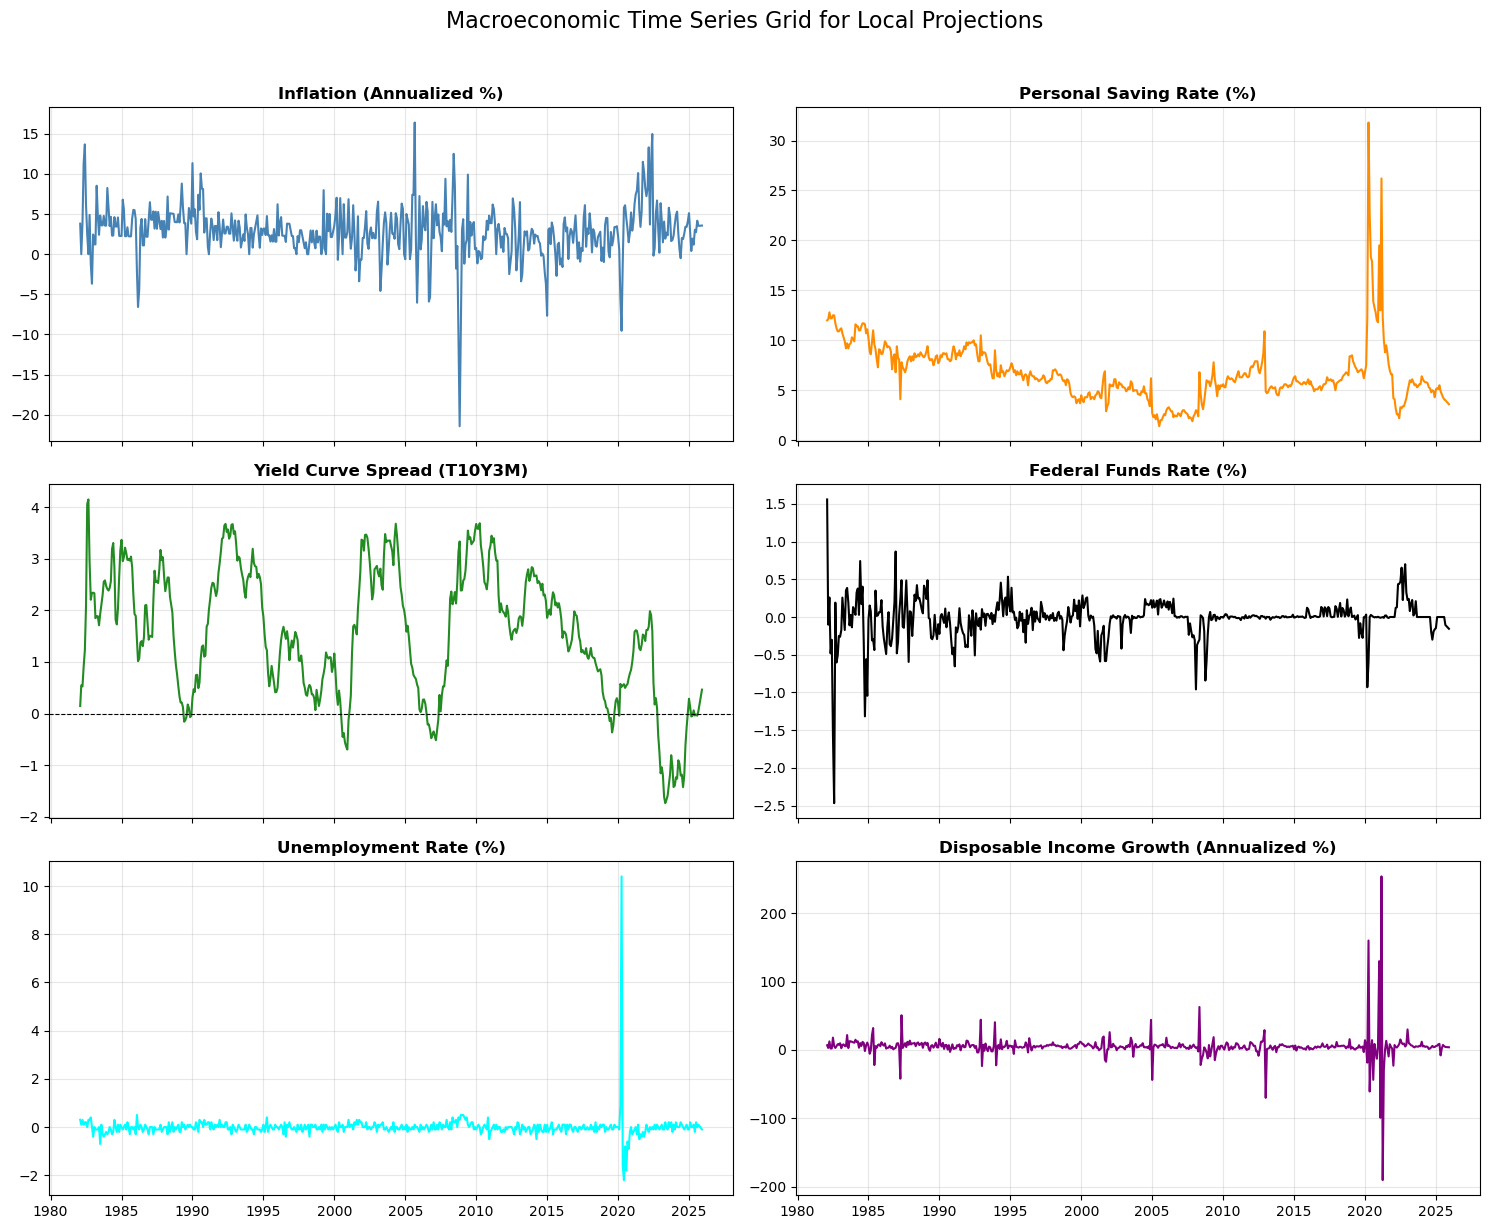

In [33]:
import numpy as np

# 1. Transform CPI to Inflation Rate (Log-Difference)
df_final["CPI"] = (np.log(df_final["CPIAUCSL"]) - np.log(df_final["CPIAUCSL"].shift(1))) * 1200

# 2. Transform DSPI to Growth Rate (Log-Difference)
# Same logic as Inflation: Annualized growth rate
df_final["DPI_Growth"] = (np.log(df_final["DSPI"]) - np.log(df_final["DSPI"].shift(1))) * 1200

# 3. Transform DFF and UNRATE (Optional: First Difference)
# While rates are already %, taking the difference (t - t-1)
# is standard for Local Projections to ensure the series is stationary.
df_final["d_DFF"] = df_final["DFF"].diff()
df_final["d_UNRATE"] = df_final["UNRATE"].diff()

# Clean up any NaNs created by shift/diff
df_final = df_final.dropna().reset_index(drop=True)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
ax = axes.flatten()

# Row 1: The Primary Variables
ax[0].plot(df_final["observation_date"], df_final["CPI"], color="steelblue")
ax[0].set_title("Inflation (Annualized %)", fontweight="bold")

ax[1].plot(df_final["observation_date"], df_final["PSAVERT"], color="darkorange")
ax[1].set_title("Personal Saving Rate (%)", fontweight="bold")

# Row 2: Monetary Policy & Yield Curve
ax[2].plot(df_final["observation_date"], df_final["T10Y3M"], color="forestgreen")
ax[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
ax[2].set_title("Yield Curve Spread (T10Y3M)", fontweight="bold")

ax[3].plot(df_final["observation_date"], df_final["d_DFF"], color="black")
ax[3].set_title("Federal Funds Rate (%)", fontweight="bold")

# Row 3: Labor Market & Real Income
ax[4].plot(df_final["observation_date"], df_final["d_UNRATE"], color="cyan")
ax[4].set_title("Unemployment Rate (%)", fontweight="bold")

ax[5].plot(df_final["observation_date"], df_final["DPI_Growth"], color="purple")
ax[5].set_title("Disposable Income Growth (Annualized %)", fontweight="bold")

# Formatting for thesis
for a in ax:
    a.grid(True, alpha=0.3)
    a.tick_params(labelsize=10)

fig.suptitle("Macroeconomic Time Series Grid for Local Projections", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Augmented Dickey-Fuller (ADF) Tests

**H₀:** Series has a unit root (non-stationary).  
Reject H₀ if the p-value < 0.05.

In [34]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, name, regression="c"):
    result = adfuller(series.dropna(), autolag="AIC", regression=regression)
    print(f"=== ADF Test: {name} ===")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Lags used      : {result[2]}")
    print(f"  Critical values: ", {k: f"{v:.3f}" for k, v in result[4].items()})
    conclusion = "Reject H₀ — stationary" if result[1] < 0.05 else "Fail to reject H₀ — non-stationary"
    print(f"  Conclusion     : {conclusion}\n")

# --- Original Variables ---
run_adf(df_final["CPI"], "Inflation", regression="c")
run_adf(df_final["PSAVERT"], "Personal Saving Rate", regression="c")
run_adf(df_final["T10Y3M"], "Yield Curve Spread", regression="n")

# --- New Control Variables ---
# Fed Funds Rate: Use 'c' for drift
run_adf(df_final["d_DFF"], "Federal Funds Rate", regression="c")

# Unemployment: Use 'c' for drift
run_adf(df_final["d_UNRATE"], "Unemployment Rate", regression="c")

# Disposable Income Growth: Use 'c' for drift (non-zero mean growth)
run_adf(df_final["DPI_Growth"], "DPI Growth (Log-Diff)", regression="c")

=== ADF Test: Inflation ===
  Test Statistic : -4.1145
  p-value        : 0.0009
  Lags used      : 14
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Personal Saving Rate ===
  Test Statistic : -3.4604
  p-value        : 0.0091
  Lags used      : 13
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Yield Curve Spread ===
  Test Statistic : -2.2204
  p-value        : 0.0254
  Lags used      : 9
  Critical values:  {'1%': '-2.570', '5%': '-1.942', '10%': '-1.616'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Federal Funds Rate ===
  Test Statistic : -7.4231
  p-value        : 0.0000
  Lags used      : 4
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Unemployment Rate ===
  Test Statistic : -13.2866
  p-value        : 0.0000
  Lags used      : 

All series reject H0, and thus are stationry!

### 2.3 ACF & PACF Plots

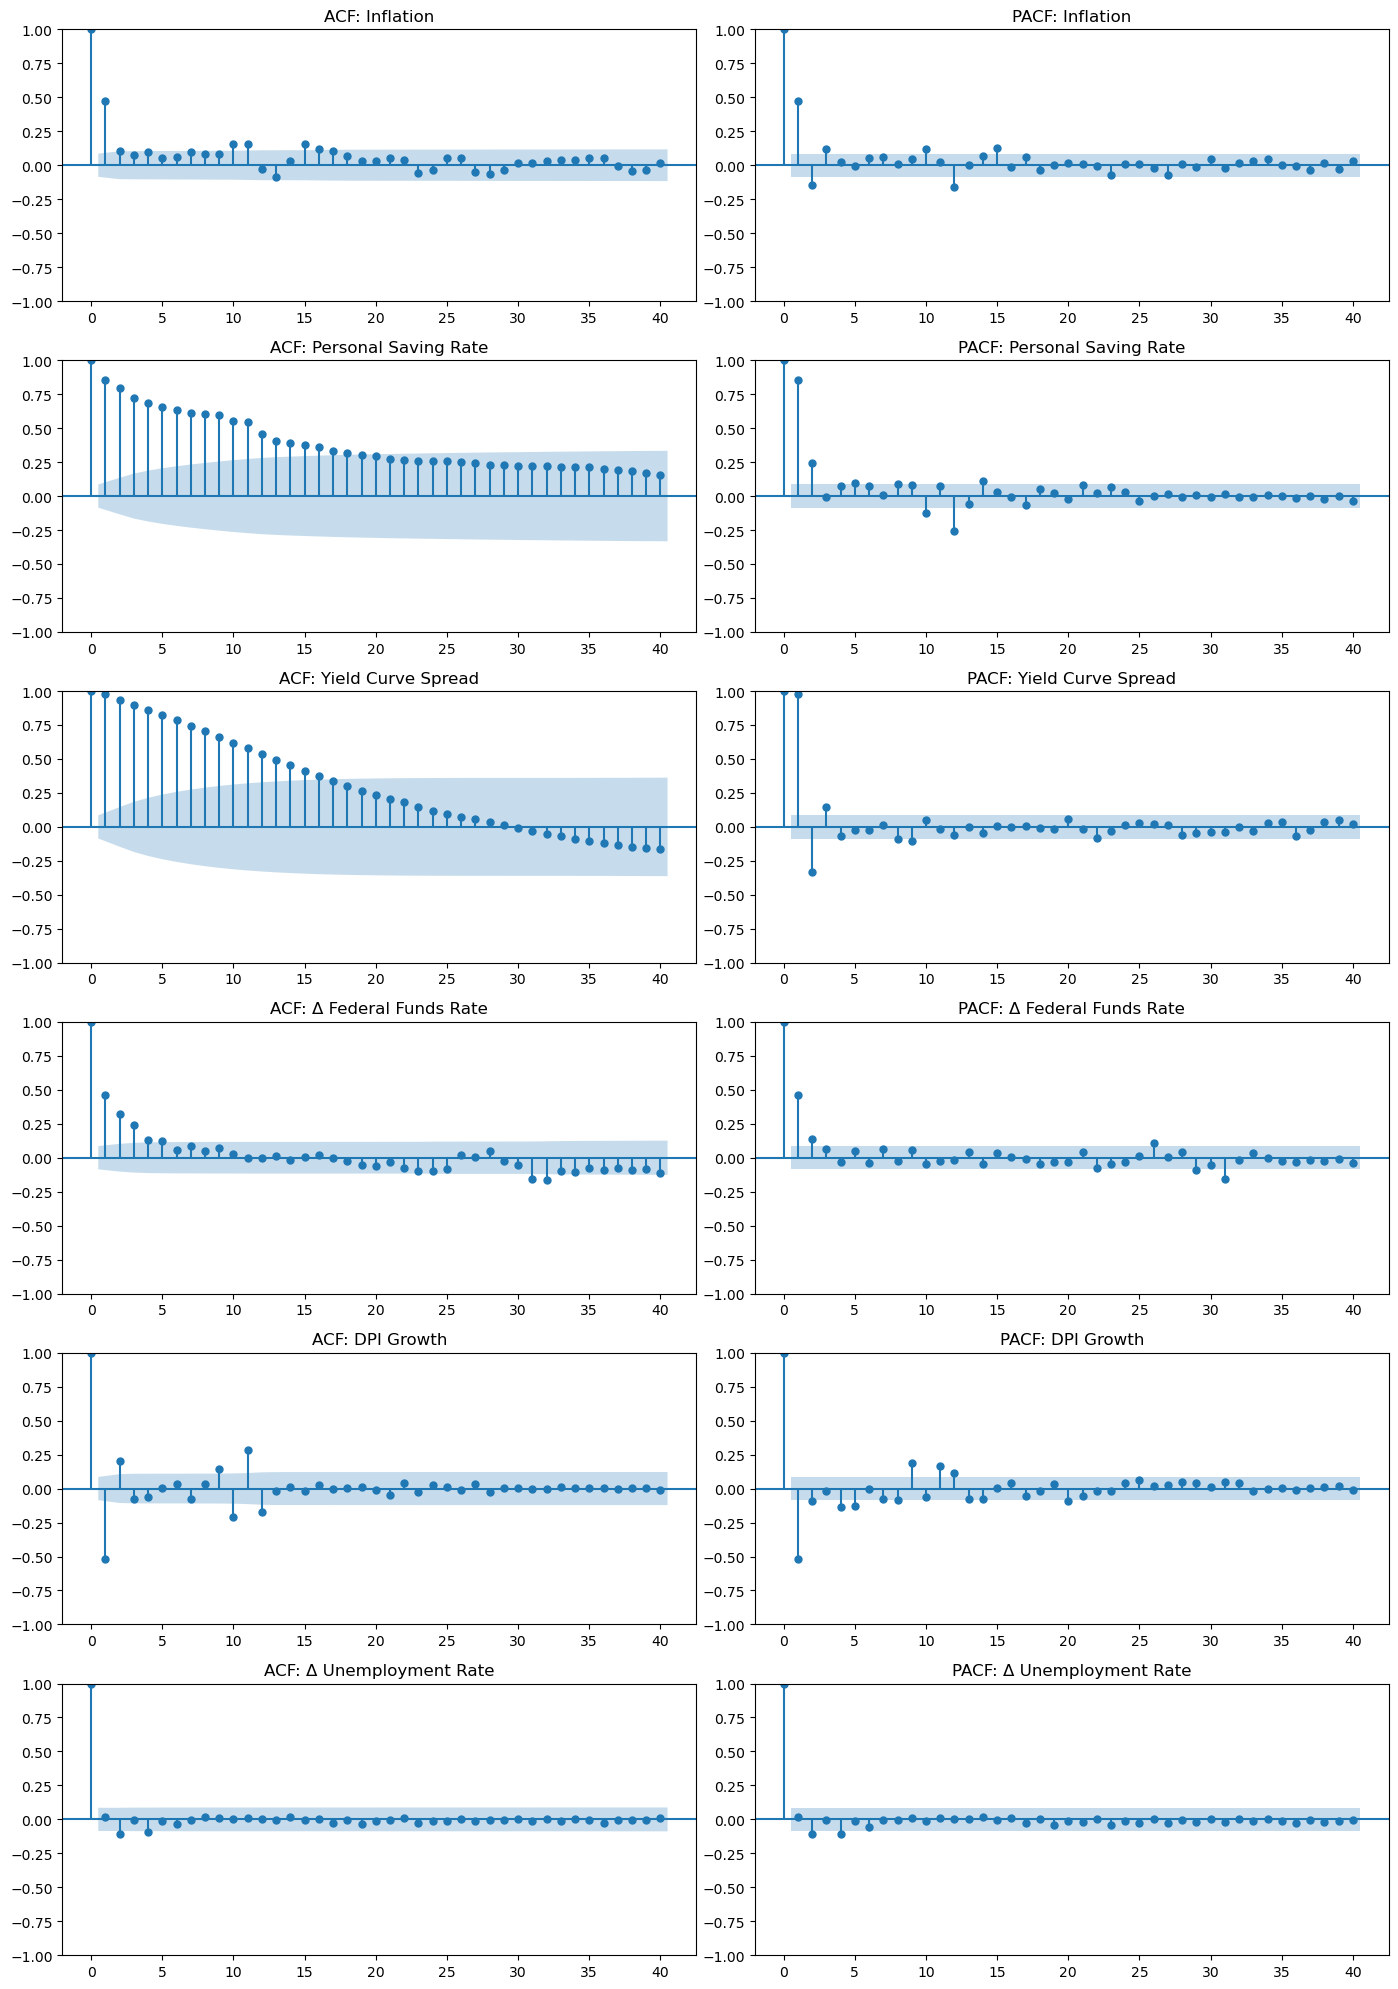

In [35]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Change to 6 rows to fit all 6 variables (ACF in col 1, PACF in col 2)
fig, axes = plt.subplots(6, 2, figsize=(14, 20))

series_list = [
    (df_final["CPI"],   "Inflation"),
    (df_final["PSAVERT"],     "Personal Saving Rate"),
    (df_final["T10Y3M"],      "Yield Curve Spread"),
    (df_final["d_DFF"],       "Δ Federal Funds Rate"),
    (df_final["DPI_Growth"],  "DPI Growth"), # Ensure you use the growth/stationary version
    (df_final["d_UNRATE"],    "Δ Unemployment Rate")
]

for i, (series, name) in enumerate(series_list):
    # Drop NaNs to avoid errors in ACF/PACF calculation
    clean_series = series.dropna()

    # axes[i, 0] is the left column (ACF)
    plot_acf(clean_series,  ax=axes[i, 0], lags=40, title=f"ACF: {name}")

    # axes[i, 1] is the right column (PACF)
    plot_pacf(clean_series, ax=axes[i, 1], lags=40, title=f"PACF: {name}")

plt.tight_layout()
plt.show()

Here we have some issues... We see that both the savings rate and the Yield Curve spread are highly persistent... We will address this.

## 3. Local Projections (Jordà 2005)

### 3.1 Setup

The Local Projection estimator runs a separate OLS regression for each horizon h = 0, 1, …, 18. h ∈ [12, 18] is the economically meaningful window

$PSAVERT_{t+h} - PSAVERT_{t-1} = \alpha^h + \beta^h \cdot SHOCK_t + \sum_{l=1}^{p} \Omega_l^h \mathbf{X}_{t-l} + \varepsilon_{t+h}$

Where:
- The **left-hand side** is the cumulative change in the personal saving rate between t−1 and t+h
- $\mathbf{X}_{t-l}$ are lags of all control variables (Inflation, PSAVERT, T10Y3M, ΔDFF, ΔUNRATE, DPI growth)
- $\beta^h$ traced across horizons gives the **impulse response function (IRF)**
- Standard errors: **HAC-robust (HC1)** to correct for heteroskedasticity and serial correlation

The number of lags p is selected by minimising BIC on a VAR in levels.

---

### Two shock experiments

**Experiment 1 — Inversion dummy ()**
-  $\mathbf{1} = [T10Y3M_t < 0]$
- Captures the discrete event of yield curve inversion
- IRF interpreted as: pp change in saving rate following a month when the curve first inverts

**Experiment 2 — Spread level ()**
-  $= T10Y3M_t$ (continuous, in percentage points)
- IRF scaled by **−10** → response to a 10 bp *decline* in the spread
- Captures the marginal effect of yield curve flattening/steepening

### 3.2 Build the Regression Dataset

#### 3.2.1. Adding recession dummies

In [ ]:
# NBER recession months — add this to df_lp
# Download from FRED: USREC
recession = pd.read_csv(data_path + "/input/USREC.csv")
recession["observation_date"] = pd.to_datetime(recession["observation_date"])

In [ ]:
##############################################################################
# 3.2 Construct LP dataset (Full Model with 6 Variables)
##############################################################################

H = 18  # maximum horizon (should be within 12-18)

# 1. Initialize with core and new stationary variables (excluding USREC for now)
cols_to_keep = [
    "observation_date", "CPI", "PSAVERT", "T10Y3M",
    "d_DFF", "d_UNRATE", "DPI_Growth"
]
df_lp = df_final[cols_to_keep].copy()

# --- Experiment 1: Inversion dummy ---
df_final["spread"]     = df_final["GS10"] - df_final["TB3MS"]
df_final["D_inversion"] = (df_final["spread"] < 0).astype(int)
df_final["NegSpread"]   = -df_final["spread"]

# --- Dummies: COVID and Recession ---
df_lp["D_covid"] = ((df_lp["observation_date"] >= "2020-03-01") &
                    (df_lp["observation_date"] <= "2021-06-01")).astype(int)

# Merge recession data into df_lp (defined in cell 6DLdL0V02doD)
df_lp = df_lp.merge(recession[['observation_date', 'USREC']], on="observation_date", how="left")
df_lp.rename(columns={"USREC": "D_recession"}, inplace=True)

# Fill NaNs created by merge (periods outside NBER recession) with 0
df_lp["D_recession"] = df_lp["D_recession"].fillna(0).astype(int)

# --- Lag matrix: p lags of ALL variables ---

# This ensures we control for the past dynamics of the entire system
vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]

for lag in range(1, p_bic + 1):
    for var in vars_to_lag:
        df_lp[f"{var}_L{lag}"] = df_lp[var].shift(lag)

# --- Outcome variables: cumulative change in PSAVERT at each horizon h ---
# PSAVERT_{t+h} - PSAVERT_{t-1}
df_lp["PSAVERT_Lminus1"] = df_lp["PSAVERT"].shift(1)

for h in range(0, H + 1):
    # This captures the change from the month PRIOR to the shock (t-1) to the horizon (t+h)
    df_lp[f"y_h{h}"] = df_lp["PSAVERT"].shift(-h) - df_lp["PSAVERT_Lminus1"]

# Drop NaNs created by lags (at the start) and horizons (at the end)
df_lp = df_lp.dropna().reset_index(drop=True)

print(f"LP dataset shape after dropping NAs: {df_lp.shape}")
print(f"Lags used (p): {p_bic}")
df_lp.head()

LP dataset shape after dropping NAs: (499, 48)
Lags used (p): 2


,observation_date,CPI,PSAVERT,T10Y3M,d_DFF,d_UNRATE,DPI_Growth,D_inversion,D_covid,D_recession,...,y_h15,y_h16,y_h17,y_h18,y_h19,y_h20,y_h21,y_h22,y_h23,y_h24
0,1982-04-01,3.795470,12.8,0.527143,0.259258,0.3,12.486270,0,0,1,...,-2.4,-2.9,-2.5,-2.4,-1.8,-2.0,-2.2,-0.5,-0.7,-0.7
1,1982-05-01,11.314908,12.2,0.908500,-0.482161,0.1,2.143169,0,0,1,...,-3.6,-3.2,-3.1,-2.5,-2.7,-2.9,-1.2,-1.4,-1.4,-1.8
2,1982-06-01,13.685996,12.2,1.220909,-0.302172,0.2,2.139348,0,0,1,...,-2.6,-2.5,-1.9,-2.1,-2.3,-0.6,-0.8,-0.8,-1.2,-1.2
3,1982-07-01,6.169679,12.5,2.082857,-1.565892,0.2,18.007615,0,0,1,...,-2.5,-1.9,-2.1,-2.3,-0.6,-0.8,-0.8,-1.2,-1.2,-0.8
4,1982-08-01,2.459017,12.5,4.057727,-2.467742,0.0,5.666840,0,0,1,...,-2.2,-2.4,-2.6,-0.9,-1.1,-1.1,-1.5,-1.5,-1.1,-0.8


### 3.3 Run Local Projections

In [ ]:
import statsmodels.api as sm

##############################################################################
# 3.3  Local Projection regressions — Updated with full controls
##############################################################################

# 1. Update lag_cols to include the 3 new variables
lag_cols = []
vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]

for l in range(1, p_bic + 1):
    for var in vars_to_lag:
        lag_cols.append(f"{var}_L{l}")

# 2. Define Contemporary Controls (Slow variables: PSAVERT, Inflation, UNRATE, Income)
# We assume these do not react to the Yield Curve within the same month
contemp_controls = ["PSAVERT", "CPI", "d_UNRATE", "DPI_Growth"]

# 3. Define Policy & Outlier Controls
# d_DFF is included here as a contemporaneous control if we assume
# the Fed reacts to the economy faster than the economy reacts to the Fed.
policy_controls = ["d_DFF"]
outlier_controls = ["D_covid", "D_recession"]

# Create the pre-2020 dataset
df_lp_pre2020 = df_lp.query("observation_date < '2020-01-01'").copy()
# Remove D_covid column if it exists in the pre-2020 data as it won't be relevant
if "D_covid" in df_lp_pre2020.columns: # Check if column exists
    df_lp_pre2020 = df_lp_pre2020.drop(columns=["D_covid"])

# --- Helper function to run LP for a given dataset and SE type ---
def run_lp_model(data, se_type, H=H):
    results_exp1_model = []
    results_exp2_model = []

    # Controls available in the current dataset (df_lp_pre2020 might not have D_covid)
    avail_outlier_controls = [c for c in outlier_controls if c in data.columns]

    for h in range(0, H + 1):
        y = data[f"y_h{h}"]

        if se_type == "HC1":
            fit_kwargs = {"cov_type": "HC1"}
        else: # Newey-West (HAC)
            # Maxlags for HAC should be related to the number of horizons
            fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": 8}} # Adjust maxlags to be at most h+1 for robustness

        # --- Experiment 1: Inversion dummy ---
        cols1 = ["D_inversion"] + contemp_controls + policy_controls + avail_outlier_controls + lag_cols
        # Filter columns that actually exist in the dataframe
        cols1 = [c for c in cols1 if c in data.columns]
        X1 = sm.add_constant(data[cols1])

        model1 = sm.OLS(y, X1).fit(**fit_kwargs)
        coef1 = model1.params["D_inversion"]
        # Need p-value for make_latex_irf_table later
        pval1 = model1.pvalues["D_inversion"]
        ci1 = model1.conf_int(alpha=0.10).loc["D_inversion"]
        results_exp1_model.append({"h": h, "coef": coef1, "ci_low": ci1[0], "ci_high": ci1[1], "pval": pval1, "model": model1})

        # --- Experiment 2: 1pp decline in YC Spread ---
        cols2 = ["T10Y3M"] + contemp_controls + policy_controls + avail_outlier_controls + lag_cols
        # Filter columns that actually exist in the dataframe
        cols2 = [c for c in cols2 if c in data.columns]
        X2 = sm.add_constant(data[cols2])

        model2 = sm.OLS(y, X2).fit(**fit_kwargs)
        coef2 = model2.params["T10Y3M"]
        # Need p-value for make_latex_irf_table later
        pval2 = model2.pvalues["T10Y3M"]
        ci2 = model2.conf_int(alpha=0.10).loc["T10Y3M"]

        # Scale by -1 for a 1 percentage point decline
        shock_size = -1
        results_exp2_model.append({
            "h": h,
            "coef": coef2 * shock_size,
            "ci_low": min(ci2[0] * shock_size, ci2[1] * shock_size), # Ensure low/high are correct after scaling by negative
            "ci_high": max(ci2[0] * shock_size, ci2[1] * shock_size),
            "pval": pval2, "model": model2
        })
    return pd.DataFrame(results_exp1_model), pd.DataFrame(results_exp2_model), [r["model"] for r in results_exp1_model], [r["model"] for r in results_exp2_model]

# --- Run all four models ---
print("Running Model 1 (HC1, Full Sample)...")
irf1_m1, irf2_m1, mods1_m1, mods2_m1 = run_lp_model(df_lp, "HC1")

print("Running Model 2 (HC1, Pre-2020)...")
irf1_m2, irf2_m2, mods1_m2, mods2_m2 = run_lp_model(df_lp_pre2020, "HC1")

print("Running Model 3 (Newey-West, Full Sample)...")
irf1_m3, irf2_m3, mods1_m3, mods2_m3 = run_lp_model(df_lp, "HAC")

print("Running Model 4 (Newey-West, Pre-2020)...")
irf1_m4, irf2_m4, mods1_m4, mods2_m4 = run_lp_model(df_lp_pre2020, "HAC")

print("All four models estimated successfully.")
print("Experiment 1 (Inversion) Model 1 Head:")
print(irf1_m1.head())


Running Model 1 (HC1, Full Sample)...
Running Model 2 (HC1, Pre-2020)...
Running Model 3 (Newey-West, Full Sample)...
Running Model 4 (Newey-West, Pre-2020)...
All four models estimated successfully.
Experiment 1 (Inversion) Model 1 Head:
   h          coef        ci_low       ci_high      pval  \
0  0 -3.358425e-15 -5.523935e-15 -1.192914e-15  0.010743   
1  1  1.292143e-01 -1.804159e-01  4.388444e-01  0.492444   
2  2  7.714519e-01 -3.928405e-01  1.935744e+00  0.275771   
3  3  3.742204e-01 -5.249372e-01  1.273378e+00  0.493614   
4  4  8.407192e-02 -7.271295e-01  8.952733e-01  0.864640   

                                               model  
0  <statsmodels.regression.linear_model.Regressio...  
1  <statsmodels.regression.linear_model.Regressio...  
2  <statsmodels.regression.linear_model.Regressio...  
3  <statsmodels.regression.linear_model.Regressio...  
4  <statsmodels.regression.linear_model.Regressio...  


### 3.4 Plot Impulse Response Functions

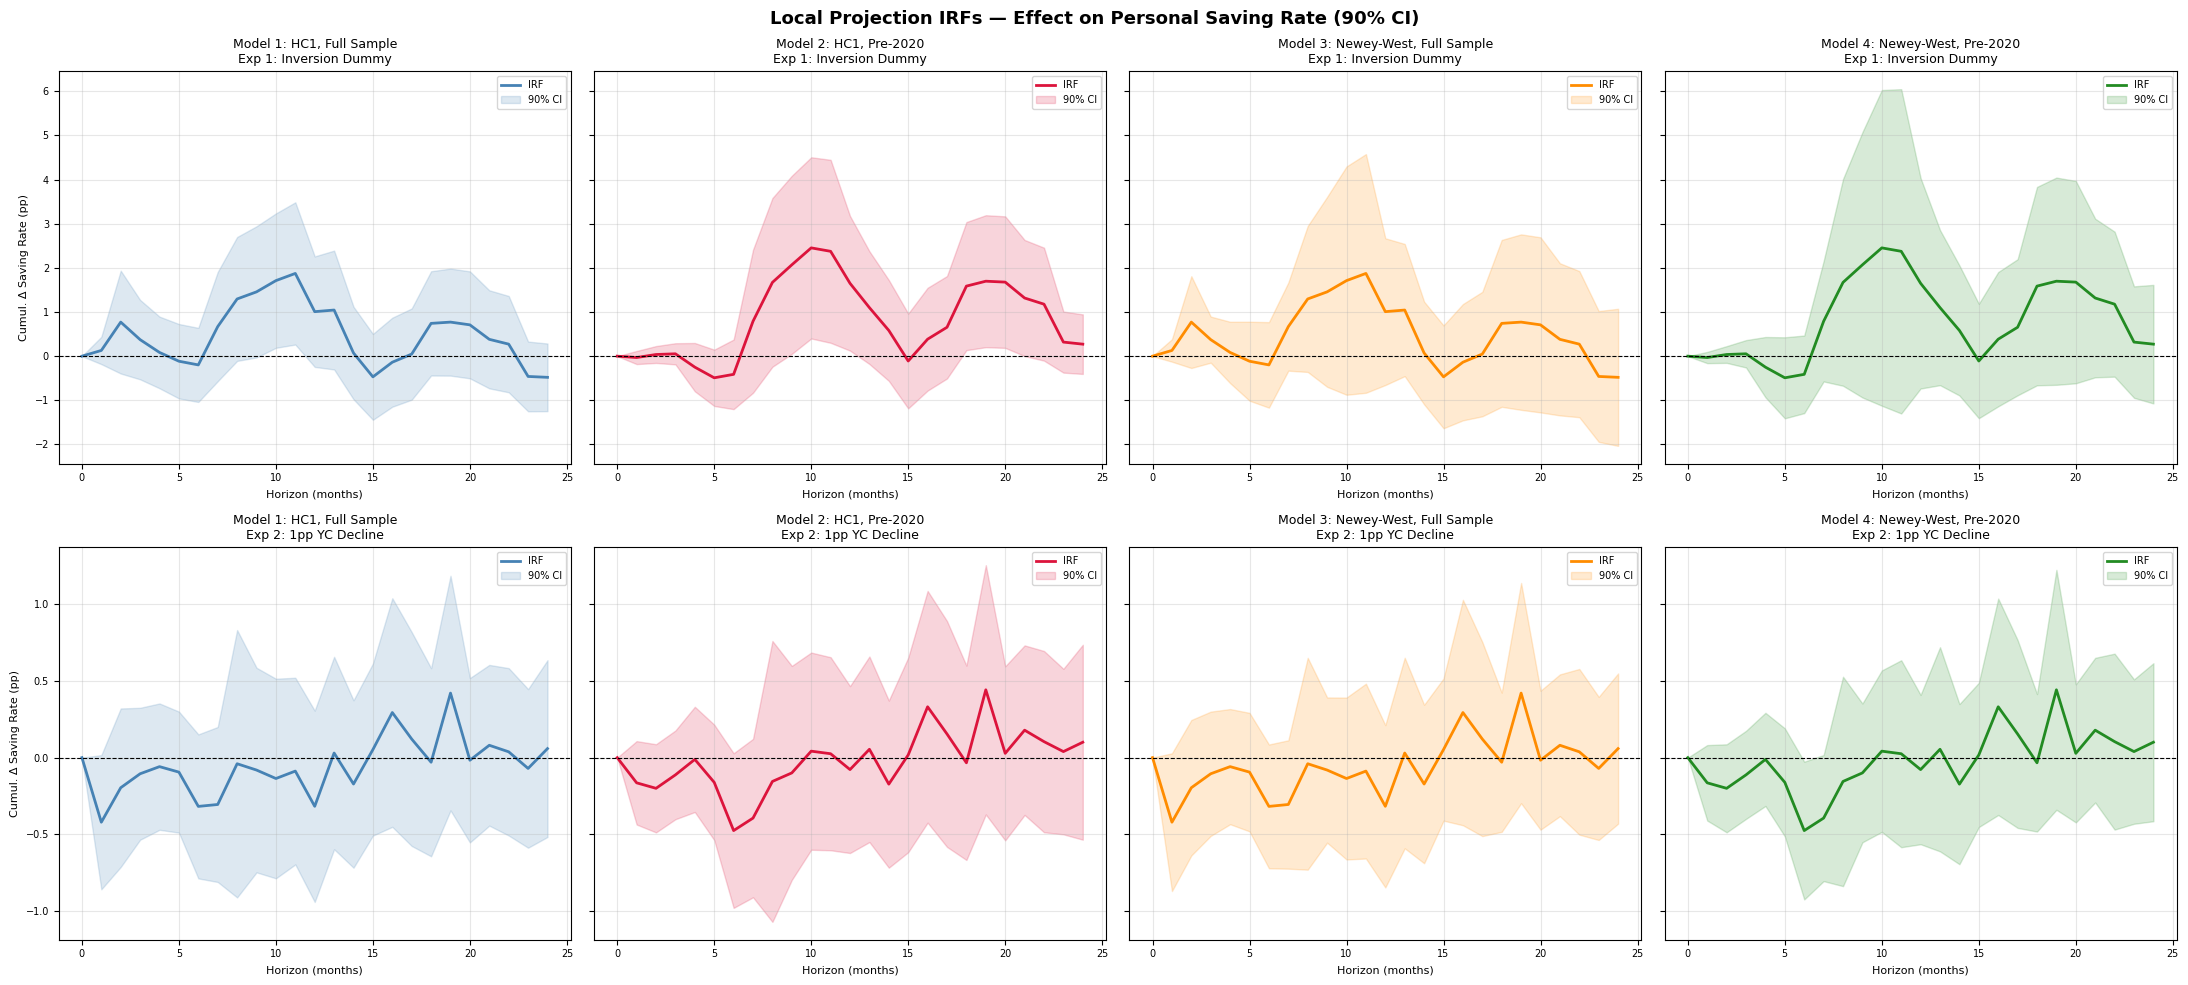


  Experiment 1: Yield Curve Inversion (Dummy)
  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds
         M1 coef  M1 ci_low  M1 ci_high  M2 coef  M2 ci_low  M2 ci_high  M3 coef  M3 ci_low  M3 ci_high  M4 coef  M4 ci_low  M4 ci_high
Horizon                                                                                                                                
0         -0.000     -0.000      -0.000   -0.000     -0.000       0.000   -0.000     -0.000       0.000   -0.000     -0.000       0.000
1          0.129     -0.180       0.439   -0.031     -0.179       0.117    0.129     -0.125       0.384   -0.031     -0.158       0.096
2          0.771     -0.393       1.936    0.038     -0.154       0.229    0.771     -0.268       1.811    0.038     -0.152       0.227
3          0.374     -0.525       1.273    0.054     -0.186       0.293    0.374     -0.148       0.896    0.054     -0.257       0.364
4          0.084     -0.727       0.895   -0.249     -0.796       0.2

In [ ]:
# 3.7  IRF Plots — one figure per model, and summary tables

model_names = [
    "Model 1: HC1, Full Sample",
    "Model 2: HC1, Pre-2020",
    "Model 3: Newey-West, Full Sample",
    "Model 4: Newey-West, Pre-2020",
]

irfs_exp1 = [irf1_m1, irf1_m2, irf1_m3, irf1_m4]
irfs_exp2 = [irf2_m1, irf2_m2, irf2_m3, irf2_m4]

colors = ["steelblue", "crimson", "darkorange", "forestgreen"]

# --- IRF plots: 2 rows (one per experiment) x 4 cols (one per model) ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey="row")

for col, (m_name, color) in enumerate(zip(model_names, colors)):
    for row, (irfs, exp_label) in enumerate([
        (irfs_exp1, "Exp 1: Inversion Dummy"),
        (irfs_exp2, "Exp 2: 1pp YC Decline"),
    ]):
        ax  = axes[row, col]
        irf = irfs[col]

        ax.plot(irf["h"], irf["coef"], color=color, linewidth=2, label="IRF")
        ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                        alpha=0.18, color=color, label="90% CI")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{m_name}\n{exp_label}", fontsize=9)
        ax.set_xlabel("Horizon (months)", fontsize=8)
        if col == 0:
            ax.set_ylabel("Cumul. \u0394 Saving Rate (pp)", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

plt.suptitle("Local Projection IRFs — Effect on Personal Saving Rate (90% CI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


##############################################################################
# 3.8  Summary Tables — IRF Coefficients and CIs for all models
##############################################################################

def make_summary_table(irfs, model_names, experiment_name):
    """
    Combines IRF results from all models into one table.
    For each horizon h, shows coef, ci_low, ci_high for every model.
    """
    rows = []
    for h in range(len(irfs[0])):
        row = {"Horizon": h}
        for irf, name in zip(irfs, model_names):
            short = name.replace("Model ", "M").split(":")[0].strip()
            row[f"{short} coef"]    = round(irf.loc[h, "coef"],    3)
            row[f"{short} ci_low"]  = round(irf.loc[h, "ci_low"],  3)
            row[f"{short} ci_high"] = round(irf.loc[h, "ci_high"], 3)
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Horizon")

    print(f"\n{'='*80}")
    print(f"  {experiment_name}")
    print(f"  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds")
    print(f"{'='*80}")
    print(df.to_string())
    return df


table_exp1 = make_summary_table(
    irfs            = irfs_exp1,
    model_names     = model_names,
    experiment_name = "Experiment 1: Yield Curve Inversion (Dummy)"
)

table_exp2 = make_summary_table(
    irfs            = irfs_exp2,
    model_names     = model_names,
    experiment_name = "Experiment 2: 1pp Decline in Yield Curve Spread"
)


In [ ]:
##############################################################################
# 3.9  Joint Chi-Squared Test — Lean Spec, All Four Models
#
# Tests H0: beta^h = 0 for ALL h = 1, ..., 24 simultaneously.
#
# Method: chi2 = sum of z^2 where z = coef / SE
#         SE back-calculated from 90% CI: SE = (ci_high - ci_low) / (2 * 1.645)
# Under H0 this is distributed chi2(24).
#
# h=0 excluded — Cholesky ordering makes beta^0 = 0 by construction.
##############################################################################

from scipy import stats

H_test = 24

def pval_stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def joint_chi2_test(irf, model_name, experiment_name, H_test=24):
    subset = irf[irf["h"].between(1, H_test)].copy()

    # Back out SE from 90% CI: SE = (ci_high - ci_low) / (2 * z_0.05)
    subset["se"]     = (subset["ci_high"] - subset["ci_low"]) / (2 * 1.6449)
    subset["z_stat"] = subset["coef"] / subset["se"]
    subset["pval_z"] = 2 * (1 - stats.norm.cdf(abs(subset["z_stat"])))

    chi2    = (subset["z_stat"] ** 2).sum()
    df      = len(subset)
    p_joint = stats.chi2.sf(chi2, df=df)

    print(f"\n  {model_name} | {experiment_name}")
    print(f"  {'─'*60}")
    print(f"  Horizons tested    : h = 1 to {H_test}  (n = {df})")
    print(f"  Chi2 statistic     : {chi2:.3f}")
    print(f"  Degrees of freedom : {df}")
    print(f"  Joint p-value      : {p_joint:.4f} {pval_stars(p_joint)}")

    top3 = subset.nsmallest(3, "pval_z")[["h", "coef", "se", "pval_z"]].copy()
    top3.columns = ["h", "coef", "se", "pval"]
    print(f"  Top 3 horizons     :")
    print(top3.to_string(index=False))

    return {"model": model_name, "experiment": experiment_name,
            "chi2": round(chi2, 3), "df": df,
            "p_joint": round(p_joint, 4), "stars": pval_stars(p_joint)}


# --- Run for all four models x two experiments ---
print("=" * 70)
print("  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)")
print("=" * 70)

joint_results = []

for irf, m_name in [
    (irf1_m1, "Model 1: HC1, Full"),
    (irf1_m2, "Model 2: HC1, Pre-2020"),
    (irf1_m3, "Model 3: HAC, Full"),
    (irf1_m4, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 1: Inversion Dummy"))

print()

for irf, m_name in [
    (irf2_m1, "Model 1: HC1, Full"),
    (irf2_m2, "Model 2: HC1, Pre-2020"),
    (irf2_m3, "Model 3: HAC, Full"),
    (irf2_m4, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 2: 1pp YC Decline"))


# --- Summary pivot table ---
print(f"\n\n{'='*70}")
print("  JOINT TEST SUMMARY")
print(f"  H0: beta^h = 0 for all h = 1,...,24")
print(f"  * p<0.10  ** p<0.05  *** p<0.01")
print(f"{'='*70}")

summary_df = pd.DataFrame(joint_results)
summary_df["result"] = summary_df.apply(
    lambda r: f"chi2={r['chi2']:.2f}, p={r['p_joint']:.4f}{r['stars']}", axis=1
)
pivot = summary_df.pivot(index="model", columns="experiment", values="result")
print(pivot.to_string())

  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)

  Model 1: HC1, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 24.778
  Degrees of freedom : 24
  Joint p-value      : 0.4179 
  Top 3 horizons     :
 h     coef       se     pval
11 1.873742 0.979296 0.055703
10 1.711022 0.925122 0.064384
 9 1.456295 0.902838 0.106740

  Model 2: HC1, Pre-2020 | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 39.477
  Degrees of freedom : 24
  Joint p-value      : 0.0243 **
  Top 3 horizons     :
 h     coef       se     pval
10 2.452438 1.247672 0.049344
11 2.374598 1.259783 0.059440
19 1.697717 0.908534 0.061674

  Model 3: HAC, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic   

### 3.5 Lean (Reduced-Controls) Model

Reruns both LP experiments with a **parsimonious control set**: only lags of PSAVERT and T10Y3M are included, dropping the inflation, unemployment, and DPI growth controls.

**Purpose:** confirm that the IRF shape and significance are not driven by the specific choice of conditioning variables. If results are similar to the full model, the shock identification is robust to control selection.

Both experiments (inversion dummy and spread level) are re-estimated and plotted.

In [ ]:
import statsmodels.api as sm

##############################################################################
# 3.5  Local Projection regressions — Lean spec, four model variants
#
# Results stored in *_lean variables to avoid overwriting full-control results
#
# Dropped vs full spec:
#   - d_DFF (lags + contemporaneous)
#   - DPI_Growth (contemporaneous)
#
# Remaining controls:
#   Lags     : CPI, PSAVERT, T10Y3M, d_UNRATE  (p_bic lags each)
#   Contemp. : PSAVERT, CPI, d_UNRATE
#   Outliers : D_covid, D_recession
#
# Model 1: HC1 SEs,        full sample
# Model 2: HC1 SEs,        pre-2020
# Model 3: Newey-West SEs, full sample
# Model 4: Newey-West SEs, pre-2020
##############################################################################

# --- Lag columns ---
lag_cols_lean = []
vars_to_lag_lean = ["CPI", "PSAVERT", "T10Y3M", "d_UNRATE"]
for l in range(1, p_bic + 1):
    for var in vars_to_lag_lean:
        lag_cols_lean.append(f"{var}_L{l}")

# --- Control groups ---
contemp_controls_lean = ["PSAVERT", "CPI", "d_UNRATE"]
outlier_controls_lean = ["D_covid", "D_recession"]

print(f"Lean spec — lag columns ({len(lag_cols_lean)}): {lag_cols_lean}")
print(f"Full sample:     {len(df_lp)} observations")
print(f"Pre-2020 sample: {len(df_lp_pre2020)} observations")


# --- Helper ---
def run_lp_lean(data, se_type, H=H):
    res1, res2 = [], []
    avail_outlier = [c for c in outlier_controls_lean if c in data.columns]

    for h in range(0, H + 1):
        y = data[f"y_h{h}"]

        if se_type == "HC1":
            fit_kwargs = {"cov_type": "HC1"}
        else:
            fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": 8}} # or adjust to h + 1

        # Experiment 1: Inversion dummy
        cols1 = [c for c in ["D_inversion"] + contemp_controls_lean + avail_outlier + lag_cols_lean
                 if c in data.columns]
        m1  = sm.OLS(y, sm.add_constant(data[cols1])).fit(**fit_kwargs)
        ci1 = m1.conf_int(alpha=0.10).loc["D_inversion"]
        res1.append({"h": h, "coef": m1.params["D_inversion"],
                     "ci_low": ci1[0], "ci_high": ci1[1]})

        # Experiment 2: 1pp decline in YC spread
        cols2 = [c for c in ["T10Y3M"] + contemp_controls_lean + avail_outlier + lag_cols_lean
                 if c in data.columns]
        m2    = sm.OLS(y, sm.add_constant(data[cols2])).fit(**fit_kwargs)
        coef2 = m2.params["T10Y3M"]
        ci2   = m2.conf_int(alpha=0.10).loc["T10Y3M"]
        shock = -1
        res2.append({"h": h,
                     "coef":    coef2  * shock,
                     "ci_low":  min(ci2[0] * shock, ci2[1] * shock),
                     "ci_high": max(ci2[0] * shock, ci2[1] * shock)})

    return pd.DataFrame(res1), pd.DataFrame(res2)


# --- Run all four models (lean) ---
print("\nRunning Model 1 lean (HC1, Full)...")
irf1_m1_lean, irf2_m1_lean = run_lp_lean(df_lp,         "HC1")

print("Running Model 2 lean (HC1, Pre-2020)...")
irf1_m2_lean, irf2_m2_lean = run_lp_lean(df_lp_pre2020, "HC1")

print("Running Model 3 lean (Newey-West, Full)...")
irf1_m3_lean, irf2_m3_lean = run_lp_lean(df_lp,         "HAC")

print("Running Model 4 lean (Newey-West, Pre-2020)...")
irf1_m4_lean, irf2_m4_lean = run_lp_lean(df_lp_pre2020, "HAC")

print("\nAll four lean models estimated successfully.")
print("\nModel 1 lean — Experiment 1 (head):")
print(irf1_m1_lean.head())

Lean spec — lag columns (8): ['CPI_L1', 'PSAVERT_L1', 'T10Y3M_L1', 'd_UNRATE_L1', 'CPI_L2', 'PSAVERT_L2', 'T10Y3M_L2', 'd_UNRATE_L2']
Full sample:     499 observations
Pre-2020 sample: 453 observations

Running Model 1 lean (HC1, Full)...
Running Model 2 lean (HC1, Pre-2020)...
Running Model 3 lean (Newey-West, Full)...
Running Model 4 lean (Newey-West, Pre-2020)...

All four lean models estimated successfully.

Model 1 lean — Experiment 1 (head):
   h          coef        ci_low       ci_high
0  0 -1.734723e-15 -3.328934e-15 -1.405131e-16
1  1  3.882027e-02 -3.149751e-01  3.926157e-01
2  2  7.045935e-01 -4.773143e-01  1.886501e+00
3  3  3.061808e-01 -6.024905e-01  1.214852e+00
4  4  1.705260e-02 -8.010829e-01  8.351882e-01


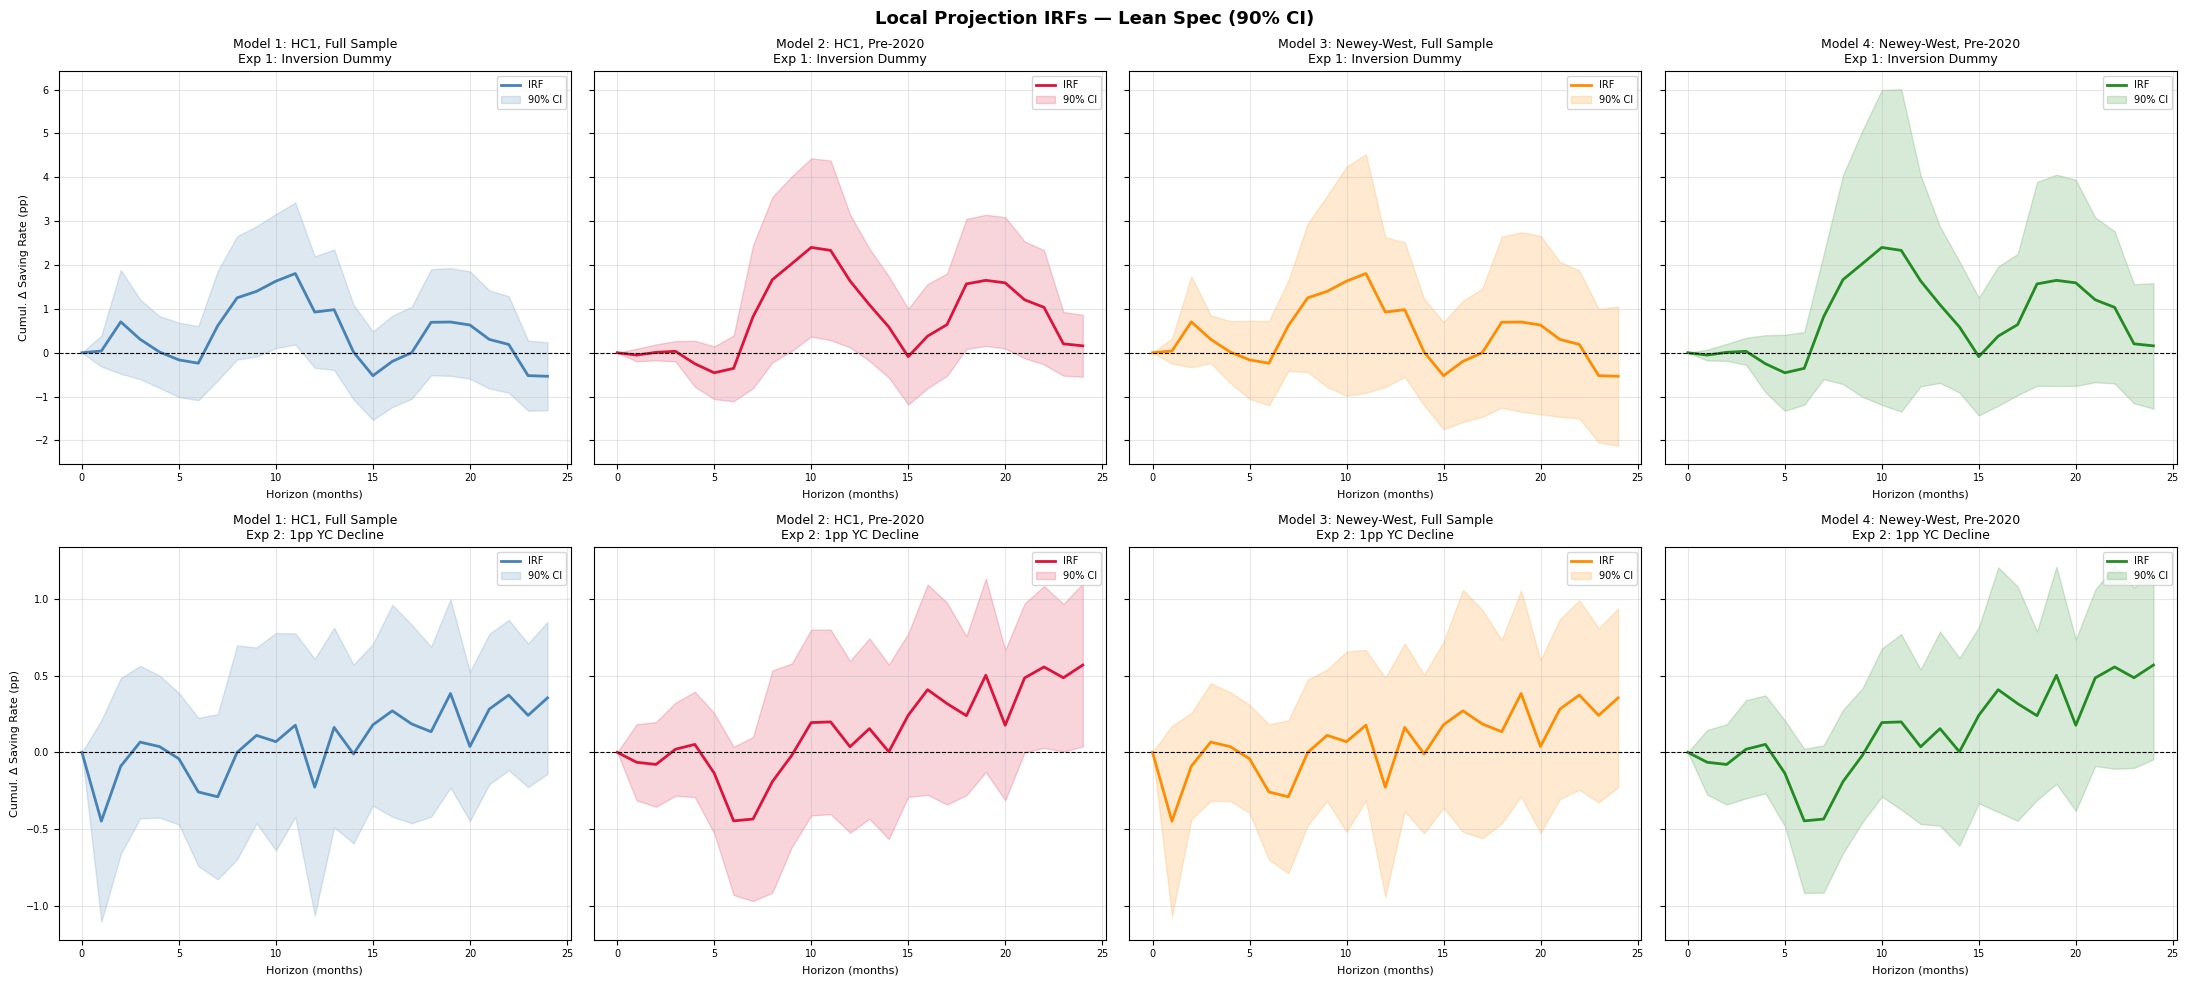


  Experiment 1: Yield Curve Inversion (Dummy) — Lean Spec
  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds
  [[coef]] = significant at 10% level (90% CI excludes zero)
           M1 coef  M1 ci_low  M1 ci_high    M2 coef  M2 ci_low  M2 ci_high M3 coef  M3 ci_low  M3 ci_high M4 coef  M4 ci_low  M4 ci_high
Horizon                                                                                                                                  
0             -0.0     -0.000      -0.000       -0.0     -0.000      -0.000    -0.0     -0.000       0.000    -0.0     -0.000      -0.000
1            0.039     -0.315       0.393     -0.053     -0.196       0.090   0.039     -0.244       0.322  -0.053     -0.177       0.071
2            0.705     -0.477       1.887      0.009     -0.173       0.191   0.705     -0.331       1.740   0.009     -0.185       0.202
3            0.306     -0.602       1.215      0.033     -0.199       0.264   0.306     -0.239       0.851   0.033     -0.

In [ ]:
##############################################################################
# 3.5.1 & 3.5.2  IRF Plots + Summary Tables — Lean spec
#
# Significance: ci_low > 0 OR ci_high < 0  →  90% CI excludes zero  →  *
##############################################################################

model_names_lean = [
    "Model 1: HC1, Full Sample",
    "Model 2: HC1, Pre-2020",
    "Model 3: Newey-West, Full Sample",
    "Model 4: Newey-West, Pre-2020",
]

irfs_exp1_lean = [irf1_m1_lean, irf1_m2_lean, irf1_m3_lean, irf1_m4_lean]
irfs_exp2_lean = [irf2_m1_lean, irf2_m2_lean, irf2_m3_lean, irf2_m4_lean]

colors = ["steelblue", "crimson", "darkorange", "forestgreen"]

# --- IRF plots: 2 rows x 4 cols ---
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey="row")

for col, (m_name, color) in enumerate(zip(model_names_lean, colors)):
    for row, (irfs, exp_label) in enumerate([
        (irfs_exp1_lean, "Exp 1: Inversion Dummy"),
        (irfs_exp2_lean, "Exp 2: 1pp YC Decline"),
    ]):
        ax  = axes[row, col]
        irf = irfs[col]

        ax.plot(irf["h"], irf["coef"], color=color, linewidth=2, label="IRF")
        ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                        alpha=0.18, color=color, label="90% CI")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{m_name}\n{exp_label}", fontsize=9)
        ax.set_xlabel("Horizon (months)", fontsize=8)
        if col == 0:
            ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

plt.suptitle("Local Projection IRFs — Lean Spec (90% CI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# --- Summary tables with significance stars ---
def make_summary_table_lean(irfs, model_names, experiment_name):
    rows = []
    for h in range(len(irfs[0])):
        row = {"Horizon": h}
        for irf, name in zip(irfs, model_names):
            short   = name.replace("Model ", "M").split(":")[0].strip()
            coef    = round(irf.loc[h, "coef"],    3)
            ci_low  = round(irf.loc[h, "ci_low"],  3)
            ci_high = round(irf.loc[h, "ci_high"], 3)
            sig     = ci_low > 0 or ci_high < 0
            row[f"{short} coef"]    = f"[[{coef}]]" if sig else str(coef)
            row[f"{short} ci_low"]  = ci_low
            row[f"{short} ci_high"] = ci_high
        rows.append(row)

    df = pd.DataFrame(rows).set_index("Horizon")
    print(f"\n{'='*80}")
    print(f"  {experiment_name} — Lean Spec")
    print(f"  Columns: coef = point estimate | ci_low / ci_high = 90% CI bounds")
    print(f"  [[coef]] = significant at 10% level (90% CI excludes zero)")
    print(f"{'='*80}")
    print(df.to_string())
    return df


table_exp1_lean = make_summary_table_lean(
    irfs            = irfs_exp1_lean,
    model_names     = model_names_lean,
    experiment_name = "Experiment 1: Yield Curve Inversion (Dummy)"
)

table_exp2_lean = make_summary_table_lean(
    irfs            = irfs_exp2_lean,
    model_names     = model_names_lean,
    experiment_name = "Experiment 2: 1pp Decline in Yield Curve Spread"
)

In [ ]:
##############################################################################
# 3.9  Joint Chi-Squared Test — Lean Spec, All Four Models
#
# Tests H0: beta^h = 0 for ALL h = 1, ..., 24 simultaneously.
#
# Method: chi2 = sum of z^2 where z = coef / SE
#         SE back-calculated from 90% CI: SE = (ci_high - ci_low) / (2 * 1.645)
# Under H0 this is distributed chi2(24).
#
# h=0 excluded — Cholesky ordering makes beta^0 = 0 by construction.
##############################################################################

from scipy import stats

H_test = 24

def pval_stars(p):
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

def joint_chi2_test(irf, model_name, experiment_name, H_test=24):
    subset = irf[irf["h"].between(1, H_test)].copy()

    # Back out SE from 90% CI: SE = (ci_high - ci_low) / (2 * z_0.05)
    subset["se"]     = (subset["ci_high"] - subset["ci_low"]) / (2 * 1.6449)
    subset["z_stat"] = subset["coef"] / subset["se"]
    subset["pval_z"] = 2 * (1 - stats.norm.cdf(abs(subset["z_stat"])))

    chi2    = (subset["z_stat"] ** 2).sum()
    df      = len(subset)
    p_joint = stats.chi2.sf(chi2, df=df)

    print(f"\n  {model_name} | {experiment_name}")
    print(f"  {'─'*60}")
    print(f"  Horizons tested    : h = 1 to {H_test}  (n = {df})")
    print(f"  Chi2 statistic     : {chi2:.3f}")
    print(f"  Degrees of freedom : {df}")
    print(f"  Joint p-value      : {p_joint:.4f} {pval_stars(p_joint)}")

    top3 = subset.nsmallest(3, "pval_z")[["h", "coef", "se", "pval_z"]].copy()
    top3.columns = ["h", "coef", "se", "pval"]
    print(f"  Top 3 horizons     :")
    print(top3.to_string(index=False))

    return {"model": model_name, "experiment": experiment_name,
            "chi2": round(chi2, 3), "df": df,
            "p_joint": round(p_joint, 4), "stars": pval_stars(p_joint)}


# --- Run for all four models x two experiments ---
print("=" * 70)
print("  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)")
print("=" * 70)

joint_results = []

for irf, m_name in [
    (irf1_m1_lean, "Model 1: HC1, Full"),
    (irf1_m2_lean, "Model 2: HC1, Pre-2020"),
    (irf1_m3_lean, "Model 3: HAC, Full"),
    (irf1_m4_lean, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 1: Inversion Dummy"))

print()

for irf, m_name in [
    (irf2_m1_lean, "Model 1: HC1, Full"),
    (irf2_m2_lean, "Model 2: HC1, Pre-2020"),
    (irf2_m3_lean, "Model 3: HAC, Full"),
    (irf2_m4_lean, "Model 4: HAC, Pre-2020"),
]:
    joint_results.append(joint_chi2_test(irf, m_name, "Exp 2: 1pp YC Decline"))


# --- Summary pivot table ---
print(f"\n\n{'='*70}")
print("  JOINT TEST SUMMARY")
print(f"  H0: beta^h = 0 for all h = 1,...,24")
print(f"  * p<0.10  ** p<0.05  *** p<0.01")
print(f"{'='*70}")

summary_df = pd.DataFrame(joint_results)
summary_df["result"] = summary_df.apply(
    lambda r: f"chi2={r['chi2']:.2f}, p={r['p_joint']:.4f}{r['stars']}", axis=1
)
pivot = summary_df.pivot(index="model", columns="experiment", values="result")
print(pivot.to_string())

  JOINT CHI-SQUARED TESTS — Lean Spec (h=1 to 24)

  Model 1: HC1, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 22.156
  Degrees of freedom : 24
  Joint p-value      : 0.5699 
  Top 3 horizons     :
 h     coef       se     pval
11 1.806604 0.984877 0.066603
10 1.632625 0.929287 0.078942
 9 1.399588 0.903285 0.121276

  Model 2: HC1, Pre-2020 | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic     : 36.736
  Degrees of freedom : 24
  Joint p-value      : 0.0465 **
  Top 3 horizons     :
 h     coef       se     pval
10 2.401367 1.234939 0.051832
11 2.333855 1.245768 0.061009
19 1.650882 0.908868 0.069307

  Model 3: HAC, Full | Exp 1: Inversion Dummy
  ────────────────────────────────────────────────────────────
  Horizons tested    : h = 1 to 24  (n = 24)
  Chi2 statistic   

### 3.10 Robustness Tests

Four checks are run to validate the main LP results:

| Check | What it tests |
|---|---|
| **3.10.1 Lag sensitivity** | Re-run main LP with p ∈ {1, 2, 3, 4}; IRFs should be stable across lag choices |
| **3.10.2 Placebo shock** | Randomly permute  500 times; true IRF should lie outside the 5th–95th percentile placebo band |
| **3.10.3 Inflation as outcome** | Replace PSAVERT with ΔCPI as LHS; expect a flat/insignificant IRF (falsification) |
| **3.10.4 Rolling windows / structural breaks** | 15-year rolling β¹⁰ + pre/post-2020 split; checks parameter stability over time |
| **3.10.5 Alternative shock definitions** | Compare Δspread, severity-weighted dummy, and cumulative inversion depth as shock measures |

#### 3.10.1 Lags check


--- Running LP models with p=1 lags ---

--- Running LP models with p=4 lags ---
All lag sensitivity models estimated successfully.


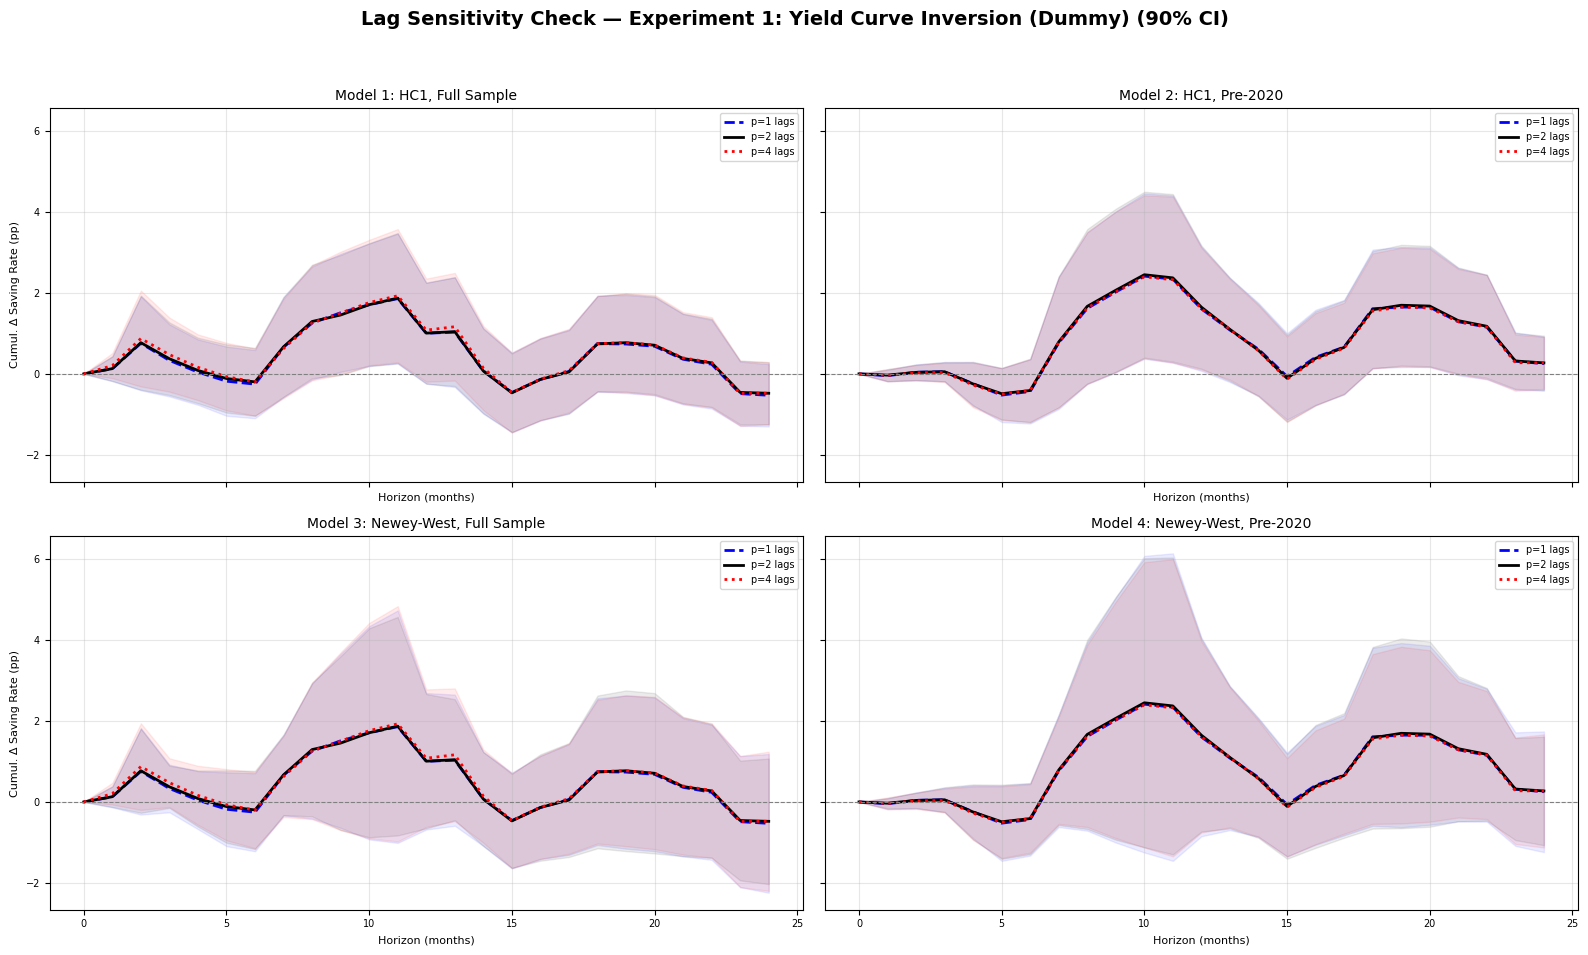

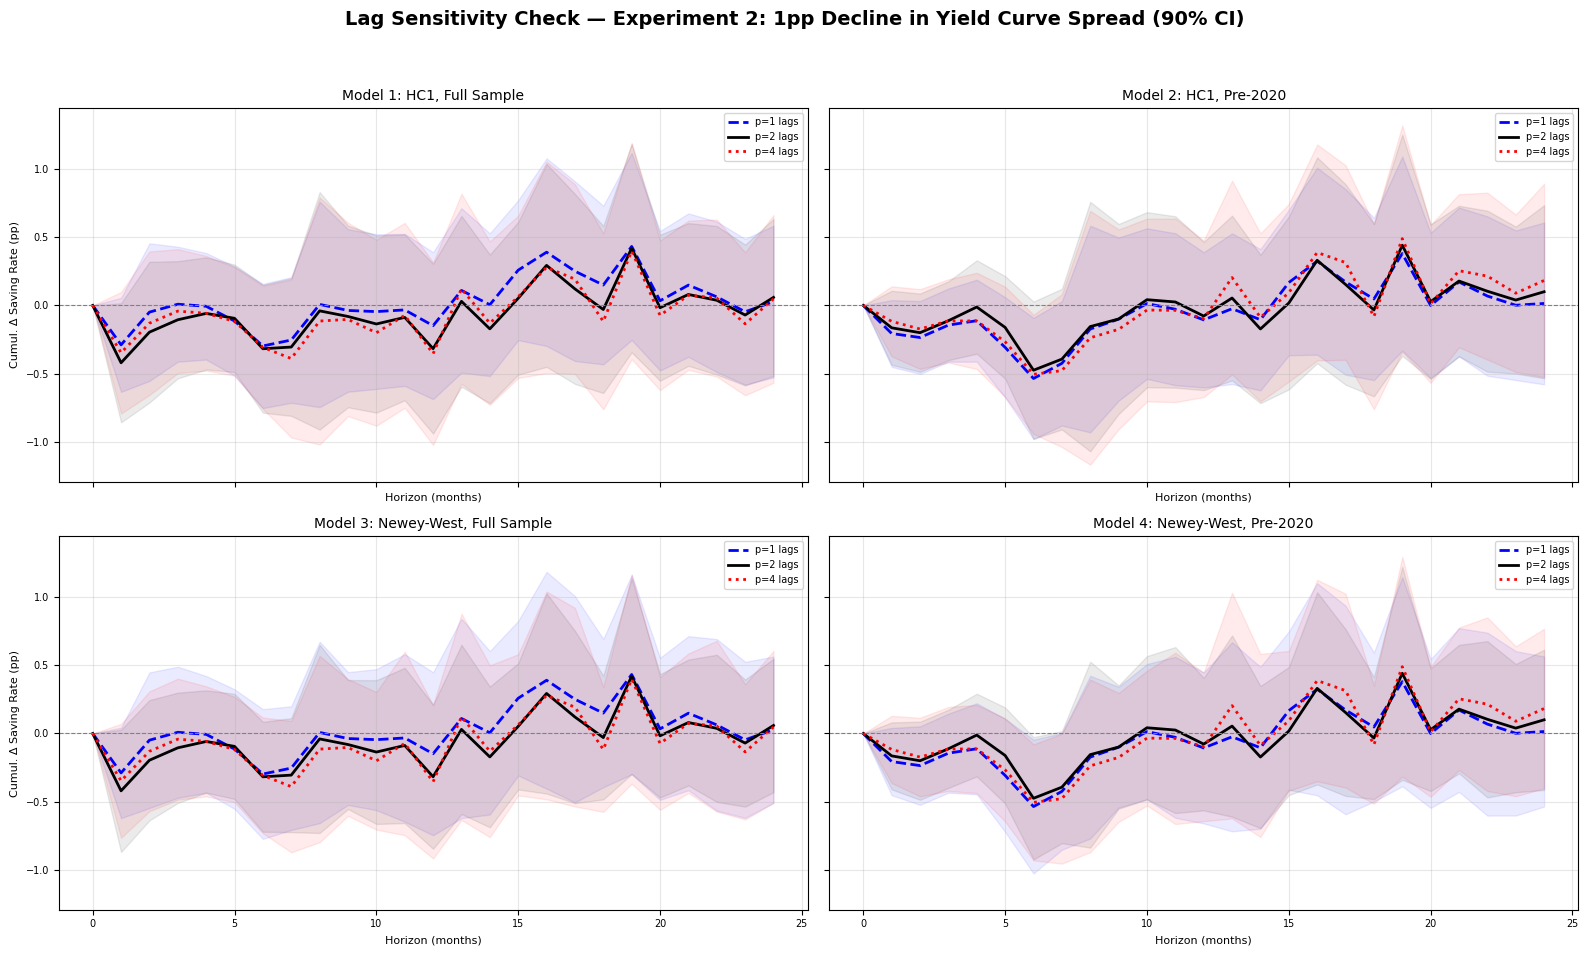

In [ ]:
##############################################################################
# 3.10.1 Lags check
##############################################################################

def create_lp_dataset(df_final, p_lags, H=24):
    """
    Creates the local projection dataset for a given lag order p.
    """
    cols_to_keep = [
        "observation_date", "CPI", "PSAVERT", "T10Y3M",
        "d_DFF", "d_UNRATE", "DPI_Growth"
    ]
    df_lp_temp = df_final[cols_to_keep].copy()

    # --- Experiment 1: Inversion dummy ---
    df_lp_temp["D_inversion"] = (df_lp_temp["T10Y3M"] < 0).astype(int)

    # --- Dummies: COVID and Recession ---
    df_lp_temp["D_covid"] = ((df_lp_temp["observation_date"] >= "2020-03-01") &
                         (df_lp_temp["observation_date"] <= "2021-06-01")).astype(int)

    # Merge recession data (assuming 'recession' is already loaded)
    df_lp_temp = df_lp_temp.merge(recession[['observation_date', 'USREC']], on="observation_date", how="left")
    df_lp_temp.rename(columns={"USREC": "D_recession"}, inplace=True)
    df_lp_temp["D_recession"] = df_lp_temp["D_recession"].fillna(0).astype(int)

    # --- Lag matrix: p lags of ALL variables ---
    vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]
    for lag in range(1, p_lags + 1):
        for var in vars_to_lag:
            df_lp_temp[f"{var}_L{lag}"] = df_lp_temp[var].shift(lag)

    # --- Outcome variables: cumulative change in PSAVERT at each horizon h ---
    df_lp_temp["PSAVERT_Lminus1"] = df_lp_temp["PSAVERT"].shift(1)
    for h in range(0, H + 1):
        df_lp_temp[f"y_h{h}"] = df_lp_temp["PSAVERT"].shift(-h) - df_lp_temp["PSAVERT_Lminus1"]

    return df_lp_temp.dropna().reset_index(drop=True)


# --- Define a wrapper function for run_lp_model with different lag sets ---
def run_lp_models_for_lags(p_lags, H=24):
    print(f"\n--- Running LP models with p={p_lags} lags ---")
    df_lp_current = create_lp_dataset(df_final, p_lags, H=H)

    # Create the pre-2020 dataset for the current lag setup
    df_lp_pre2020_current = df_lp_current.query("observation_date < '2020-01-01'").copy()
    if "D_covid" in df_lp_pre2020_current.columns:
        df_lp_pre2020_current = df_lp_pre2020_current.drop(columns=["D_covid"])

    # --- Helper function for this specific lag setting ---
    def run_lp_model_with_current_lags(data, se_type):
        # Redefine lag_cols for the current p_lags
        current_lag_cols = []
        vars_to_lag = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]
        for l in range(1, p_lags + 1):
            for var in vars_to_lag:
                current_lag_cols.append(f"{var}_L{l}")

        results_exp1_model = []
        results_exp2_model = []
        avail_outlier_controls = [c for c in outlier_controls if c in data.columns]

        for h in range(0, H + 1):
            y = data[f"y_h{h}"]

            if se_type == "HC1":
                fit_kwargs = {"cov_type": "HC1"}
            else:
                fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": min(h + 1, 12)}}

            # Experiment 1: Inversion dummy
            cols1 = ["D_inversion"] + contemp_controls + policy_controls + avail_outlier_controls + current_lag_cols
            cols1 = [c for c in cols1 if c in data.columns]
            X1 = sm.add_constant(data[cols1])
            model1 = sm.OLS(y, X1).fit(**fit_kwargs)
            coef1 = model1.params["D_inversion"]
            pval1 = model1.pvalues["D_inversion"]
            ci1 = model1.conf_int(alpha=0.10).loc["D_inversion"]
            results_exp1_model.append({"h": h, "coef": coef1, "ci_low": ci1[0], "ci_high": ci1[1], "pval": pval1, "model": model1})

            # Experiment 2: 1pp decline in YC Spread
            cols2 = ["T10Y3M"] + contemp_controls + policy_controls + avail_outlier_controls + current_lag_cols
            cols2 = [c for c in cols2 if c in data.columns]
            X2 = sm.add_constant(data[cols2])
            model2 = sm.OLS(y, X2).fit(**fit_kwargs)
            coef2 = model2.params["T10Y3M"]
            pval2 = model2.pvalues["T10Y3M"]
            ci2 = model2.conf_int(alpha=0.10).loc["T10Y3M"]
            shock_size = -1
            results_exp2_model.append({
                "h": h,
                "coef": coef2 * shock_size,
                "ci_low": min(ci2[0] * shock_size, ci2[1] * shock_size),
                "ci_high": max(ci2[0] * shock_size, ci2[1] * shock_size),
                "pval": pval2, "model": model2
            })
        return pd.DataFrame(results_exp1_model), pd.DataFrame(results_exp2_model)

    irf1_m1, irf2_m1 = run_lp_model_with_current_lags(df_lp_current, "HC1")
    irf1_m2, irf2_m2 = run_lp_model_with_current_lags(df_lp_pre2020_current, "HC1")
    irf1_m3, irf2_m3 = run_lp_model_with_current_lags(df_lp_current, "HAC")
    irf1_m4, irf2_m4 = run_lp_model_with_current_lags(df_lp_pre2020_current, "HAC")
    return irf1_m1, irf2_m1, irf1_m2, irf2_m2, irf1_m3, irf2_m3, irf1_m4, irf2_m4


# --- Run for different lag orders ---
# Using p_bic = 2 from previous analysis as the baseline
p_lags_to_test = [1, 4] # Test p=1 and p=4

all_irfs_exp1_lags = {}
all_irfs_exp2_lags = {}

# Include the baseline p_bic = 2 results for comparison
all_irfs_exp1_lags[p_bic] = [irf1_m1, irf1_m2, irf1_m3, irf1_m4]
all_irfs_exp2_lags[p_bic] = [irf2_m1, irf2_m2, irf2_m3, irf2_m4]

for p_val in p_lags_to_test:
    irf1_m1_p, irf2_m1_p, irf1_m2_p, irf2_m2_p, irf1_m3_p, irf2_m3_p, irf1_m4_p, irf2_m4_p = run_lp_models_for_lags(p_val)
    all_irfs_exp1_lags[p_val] = [irf1_m1_p, irf1_m2_p, irf1_m3_p, irf1_m4_p]
    all_irfs_exp2_lags[p_val] = [irf2_m1_p, irf2_m2_p, irf2_m3_p, irf2_m4_p]

print("All lag sensitivity models estimated successfully.")


# --- Plotting function for lag sensitivity ---
def plot_lag_sensitivity(all_irfs, experiment_label):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True, sharex=True)
    axes_flat = axes.flatten()

    model_index_map = {"HC1, Full Sample": 0, "HC1, Pre-2020": 1, "Newey-West, Full Sample": 2, "Newey-West, Pre-2020": 3}
    model_titles = list(model_index_map.keys())
    plot_colors = ["steelblue", "crimson", "forestgreen", "darkorange"]
    lag_colors = {p_bic: "black", 1: "blue", 4: "red"}
    lag_linestyles = {p_bic: "-", 1: "--", 4: ":"}

    for i, title in enumerate(model_titles):
        ax = axes_flat[i]
        for p_val in sorted(all_irfs.keys()):
            irf = all_irfs[p_val][i]
            ax.plot(irf["h"], irf["coef"], color=lag_colors[p_val], linestyle=lag_linestyles[p_val], linewidth=2, label=f"p={p_val} lags")
            ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                            alpha=0.08, color=lag_colors[p_val]) # Lighter fill for clarity
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
        ax.set_title(f"Model {i+1}: {title}", fontsize=10)
        ax.set_xlabel("Horizon (months)", fontsize=8)
        if i % 2 == 0: # Left column
            ax.set_ylabel("Cumul. \u0394 Saving Rate (pp)", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, loc="upper right")

    plt.suptitle(f"Lag Sensitivity Check — {experiment_label} (90% CI)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- Plot results ---
plot_lag_sensitivity(all_irfs_exp1_lags, "Experiment 1: Yield Curve Inversion (Dummy)")
plot_lag_sensitivity(all_irfs_exp2_lags, "Experiment 2: 1pp Decline in Yield Curve Spread")


#### 3.10.2 Placebo

Reshuffles D_inversion 500 times and plots the 5th–95th percentile band of the placebo distribution. If your true IRF sits above the grey band in the h=8–12 range, the result is not spurious.

  Placebo run 100/500...
  Placebo run 200/500...
  Placebo run 300/500...
  Placebo run 400/500...
  Placebo run 500/500...
Placebo runs complete.


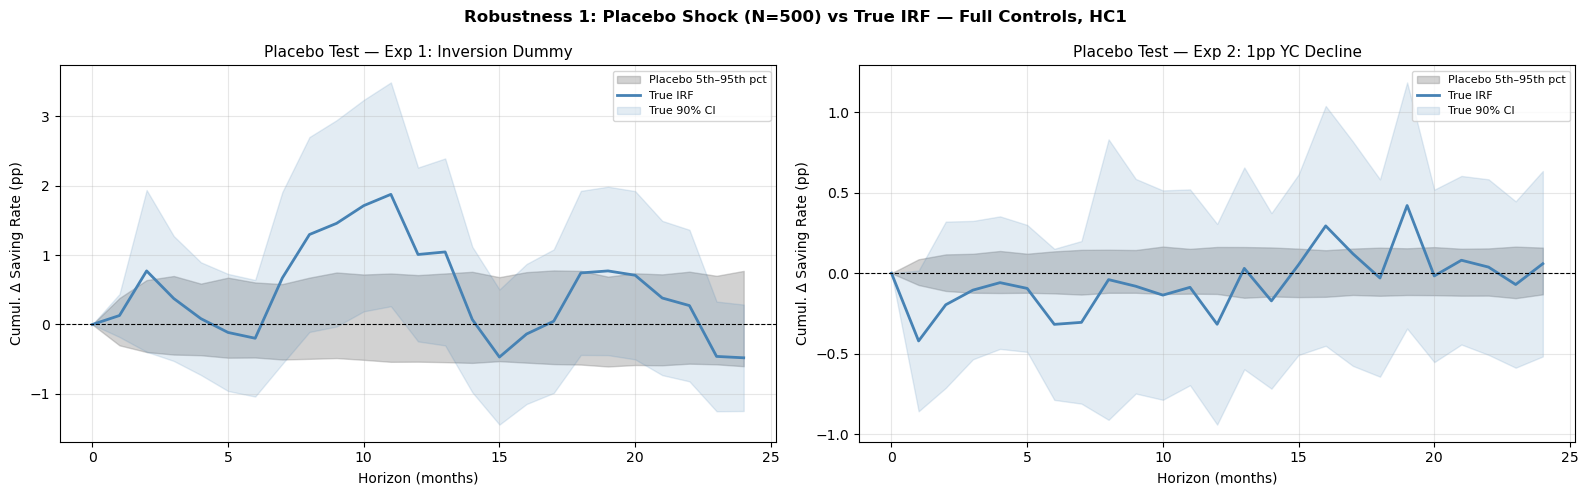

In [ ]:
##############################################################################
# ROBUSTNESS 1 — Placebo Shock
#
# Replace D_inversion with a randomly shuffled version.
# If the shuffled IRF looks similar to the real one, the result is spurious.
# We run 500 placebo IRFs and overlay the percentile band vs the true IRF.
#
# Uses full-control spec, Model 1 (HC1, Full Sample) as baseline.
##############################################################################

import statsmodels.api as sm
import numpy as np

N_PLACEBO = 500
np.random.seed(42)

avail_outlier = [c for c in outlier_controls if c in df_lp.columns]

placebo_coefs_exp1 = np.zeros((N_PLACEBO, H + 1))
placebo_coefs_exp2 = np.zeros((N_PLACEBO, H + 1))

for b in range(N_PLACEBO):
    df_placebo = df_lp.copy()
    df_placebo["D_inversion_pl"] = np.random.permutation(df_lp["D_inversion"].values)
    df_placebo["T10Y3M_pl"]      = np.random.permutation(df_lp["T10Y3M"].values)

    for h in range(0, H + 1):
        y = df_placebo[f"y_h{h}"]

        # Exp 1: shuffled inversion dummy
        cols1 = [c for c in ["D_inversion_pl"] + contemp_controls + policy_controls
                 + avail_outlier + lag_cols if c in df_placebo.columns]
        m1 = sm.OLS(y, sm.add_constant(df_placebo[cols1])).fit(cov_type="HC1")
        placebo_coefs_exp1[b, h] = m1.params["D_inversion_pl"]

        # Exp 2: shuffled T10Y3M
        cols2 = [c for c in ["T10Y3M_pl"] + contemp_controls + policy_controls
                 + avail_outlier + lag_cols if c in df_placebo.columns]
        m2 = sm.OLS(y, sm.add_constant(df_placebo[cols2])).fit(cov_type="HC1")
        placebo_coefs_exp2[b, h] = m2.params["T10Y3M_pl"] * -1

    if (b + 1) % 100 == 0:
        print(f"  Placebo run {b+1}/{N_PLACEBO}...")

print("Placebo runs complete.")

# --- Percentile bands ---
horizons = np.arange(H + 1)
p5_exp1  = np.percentile(placebo_coefs_exp1,  5, axis=0)
p95_exp1 = np.percentile(placebo_coefs_exp1, 95, axis=0)
p5_exp2  = np.percentile(placebo_coefs_exp2,  5, axis=0)
p95_exp2 = np.percentile(placebo_coefs_exp2, 95, axis=0)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, irf, p5, p95, title in zip(
    axes,
    [irf1_m1, irf2_m1],
    [p5_exp1,  p5_exp2],
    [p95_exp1, p95_exp2],
    ["Exp 1: Inversion Dummy", "Exp 2: 1pp YC Decline"]
):
    ax.fill_between(horizons, p5, p95,
                    color="grey", alpha=0.35, label="Placebo 5th–95th pct")
    ax.plot(irf["h"], irf["coef"],
            color="steelblue", linewidth=2, label="True IRF")
    ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                    alpha=0.15, color="steelblue", label="True 90% CI")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Placebo Test — {title}", fontsize=11)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumul. Δ Saving Rate (pp)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Robustness 1: Placebo Shock (N=500) vs True IRF — Full Controls, HC1",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3.10.3 Inflation as the outcome

Runs the exact same LP but with cumulative Δ Inflation as the LHS. You want to see a flat, insignificant IRF here — that would tell the reader the yield curve predicts saving behavior, not just general macro conditions, which directly supports the precautionary saving channel.

Inflation outcome dataset: 475 obs (full), 453 (pre-2020)
Running inflation LP (HC1, Full)...
Running inflation LP (HC1, Pre-2020)...
Done.


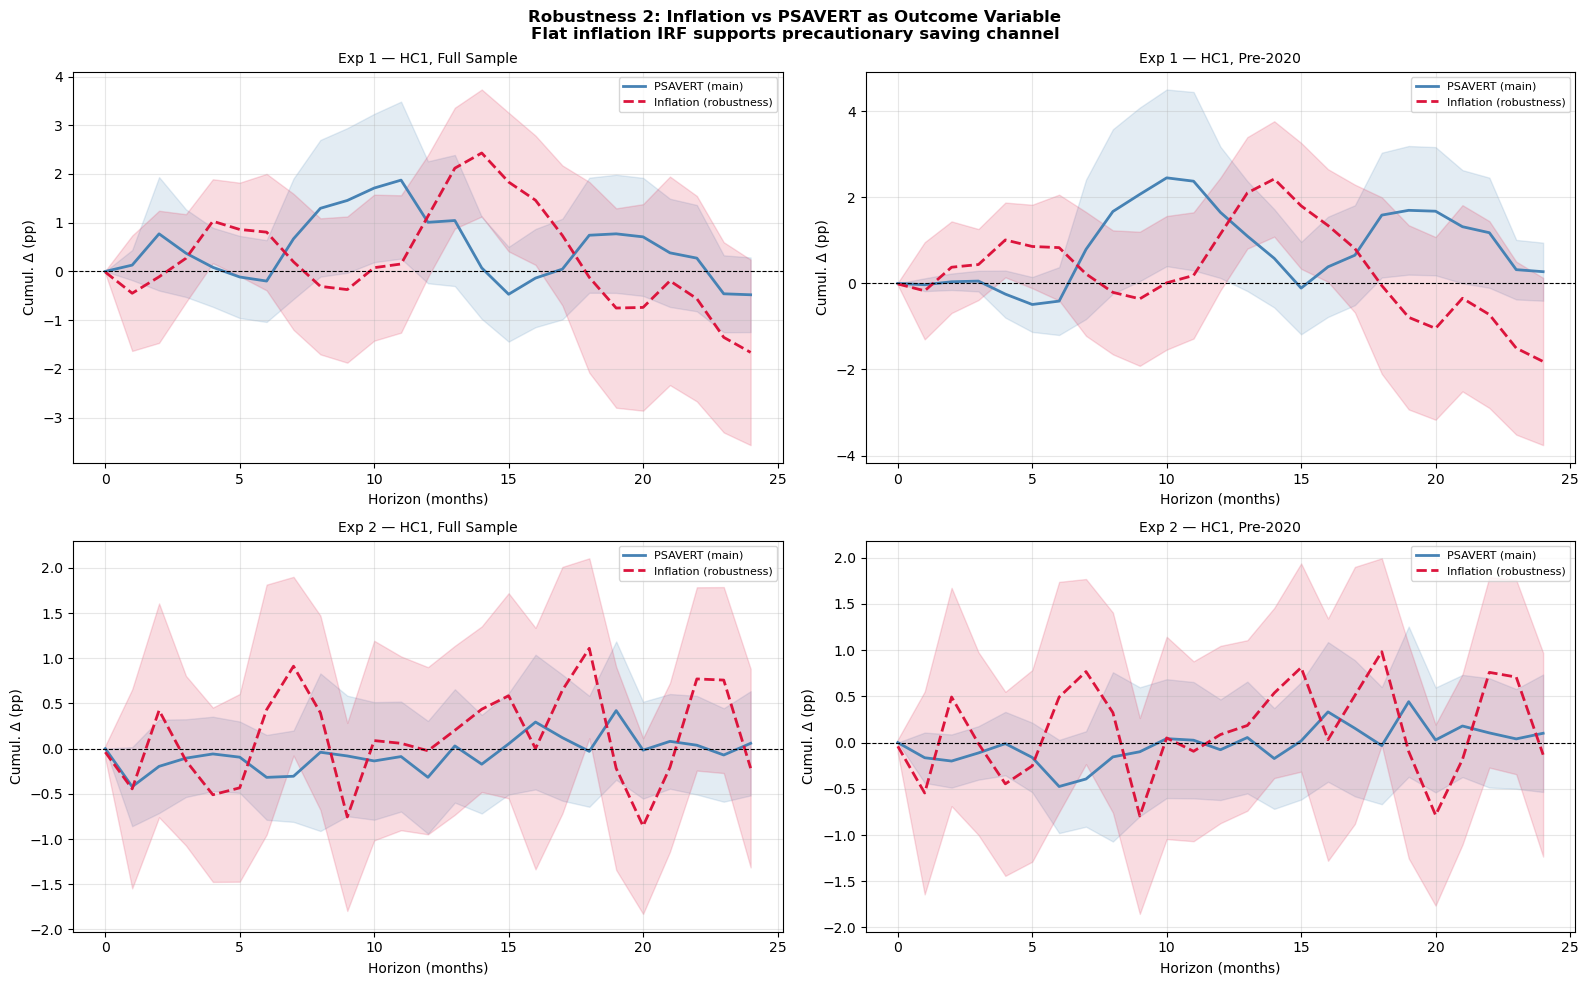

In [ ]:
##############################################################################
# ROBUSTNESS 2 — Inflation as Outcome Variable
#
# Re-runs the LP with CPI Inflation as the dependent variable instead of
# Personal Saving Rate.
#
# Interpretation: if the yield curve predicts saving but NOT inflation,
# this supports the precautionary saving channel over the monetary/price channel.
# We expect a flat/noisy IRF here — that would strengthen the main result.
#
# Outcome: Inflation_{t+h} - Inflation_{t-1}  (cumulative change)
# Uses full-control spec, Models 1 & 2 (HC1 Full + HC1 Pre-2020)
##############################################################################

import statsmodels.api as sm

avail_outlier = [c for c in outlier_controls if c in df_lp.columns]

# --- Build inflation outcome variables ---
# We need Inflation_{t+h} - Inflation_{t-1} analogous to the PSAVERT outcome
df_lp_inf = df_lp.copy()
df_lp_inf["CPI_Lminus1"] = df_lp_inf["CPI"].shift(1).fillna(method="bfill")

# Recalculate outcomes using Inflation instead of PSAVERT
# (df_lp already has lags computed; we just swap the LHS)
for h in range(0, H + 1):
    df_lp_inf[f"y_inf_h{h}"] = (df_lp_inf["CPI"].shift(-h)
                                 - df_lp_inf["CPI_Lminus1"])

df_lp_inf = df_lp_inf.dropna().reset_index(drop=True)
df_lp_inf_pre2020 = df_lp_inf[df_lp_inf["observation_date"] < "2020-01-01"].copy().reset_index(drop=True)

print(f"Inflation outcome dataset: {len(df_lp_inf)} obs (full), {len(df_lp_inf_pre2020)} (pre-2020)")

# --- Run LP with inflation outcome ---
def run_lp_inf(data, se_type, H=H):
    res1, res2 = [], []
    avail_ol = [c for c in outlier_controls if c in data.columns]

    for h in range(0, H + 1):
        y = data[f"y_inf_h{h}"]

        fit_kwargs = ({"cov_type": "HC1"} if se_type == "HC1"
                      else {"cov_type": "HAC", "cov_kwds": {"maxlags": h + 1}})

        cols1 = [c for c in ["D_inversion"] + contemp_controls + policy_controls
                 + avail_ol + lag_cols if c in data.columns]
        m1  = sm.OLS(y, sm.add_constant(data[cols1])).fit(**fit_kwargs)
        ci1 = m1.conf_int(alpha=0.10).loc["D_inversion"]
        res1.append({"h": h, "coef": m1.params["D_inversion"],
                     "ci_low": ci1[0], "ci_high": ci1[1]})

        cols2 = [c for c in ["T10Y3M"] + contemp_controls + policy_controls
                 + avail_ol + lag_cols if c in data.columns]
        m2    = sm.OLS(y, sm.add_constant(data[cols2])).fit(**fit_kwargs)
        coef2 = m2.params["T10Y3M"]
        ci2   = m2.conf_int(alpha=0.10).loc["T10Y3M"]
        shock = -1
        res2.append({"h": h, "coef": coef2 * shock,
                     "ci_low":  min(ci2[0] * shock, ci2[1] * shock),
                     "ci_high": max(ci2[0] * shock, ci2[1] * shock)})

    return pd.DataFrame(res1), pd.DataFrame(res2)


print("Running inflation LP (HC1, Full)...")
irf1_inf_m1, irf2_inf_m1 = run_lp_inf(df_lp_inf,         "HC1")
print("Running inflation LP (HC1, Pre-2020)...")
irf1_inf_m2, irf2_inf_m2 = run_lp_inf(df_lp_inf_pre2020, "HC1")
print("Done.")

# --- Plot: Inflation IRF vs PSAVERT IRF side by side ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pairs = [
    (irf1_m1,     irf1_inf_m1, "Exp 1 — HC1, Full Sample"),
    (irf1_m2,     irf1_inf_m2, "Exp 1 — HC1, Pre-2020"),
    (irf2_m1,     irf2_inf_m1, "Exp 2 — HC1, Full Sample"),
    (irf2_m2,     irf2_inf_m2, "Exp 2 — HC1, Pre-2020"),
]

for ax, (irf_psr, irf_inf, title) in zip(axes.flat, pairs):
    ax.plot(irf_psr["h"], irf_psr["coef"],
            color="steelblue", linewidth=2, label="PSAVERT (main)")
    ax.fill_between(irf_psr["h"], irf_psr["ci_low"], irf_psr["ci_high"],
                    alpha=0.15, color="steelblue")
    ax.plot(irf_inf["h"], irf_inf["coef"],
            color="crimson", linewidth=2, linestyle="--", label="Inflation (robustness)")
    ax.fill_between(irf_inf["h"], irf_inf["ci_low"], irf_inf["ci_high"],
                    alpha=0.15, color="crimson")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumul. Δ (pp)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Robustness 2: Inflation vs PSAVERT as Outcome Variable\n"
             "Flat inflation IRF supports precautionary saving channel",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3.10.4 Rolling Window / Structural Breaks

Two-part analysis:
- **Part A:** Tracks β^10 (the h=10 IRF coefficient) across all 15-year rolling estimation windows, with a vertical line at the start of the COVID period (March 2020). Shows whether the yield curve–saving relationship has been stable over time.
- **Part B:** Splits the sample into **pre-2020** and **full sample** and plots both IRFs side-by-side. If the pre-2020 IRF differs materially from the full-sample IRF, the pandemic period is distorting the estimates.

**Interpretation:** A stable rolling β^10 and similar pre/post-split IRFs support the robustness of the main result.

Estimating Local Projections for each regime…
Done.


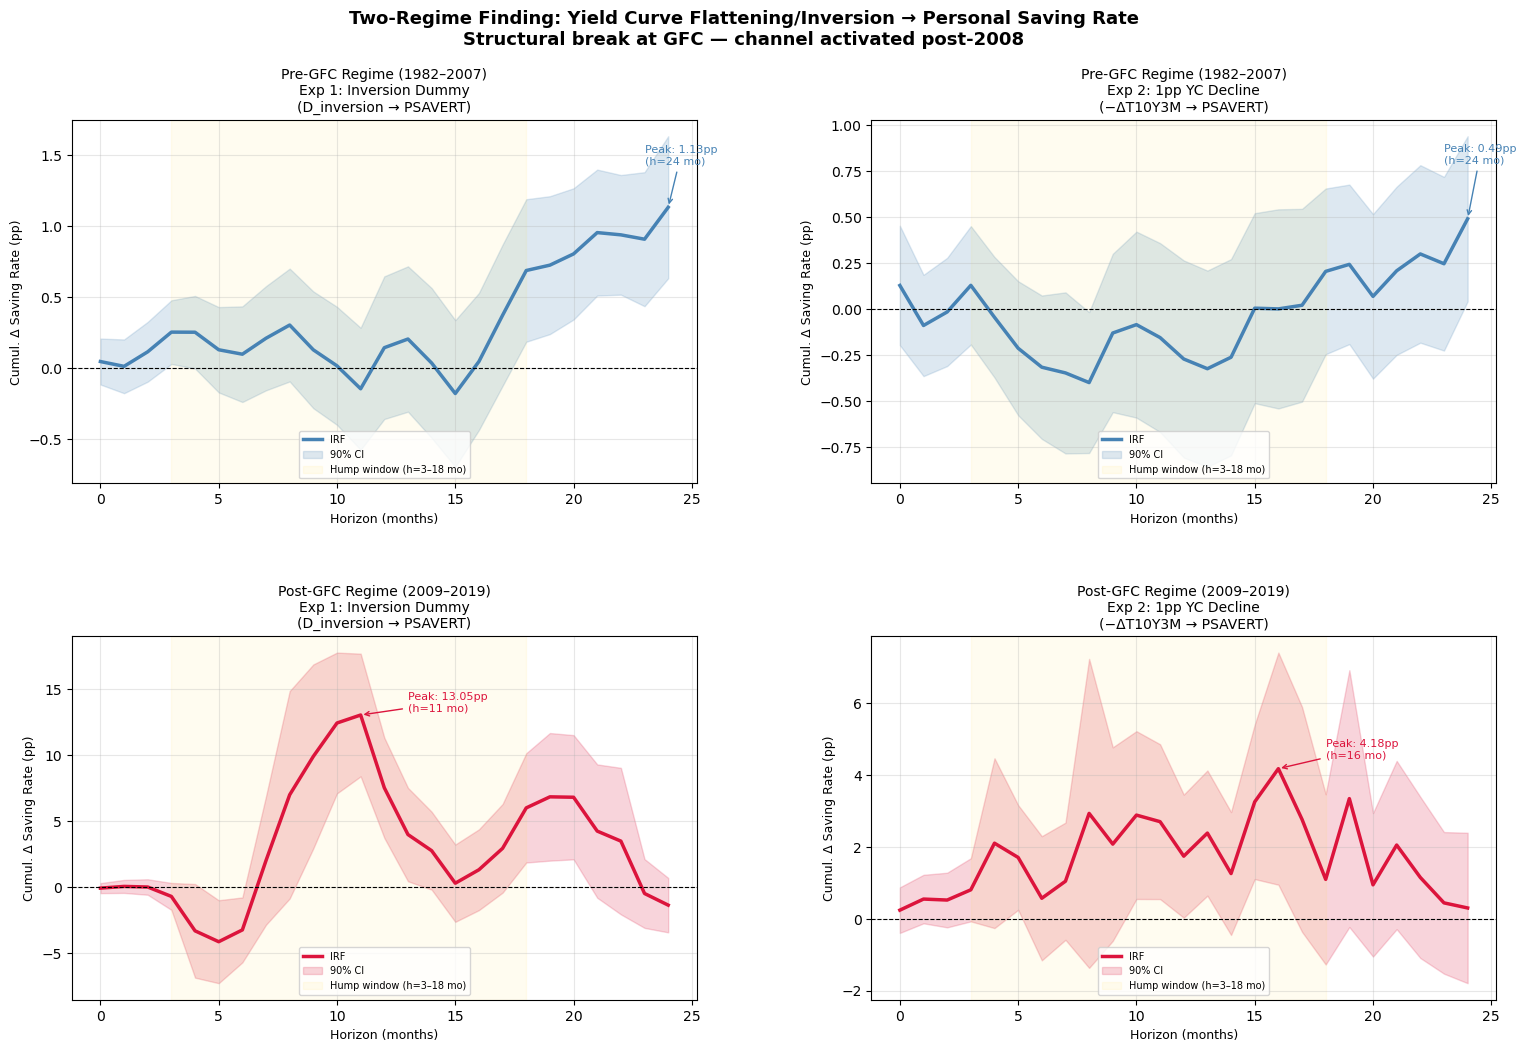


  JOINT CHI2 TESTS — Exp 1: Inversion Dummy

  Pre-GFC  (1982–2007)
  ────────────────────────────────────────────────────────────
  Joint Chi2 = 17.760  |  df = 16  |  p = 0.3382 
  Most significant horizons:
 h     coef       se    p-val
18 0.687780 0.303692 0.023530
 3 0.254474 0.135632 0.060626
 4 0.253793 0.154608 0.100689

  Post-GFC (2009–2019)
  ────────────────────────────────────────────────────────────
  Joint Chi2 = 83.134  |  df = 16  |  p = 0.0000 ***
  Most significant horizons:
 h      coef       se    p-val
11 13.053800 2.806402 0.000003
10 12.447072 3.220088 0.000111
12  7.536529 2.293170 0.001014

  JOINT CHI2 TESTS — Exp 2: 1pp YC Decline

  Pre-GFC  (1982–2007)
  ────────────────────────────────────────────────────────────
  Joint Chi2 = 11.257  |  df = 16  |  p = 0.7933 
  Most significant horizons:
 h      coef       se    p-val
 8 -0.397278 0.232017 0.086846
 6 -0.313720 0.236100 0.183927
 7 -0.344728 0.265217 0.193671

  Post-GFC (2009–2019)
  ────────────────

In [ ]:
##############################################################################
# ROBUSTNESS 3D — Two-Regime Visualization & Joint Chi2 Tests
# Corrected to match df_lp structure from Section 3.2
##############################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings("ignore")

# ── 0. Column name constants (match your df_lp exactly) ─────────────────────

SAVING_VAR  = "PSAVERT"       # personal saving rate
SPREAD_VAR  = "T10Y3M"        # yield curve spread
INV_DUMMY   = "D_inversion"   # already in df_lp
LAG_VARS    = ["CPI", "PSAVERT", "T10Y3M", "d_DFF", "d_UNRATE", "DPI_Growth"]
DATE_COL    = "observation_date"
ALPHA       = 0.10            # 90% confidence intervals

# ── 1. Helper: estimate LP for a sub-period ──────────────────────────────────

def estimate_regime_lp(df, start_date, end_date, x_var, p_lags, max_h=24):
    """
    Runs pooled LP regressions on a date-filtered sub-sample.

    Parameters
    ----------
    df         : df_lp (your main LP dataset)
    start_date : str, e.g. "1982-01-01"
    end_date   : str, e.g. "2007-12-01"
    x_var      : str — regressor of interest ("T10Y3M", "D_inversion", or "Neg_Spread")
    p_lags     : int — number of lags (p_bic from your BIC selection)
    max_h      : int — maximum horizon (months); capped by sub-sample length

    Returns
    -------
    DataFrame with columns: h, coef, se, ci_low, ci_high
    """
    mask   = (df[DATE_COL] >= start_date) & (df[DATE_COL] <= end_date)
    df_sub = df[mask].copy()

    # Cap horizon so we always have at least 30 observations
    usable_h = min(max_h, len(df_sub) - p_lags - 5)
    if usable_h < 1:
        return pd.DataFrame(columns=["h", "coef", "se", "ci_low", "ci_high"])

    # Lag column names — must match what Section 3.2 created
    lag_cols = [f"{var}_L{lag}" for lag in range(1, p_lags + 1) for var in LAG_VARS]
    # Keep only those that actually exist in df_sub
    lag_cols = [c for c in lag_cols if c in df_sub.columns]

    results = []
    for h in range(0, usable_h + 1):
        outcome_col = f"y_h{h}"
        if outcome_col not in df_sub.columns:
            continue

        cols_needed = [outcome_col, x_var] + lag_cols
        sub = df_sub[cols_needed].dropna()

        if len(sub) < 30:   # minimum obs guard
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})
            continue

        X    = pd.concat(
                   [pd.Series(1.0, index=sub.index, name="const"),
                    sub[[x_var] + lag_cols]],
                   axis=1
               ).astype(float)
        y    = sub[outcome_col].astype(float)
        Xmat = X.values
        yvec = y.values

        try:
            XtX_inv = np.linalg.pinv(Xmat.T @ Xmat)
            beta    = XtX_inv @ (Xmat.T @ yvec)
            resid   = yvec - Xmat @ beta
            n, k    = Xmat.shape

            # HC1 heteroskedasticity-robust covariance
            meat    = (Xmat * resid[:, None]).T @ (Xmat * resid[:, None])
            V_cov   = (n / (n - k)) * XtX_inv @ meat @ XtX_inv
            se_vec  = np.sqrt(np.diag(V_cov))

            coef_val = beta[1]      # coefficient on x_var (position 1, after const)
            se_val   = se_vec[1]
            t_crit   = scipy_stats.t.ppf(1 - ALPHA / 2, df=n - k)

            results.append({
                "h":      h,
                "coef":   coef_val,
                "se":     se_val,
                "ci_low":  coef_val - t_crit * se_val,
                "ci_high": coef_val + t_crit * se_val,
            })
        except np.linalg.LinAlgError:
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})

    return pd.DataFrame(results)


# ── 2. Add Neg_Spread column for Experiment 2 ────────────────────────────────

# A 1pp *decline* in the spread is coded as a positive unit shock on Neg_Spread,
# so the IRF reads as the saving rate response to a yield-curve flattening shock.
df_lp["Neg_Spread"] = -1.0 * df_lp[SPREAD_VAR]


# ── 3. Estimate regime IRFs ──────────────────────────────────────────────────

print("Estimating Local Projections for each regime…")

# Experiment 1 — Inversion dummy (D_inversion already in df_lp)
irf1_A = estimate_regime_lp(df_lp, "1982-01-01", "2007-12-01", "D_inversion", p_bic)
irf1_C = estimate_regime_lp(df_lp, "2009-01-01", "2019-12-01", "D_inversion", p_bic)
irf1_B = estimate_regime_lp(df_lp, "1982-01-01", "2019-12-01", "D_inversion", p_bic)

# Experiment 2 — 1pp decline in yield curve spread
irf2_A = estimate_regime_lp(df_lp, "1982-01-01", "2007-12-01", "Neg_Spread",  p_bic)
irf2_C = estimate_regime_lp(df_lp, "2009-01-01", "2019-12-01", "Neg_Spread",  p_bic)
irf2_B = estimate_regime_lp(df_lp, "1982-01-01", "2019-12-01", "Neg_Spread",  p_bic)

print("Done.")


# ── 4. Two-Regime IRF Plot ───────────────────────────────────────────────────

HUMP_LO, HUMP_HI = 3, 18   # hump window in months (roughly 3–18 months post-shock)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

regime_specs = [
    (irf1_A, irf1_C, "Exp 1: Inversion Dummy\n(D_inversion → PSAVERT)"),
    (irf2_A, irf2_C, "Exp 2: 1pp YC Decline\n(−ΔT10Y3M → PSAVERT)"),
]

plot_rows = [
    ("steelblue", "Pre-GFC Regime (1982–2007)"),
    ("crimson",   "Post-GFC Regime (2009–2019)"),
]

for col, (irf_pre, irf_post, exp_title) in enumerate(regime_specs):
    for row, (irf_df, (color, regime_label)) in enumerate(
            zip([irf_pre, irf_post], plot_rows)):

        ax = axes[row, col]

        if irf_df.empty or irf_df["coef"].isna().all():
            ax.text(0.5, 0.5,
                    "Insufficient variation\nto estimate regime",
                    ha="center", va="center",
                    transform=ax.transAxes, color="gray", fontsize=10)
            ax.set_title(f"{regime_label}\n{exp_title}", fontsize=10)
            continue

        ax.plot(irf_df["h"], irf_df["coef"],
                color=color, linewidth=2.5, label="IRF")
        ax.fill_between(irf_df["h"], irf_df["ci_low"], irf_df["ci_high"],
                        alpha=0.18, color=color, label="90% CI")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.axvspan(HUMP_LO, HUMP_HI, alpha=0.06, color="gold",
                   label=f"Hump window (h={HUMP_LO}–{HUMP_HI} mo)")

        # Annotate peak — guard against all-NaN
        valid = irf_df.dropna(subset=["coef"])
        if not valid.empty:
            peak_idx = valid["coef"].idxmax()
            peak_h   = valid.loc[peak_idx, "h"]
            peak_val = valid.loc[peak_idx, "coef"]
            ax.annotate(
                f"Peak: {peak_val:.2f}pp\n(h={peak_h} mo)",
                xy=(peak_h, peak_val),
                xytext=(min(peak_h + 2, irf_df["h"].max() - 1), peak_val + 0.3),
                arrowprops=dict(arrowstyle="->", color=color),
                fontsize=8, color=color,
            )

        ax.set_title(f"{regime_label}\n{exp_title}", fontsize=10)
        ax.set_xlabel("Horizon (months)", fontsize=9)
        ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle(
    "Two-Regime Finding: Yield Curve Flattening/Inversion → Personal Saving Rate\n"
    "Structural break at GFC — channel activated post-2008",
    fontsize=13, fontweight="bold",
)
plt.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.97,
                    hspace=0.42, wspace=0.28)
plt.savefig("robustness_3D_two_regime.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 5. Joint Chi2 Tests ──────────────────────────────────────────────────────

def joint_chi2_regime(irf, label, h_lo=3, h_hi=18):
    """
    Joint significance test over the hump window [h_lo, h_hi].
    Uses stored SEs (consistent t-distribution CIs, not approximated).
    """
    subset = irf[irf["h"].between(h_lo, h_hi) & irf["coef"].notna()].copy()

    if subset.empty:
        print(f"\n  {label}\n  {'─'*60}\n  Insufficient data for Chi2 test.")
        return None

    # Use stored SE directly — no CI back-calculation needed
    subset["z_stat"] = subset["coef"] / subset["se"]
    subset["pval_z"] = 2 * (1 - scipy_stats.norm.cdf(abs(subset["z_stat"])))

    chi2    = (subset["z_stat"] ** 2).sum()
    df_chi  = len(subset)
    p_joint = scipy_stats.chi2.sf(chi2, df=df_chi)
    stars   = ("***" if p_joint < 0.01 else "**" if p_joint < 0.05
               else "*" if p_joint < 0.10 else "")

    print(f"\n  {label}")
    print(f"  {'─'*60}")
    print(f"  Joint Chi2 = {chi2:.3f}  |  df = {df_chi}  |  p = {p_joint:.4f} {stars}")

    top_n = min(3, len(subset))
    top   = (subset.nsmallest(top_n, "pval_z")
                   [["h", "coef", "se", "pval_z"]]
                   .rename(columns={"pval_z": "p-val"}))
    print(f"  Most significant horizons:\n{top.to_string(index=False)}")

    return {"label": label, "chi2": round(chi2, 3),
            "df": df_chi, "p": round(p_joint, 4), "stars": stars}


print("\n" + "=" * 65)
print("  JOINT CHI2 TESTS — Exp 1: Inversion Dummy")
print("=" * 65)
joint_chi2_regime(irf1_A, "Pre-GFC  (1982–2007)")
joint_chi2_regime(irf1_C, "Post-GFC (2009–2019)")

print("\n" + "=" * 65)
print("  JOINT CHI2 TESTS — Exp 2: 1pp YC Decline")
print("=" * 65)
joint_chi2_regime(irf2_A, "Pre-GFC  (1982–2007)")
joint_chi2_regime(irf2_C, "Post-GFC (2009–2019)")


# ── 6. Coefficient Table at Key Horizons ─────────────────────────────────────

print(f"\n\n{'='*72}")
print("  COEFFICIENT TABLE AT KEY HORIZONS — Exp 2: 1pp YC Decline")
print(f"  [[coef]] = significant at 10% (90% CI excludes zero)")
print(f"{'='*72}")

key_horizons = [3, 6, 9, 12, 18, 24]

rows = []
for h in key_horizons:
    row = {"h (mo)": h}
    for irf_df, col_label in [(irf2_A, "Pre-GFC"),
                               (irf2_C, "Post-GFC"),
                               (irf2_B, "Full sample")]:
        sub = irf_df[irf_df["h"] == h]
        if sub.empty or pd.isna(sub.iloc[0]["coef"]):
            row[f"{col_label} β"]  = "—"
            row[f"{col_label} CI"] = "—"
            continue
        r   = sub.iloc[0]
        sig = (r["ci_low"] > 0) or (r["ci_high"] < 0)
        row[f"{col_label} β"]  = f"[[{r['coef']:.3f}]]" if sig else f"{r['coef']:.3f}"
        row[f"{col_label} CI"] = f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]"
    rows.append(row)

print(pd.DataFrame(rows).set_index("h (mo)").to_string())

#### 3.10.5 Alternative Shock Definitions

Three alternative operationalisations of the yield curve shock are tested:

- **Alt A — Δspread** (): month-on-month change in the 10Y–3M spread (captures the *direction of movement* rather than the level)
- **Alt B — Severity-weighted dummy**: inversion dummy × |T10Y3M| (weights inversions by how deep they are)
- **Alt C — Cumulative inversion depth**: running sum of negative spread months (captures how long and deep the inversion has been)

**Interpretation:** If Alt B or Alt C produce stronger/cleaner IRFs than the binary dummy, that tells us households respond to the *intensity* of the inversion signal, not just its occurrence.

In [ ]:
##############################################################################
# ROBUSTNESS 4 — Alternative Shock Definitions
#
# Tests whether results are driven by the specific shock definition.
# Three alternatives to the main inversion dummy:
#
#   Alt A: First difference of T10Y3M  (change in spread, not level)
#          Captures: "spread narrowed by X pp this month"
#
#   Alt B: Severity-weighted dummy
#          D_inversion × |T10Y3M|  — deeper inversions get higher weight
#          Captures: not just whether inverted, but how inverted
#
#   Alt C: Cumulative inversion depth
#          Rolling 6-month sum of negative T10Y3M values
#          Captures: sustained inversions matter more than brief ones
#
# All compared against the main result (Model 1: HC1, Full Sample)
##############################################################################

import statsmodels.api as sm

avail_outlier = [c for c in outlier_controls if c in df_lp.columns]

# --- Build alternative shock variables ---
df_lp_alt = df_lp.copy()

# Alt A: first difference of T10Y3M
df_lp_alt["d_T10Y3M"] = df_lp_alt["T10Y3M"].diff()

# Alt B: severity-weighted dummy (depth of inversion × dummy)
df_lp_alt["D_inv_severity"] = df_lp_alt["D_inversion"] * df_lp_alt["T10Y3M"].abs()

# Alt C: 6-month cumulative inversion depth
df_lp_alt["T10Y3M_neg"]  = df_lp_alt["T10Y3M"].clip(upper=0)
df_lp_alt["D_inv_cumul"] = df_lp_alt["T10Y3M_neg"].rolling(6).sum().abs()

df_lp_alt = df_lp_alt.dropna().reset_index(drop=True)
print(f"Alternative shock dataset: {len(df_lp_alt)} observations")


def run_lp_altshock(data, shock_var, se_type="HC1", H=H, shock_scale=1):
    res = []
    avail_ol = [c for c in outlier_controls if c in data.columns]
    for h in range(0, H + 1):
        y    = data[f"y_h{h}"]
        cols = [c for c in [shock_var] + contemp_controls + policy_controls
                + avail_ol + lag_cols if c in data.columns]
        fit_kwargs = ({"cov_type": "HC1"} if se_type == "HC1"
                      else {"cov_type": "HAC", "cov_kwds": {"maxlags": h + 1}})
        try:
            m  = sm.OLS(y, sm.add_constant(data[cols])).fit(**fit_kwargs)
            ci = m.conf_int(alpha=0.10).loc[shock_var]
            res.append({"h": h,
                        "coef":    m.params[shock_var] * shock_scale,
                        "ci_low":  min(ci[0] * shock_scale, ci[1] * shock_scale),
                        "ci_high": max(ci[0] * shock_scale, ci[1] * shock_scale)})
        except Exception:
            res.append({"h": h, "coef": np.nan, "ci_low": np.nan, "ci_high": np.nan})
    return pd.DataFrame(res)


print("Running Alt A (first difference of spread)...")
irf_altA = run_lp_altshock(df_lp_alt, "d_T10Y3M",      shock_scale=-1)

print("Running Alt B (severity-weighted inversion)...")
irf_altB = run_lp_altshock(df_lp_alt, "D_inv_severity", shock_scale=1)

print("Running Alt C (cumulative inversion depth)...")
irf_altC = run_lp_altshock(df_lp_alt, "D_inv_cumul",    shock_scale=1)

print("Done.")

# --- Plot: main IRF vs three alternatives ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

alt_specs = [
    (irf_altA, "Alt A: Delta Spread (1pp decline)", "darkorange"),
    (irf_altB, "Alt B: Severity-Weighted Inversion", "forestgreen"),
    (irf_altC, "Alt C: Cumulative Inversion Depth",  "purple"),
]

for ax, (irf_alt, alt_label, alt_color) in zip(axes, alt_specs):
    ax.plot(irf1_m1["h"], irf1_m1["coef"],
            color="steelblue", linewidth=2, label="Main: Inversion Dummy")
    ax.fill_between(irf1_m1["h"], irf1_m1["ci_low"], irf1_m1["ci_high"],
                    alpha=0.12, color="steelblue")
    ax.plot(irf_alt["h"], irf_alt["coef"],
            color=alt_color, linewidth=2, linestyle="--", label=alt_label)
    ax.fill_between(irf_alt["h"], irf_alt["ci_low"], irf_alt["ci_high"],
                    alpha=0.12, color=alt_color)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(alt_label, fontsize=9)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumul. Delta Saving Rate (pp)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Robustness 4: Alternative Shock Definitions vs Main Result — Full Controls, HC1",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Summary table: peak coefficient at h=10 ---
print(f"\n{'='*65}")
print("  Alternative Shock Summary — Coefficient at h=10")
print(f"  * = significant at 10% level (90% CI excludes zero)")
print(f"{'='*65}")

rows_alt = []
for irf, label in [
    (irf1_m1,  "Main: Inversion Dummy"),
    (irf_altA, "Alt A: Delta Spread (-1pp)"),
    (irf_altB, "Alt B: Severity-Weighted"),
    (irf_altC, "Alt C: Cumulative Depth"),
]:
    r   = irf[irf["h"] == 10].iloc[0]
    sig = r["ci_low"] > 0 or r["ci_high"] < 0
    rows_alt.append({
        "Shock":      label,
        "h=10 coef":  round(r["coef"],    3),
        "ci_low":     round(r["ci_low"],  3),
        "ci_high":    round(r["ci_high"], 3),
        "sig (90%)":  "*" if sig else ""
    })

print(pd.DataFrame(rows_alt).set_index("Shock").to_string())

## 4. Quintile Analysis — Panel Local Projections

Estimates **heterogeneous impulse responses** across five household income/wealth quintiles using a panel Local Projection:

$\Delta PSR_{q,t+h} = \alpha_h^{(q)} + \beta_h^{(q)} \cdot D\_inversion_t + \sum_{l=1}^{p} \gamma_h^{(q)}(L) \cdot \Delta PSR_{q,t-l} + \varepsilon_{q,t+h}$

Where:
-  \in \{1,2,3,4,5\}$ indexes the income/wealth quintile
- $\beta_h^{(q)}$ is the quintile-specific IRF coefficient at horizon h
- Quintile-fixed effects $\alpha_h^{(q)}$ absorb permanent level differences across groups

**Purpose:** test whether yield curve inversions affect high- and low-income households differently (distributional / heterogeneous treatment effects).

### 4.1 Rolling Window by quintile

#### 4.1.1 Pooled Quintile data

In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# REBUILD spread_df inline (in case kernel was restarted)
# ─────────────────────────────────────────────────────────────────────────────

data_path = "C:/Users/cufa9/Documents/Master/UdeSA/Tesis"

# --- 10Y and 3M Treasuries ---
gs10 = pd.read_csv(data_path + "/input/GS10.csv")
gs10.columns = ["date", "GS10"]
gs10["date"]  = pd.to_datetime(gs10["date"])
gs10["year"]  = gs10["date"].dt.year
gs10["GS10"]  = pd.to_numeric(gs10["GS10"], errors="coerce")

tb3ms = pd.read_csv(data_path + "/input/TB3MS.csv")
tb3ms.columns = ["date", "TB3MS"]
tb3ms["date"]  = pd.to_datetime(tb3ms["date"])
tb3ms["year"]  = tb3ms["date"].dt.year
tb3ms["TB3MS"] = pd.to_numeric(tb3ms["TB3MS"], errors="coerce")

# --- Monthly spread → inversion dummy ---
# An inversion dummy of 1 if ANY month in that year had a negative spread.
# Using the monthly minimum is more conservative and accurate than
# using the annual average, which can mask brief but meaningful inversions.
monthly_df = gs10.merge(tb3ms, on=["date", "year"], how="inner")
monthly_df["Spread_Monthly"] = monthly_df["GS10"] - monthly_df["TB3MS"]

inversion_years = (
    monthly_df.groupby("year")["Spread_Monthly"]
    .min()
    .reset_index()
    .rename(columns={"Spread_Monthly": "Spread_Min"})
)
inversion_years["Inversion"] = (inversion_years["Spread_Min"] < 0).astype(int)

# --- Annual average spread (continuous variable) ---
gs10_ann  = gs10.groupby("year")["GS10"].mean().reset_index()
tb3ms_ann = tb3ms.groupby("year")["TB3MS"].mean().reset_index()

spread_df = gs10_ann.merge(tb3ms_ann, on="year", how="inner")
spread_df["Spread"] = spread_df["GS10"] - spread_df["TB3MS"]
spread_df = spread_df.merge(
    inversion_years[["year", "Inversion"]], on="year", how="inner"
)

print(f"spread_df shape: {spread_df.shape}")
print(f"Year range: {spread_df['year'].min()}–{spread_df['year'].max()}")
print(f"Inversion years: {spread_df[spread_df['Inversion']==1]['year'].tolist()}")

spread_df shape: (74, 5)
Year range: 1953–2026
Inversion years: [1966, 1967, 1969, 1970, 1973, 1974, 1978, 1979, 1980, 1981, 2000, 2006, 2007, 2019, 2020, 2022, 2023, 2024]


Detected quintiles: [1, 2, 3, 4, 5]
Panel shape: (200, 5)
     year  quintile  expenditure  income       PSR
0    1984         1        10.89    3.14 -2.468153
40   1984         2        14.34    9.75 -0.470769
80   1984         3        19.47   17.07 -0.140598
120  1984         4        26.14   26.25  0.004190
160  1984         5        41.83   49.87  0.161219
1    1985         1        11.42    3.46 -2.300578
41   1985         2        15.09   10.34 -0.459381
81   1985         3        20.37   18.13 -0.123552
121  1985         4        27.76   28.18  0.014904
161  1985         5        45.17   54.22  0.166913
Panel after merge: (200, 8)
Year range: 1984–2023

LP quintile dataset shape: (200, 21)
Columns: ['year', 'quintile', 'expenditure', 'income', 'PSR', 'Spread', 'Inversion', 'Neg_Spread', 'PSR_L1', 'PSR_L2', 'Spread_L1', 'Inversion_L1', 'Spread_L2', 'Inversion_L2', 'PSR_Lminus1', 'y_h0', 'y_h1', 'y_h2', 'y_h3', 'y_h4', 'y_h5']
Estimating quintile panel LPs…
Done.


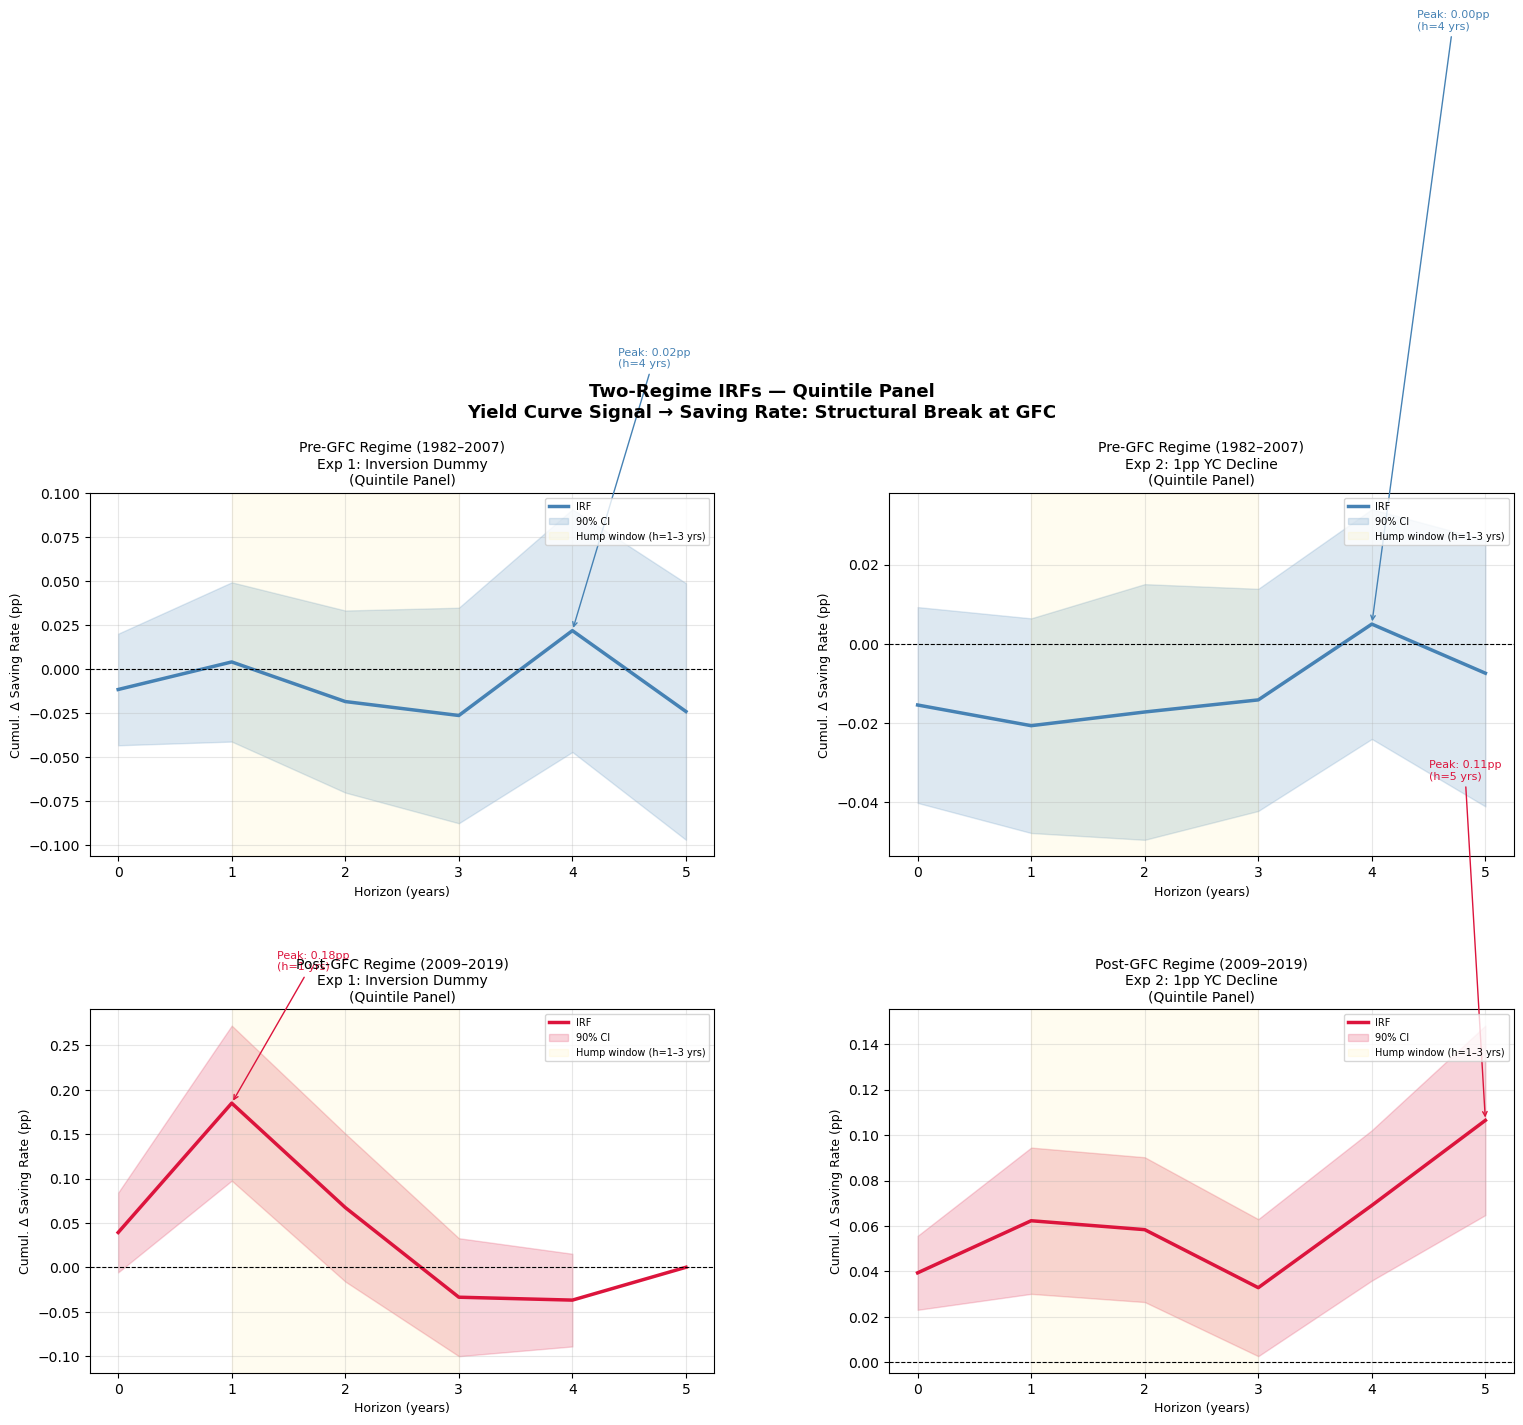


  CHOW TEST — Structural Break at 2008
  H₀: LP coefficients are stable across Pre/Post-GFC

  Exp 1: Inversion Dummy
  ──────────────────────────────────────────────────────────
    h    F-stat   p-value   df1   df2   sig
  ──────────────────────────────────────────────────────────
    0     2.900    0.0104     6   158    **
    1     4.520    0.0003     6   158   ***
    2     3.689    0.0019     6   158   ***
    3     4.474    0.0003     6   158   ***
    4     4.086    0.0008     6   158   ***
    5     3.747    0.0017     6   153   ***

  Exp 2: 1pp YC Decline
  ──────────────────────────────────────────────────────────
    h    F-stat   p-value   df1   df2   sig
  ──────────────────────────────────────────────────────────
    0     3.626    0.0021     6   158   ***
    1     4.688    0.0002     6   158   ***
    2     4.230    0.0006     6   158   ***
    3     4.611    0.0002     6   158   ***
    4     4.119    0.0007     6   158   ***
    5     4.433    0.0004     6   153   

In [58]:
##############################################################################
# QUINTILE PANEL LP — Two-Regime Split + Formal Chow Test
# Data: annual wide quintile panel merged with spread_df
# Outcome: PSR_q = 1 - (q_expenditure / q_income)
# Shocks: (1) Inversion dummy, (2) 1pp YC decline (Neg_Spread)
##############################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: Build Quintile Panel (Long Format)
# ─────────────────────────────────────────────────────────────────────────────

# -- 1a. Load quintile CSV (adjust path as needed) ----------------------------
df_raw = pd.read_csv(data_path + "/input/quintile_data.csv")

# Rename year column if needed — adjust "Year" to match your actual column name
df_raw = df_raw.rename(columns={"Year": "year"})

# -- 1b. Detect quintile numbers from column names ----------------------------
import re
quintile_nums = sorted(set(
    int(re.search(r"q(\d)", col).group(1))
    for col in df_raw.columns
    if re.search(r"q(\d)", col)
))
print(f"Detected quintiles: {quintile_nums}")

# -- 1c. Reshape to long format and compute PSR -------------------------------
rows = []
for q in quintile_nums:
    exp_col = f"q{q}_expenditure"
    inc_col = f"q{q}_income"

    if exp_col not in df_raw.columns or inc_col not in df_raw.columns:
        print(f"  Warning: missing columns for quintile {q}, skipping.")
        continue

    tmp = df_raw[["year", exp_col, inc_col]].copy()
    tmp["quintile"] = q
    tmp["PSR"] = 1.0 - (tmp[exp_col] / tmp[inc_col])   # saving rate ∈ (-∞, 1)
    tmp = tmp.rename(columns={exp_col: "expenditure", inc_col: "income"})
    rows.append(tmp[["year", "quintile", "expenditure", "income", "PSR"]])

df_panel = pd.concat(rows, ignore_index=True).sort_values(["year", "quintile"])

print(f"Panel shape: {df_panel.shape}")
print(df_panel.head(10))

# -- 1d. Merge spread and inversion dummy from spread_df ----------------------
# spread_df already contains: year, Spread, Inversion (built in your loading code)
df_panel = df_panel.merge(
    spread_df[["year", "Spread", "Inversion"]],
    on="year", how="inner"
)

# Neg_Spread: a 1pp DECLINE in spread = +1 unit shock on Neg_Spread
df_panel["Neg_Spread"] = -1.0 * df_panel["Spread"]

print(f"Panel after merge: {df_panel.shape}")
print(f"Year range: {df_panel['year'].min()}–{df_panel['year'].max()}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: Build LP Dataset (lags + outcome horizons)
# ─────────────────────────────────────────────────────────────────────────────

# -- 2a. Parameters -----------------------------------------------------------
P_LAGS = 2      # number of AR lags (annual data: 2 is standard)
MAX_H  = 5      # maximum horizon in years (annual LP: 5 is the reliable ceiling)
ALPHA  = 0.10   # 90% confidence intervals

# -- 2b. Add PSR lags (within-quintile) ---------------------------------------
df_panel = df_panel.sort_values(["quintile", "year"]).reset_index(drop=True)

for lag in range(1, P_LAGS + 1):
    df_panel[f"PSR_L{lag}"] = df_panel.groupby("quintile")["PSR"].shift(lag)

# -- 2c. Add spread lags (same for all quintiles — time-series variable) ------
for lag in range(1, P_LAGS + 1):
    df_panel[f"Spread_L{lag}"]    = df_panel.groupby("quintile")["Spread"].shift(lag)
    df_panel[f"Inversion_L{lag}"] = df_panel.groupby("quintile")["Inversion"].shift(lag)

# -- 2d. Construct cumulative outcome: PSR_{t+h} - PSR_{t-1} -----------------
df_panel["PSR_Lminus1"] = df_panel.groupby("quintile")["PSR"].shift(1)

for h in range(0, MAX_H + 1):
    df_panel[f"y_h{h}"] = (
        df_panel.groupby("quintile")["PSR"].shift(-h) - df_panel["PSR_Lminus1"]
    )

df_lp_q = df_panel.copy()
print(f"\nLP quintile dataset shape: {df_lp_q.shape}")
print(f"Columns: {list(df_lp_q.columns)}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: LP Estimation Function (Panel, Annual)
# ─────────────────────────────────────────────────────────────────────────────

LAG_CONTROLS = (
    [f"PSR_L{l}"       for l in range(1, P_LAGS + 1)] +
    [f"Spread_L{l}"    for l in range(1, P_LAGS + 1)]
)

def estimate_quintile_lp(df, start_year, end_year, x_var, max_h=MAX_H):
    """
    Estimates panel LP for a given sub-period.

    The regression at each horizon h is:
        y_{i,t+h} - y_{i,t-1} = α + β·x_{i,t} + Σ γ_l·controls_{i,t-l} + ε_{i,t}

    where i indexes quintile and t indexes year.
    Pooled OLS with HC1 heteroskedasticity-robust SEs.
    No quintile FE here (saves degrees of freedom in short regimes);
    quintile heterogeneity is absorbed by the lagged PSR controls.

    Parameters
    ----------
    df         : df_lp_q
    start_year : int
    end_year   : int
    x_var      : str — "Inversion" or "Neg_Spread"
    max_h      : int

    Returns
    -------
    DataFrame: h, coef, se, ci_low, ci_high
    """
    mask   = (df["year"] >= start_year) & (df["year"] <= end_year)
    df_sub = df[mask].copy()

    lag_cols = [c for c in LAG_CONTROLS if c in df_sub.columns]

    results = []
    for h in range(0, max_h + 1):
        outcome_col = f"y_h{h}"
        if outcome_col not in df_sub.columns:
            continue

        cols_needed = [outcome_col, x_var] + lag_cols
        sub = df_sub[cols_needed].dropna()

        if len(sub) < 20:
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})
            continue

        X = pd.concat(
            [pd.Series(1.0, index=sub.index, name="const"),
             sub[[x_var] + lag_cols]],
            axis=1
        ).astype(float)
        y    = sub[outcome_col].astype(float)
        Xmat = X.values
        yvec = y.values

        try:
            XtX_inv = np.linalg.pinv(Xmat.T @ Xmat)
            beta    = XtX_inv @ (Xmat.T @ yvec)
            resid   = yvec - Xmat @ beta
            n, k    = Xmat.shape

            # HC1 robust covariance (White, 1980)
            meat   = (Xmat * resid[:, None]).T @ (Xmat * resid[:, None])
            V_cov  = (n / (n - k)) * XtX_inv @ meat @ XtX_inv
            se_vec = np.sqrt(np.diag(V_cov))

            coef_val = beta[1]
            se_val   = se_vec[1]
            t_crit   = scipy_stats.t.ppf(1 - ALPHA / 2, df=n - k)

            results.append({
                "h":       h,
                "coef":    coef_val,
                "se":      se_val,
                "ci_low":  coef_val - t_crit * se_val,
                "ci_high": coef_val + t_crit * se_val,
            })
        except np.linalg.LinAlgError:
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})

    return pd.DataFrame(results)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: Estimate All Regime IRFs
# ─────────────────────────────────────────────────────────────────────────────

print("Estimating quintile panel LPs…")

# Experiment 1 — Inversion dummy
q_irf1_A = estimate_quintile_lp(df_lp_q, 1982, 2007, "Inversion")   # Pre-GFC
q_irf1_C = estimate_quintile_lp(df_lp_q, 2009, 2019, "Inversion")   # Post-GFC
q_irf1_B = estimate_quintile_lp(df_lp_q, 1982, 2019, "Inversion")   # Full

# Experiment 2 — 1pp YC Decline
q_irf2_A = estimate_quintile_lp(df_lp_q, 1982, 2007, "Neg_Spread")
q_irf2_C = estimate_quintile_lp(df_lp_q, 2009, 2019, "Neg_Spread")
q_irf2_B = estimate_quintile_lp(df_lp_q, 1982, 2019, "Neg_Spread")

print("Done.")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: Two-Regime IRF Plot
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

regime_specs = [
    (q_irf1_A, q_irf1_C, "Exp 1: Inversion Dummy\n(Quintile Panel)"),
    (q_irf2_A, q_irf2_C, "Exp 2: 1pp YC Decline\n(Quintile Panel)"),
]
plot_rows = [
    ("steelblue", "Pre-GFC Regime (1982–2007)"),
    ("crimson",   "Post-GFC Regime (2009–2019)"),
]

for col, (irf_pre, irf_post, exp_title) in enumerate(regime_specs):
    for row, (irf_df, (color, regime_label)) in enumerate(
            zip([irf_pre, irf_post], plot_rows)):

        ax = axes[row, col]

        if irf_df.empty or irf_df["coef"].isna().all():
            ax.text(0.5, 0.5, "Insufficient variation\nto estimate regime",
                    ha="center", va="center", transform=ax.transAxes,
                    color="gray", fontsize=10)
            ax.set_title(f"{regime_label}\n{exp_title}", fontsize=10)
            continue

        ax.plot(irf_df["h"], irf_df["coef"],
                color=color, linewidth=2.5, label="IRF")
        ax.fill_between(irf_df["h"], irf_df["ci_low"], irf_df["ci_high"],
                        alpha=0.18, color=color, label="90% CI")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.axvspan(1, 3, alpha=0.06, color="gold",
                   label="Hump window (h=1–3 yrs)")

        valid = irf_df.dropna(subset=["coef"])
        if not valid.empty:
            peak_idx = valid["coef"].idxmax()
            peak_h   = valid.loc[peak_idx, "h"]
            peak_val = valid.loc[peak_idx, "coef"]
            ax.annotate(
                f"Peak: {peak_val:.2f}pp\n(h={peak_h} yrs)",
                xy=(peak_h, peak_val),
                xytext=(min(peak_h + 0.4, MAX_H - 0.5), peak_val + 0.15),
                arrowprops=dict(arrowstyle="->", color=color),
                fontsize=8, color=color,
            )

        ax.set_title(f"{regime_label}\n{exp_title}", fontsize=10)
        ax.set_xlabel("Horizon (years)", fontsize=9)
        ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle(
    "Two-Regime IRFs — Quintile Panel\n"
    "Yield Curve Signal → Saving Rate: Structural Break at GFC",
    fontsize=13, fontweight="bold",
)
plt.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.97,
                    hspace=0.42, wspace=0.28)
plt.savefig("quintile_two_regime_irf.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: Formal Chow Test for Structural Break at 2008
# ─────────────────────────────────────────────────────────────────────────────
# The Chow test checks whether the LP coefficients are stable across sub-periods.
# At each horizon h, we run:
#   Unrestricted: separate regressions for Pre-GFC and Post-GFC
#   Restricted:   single pooled regression over the full sample (1982–2019)
# The F-statistic compares RSS_restricted vs (RSS_pre + RSS_post).
# Reference: Chow (1960, Econometrica).

def chow_test_at_horizon(df, h, x_var, break_year=2008,
                          pre_start=1982, pre_end=2007,
                          post_start=2009, post_end=2019):
    """
    Chow test for a structural break at break_year in the LP at horizon h.

    Returns dict with F-stat, p-value, df1, df2.
    """
    outcome_col = f"y_h{h}"
    lag_cols    = [c for c in LAG_CONTROLS if c in df.columns]
    cols_needed = [outcome_col, x_var, "year"] + lag_cols

    df_all  = df[(df["year"] >= pre_start)  & (df["year"] <= post_end)][cols_needed].dropna()
    df_pre  = df[(df["year"] >= pre_start)  & (df["year"] <= pre_end)][cols_needed].dropna()
    df_post = df[(df["year"] >= post_start) & (df["year"] <= post_end)][cols_needed].dropna()

    def ols_rss(data):
        X = pd.concat(
            [pd.Series(1.0, index=data.index, name="const"),
             data[[x_var] + lag_cols]],
            axis=1
        ).astype(float).values
        y = data[outcome_col].astype(float).values
        if len(y) < X.shape[1] + 2:
            return np.nan, 0, 0
        beta  = np.linalg.pinv(X.T @ X) @ (X.T @ y)
        resid = y - X @ beta
        return (resid ** 2).sum(), len(y), X.shape[1]

    rss_r,  n_r,  k   = ols_rss(df_all)
    rss_1,  n_1,  _   = ols_rss(df_pre)
    rss_2,  n_2,  _   = ols_rss(df_post)

    if np.isnan(rss_r) or np.isnan(rss_1) or np.isnan(rss_2):
        return {"h": h, "F": np.nan, "p": np.nan, "df1": np.nan, "df2": np.nan}

    rss_u = rss_1 + rss_2     # unrestricted: both sub-samples free
    df1   = k                  # number of restrictions = number of params
    df2   = n_r - 2 * k        # residual df of unrestricted model

    if df2 <= 0 or rss_u <= 0:
        return {"h": h, "F": np.nan, "p": np.nan, "df1": df1, "df2": df2}

    F_stat = ((rss_r - rss_u) / df1) / (rss_u / df2)
    p_val  = scipy_stats.f.sf(F_stat, df1, df2)

    return {"h": h, "F": round(F_stat, 3), "p": round(p_val, 4),
            "df1": df1, "df2": df2}


# Run Chow test at every horizon for both experiments
print("\n" + "=" * 65)
print("  CHOW TEST — Structural Break at 2008")
print("  H₀: LP coefficients are stable across Pre/Post-GFC")
print("=" * 65)

for x_var, exp_label in [("Inversion", "Exp 1: Inversion Dummy"),
                           ("Neg_Spread", "Exp 2: 1pp YC Decline")]:
    print(f"\n  {exp_label}")
    print(f"  {'─'*58}")
    print(f"  {'h':>3}  {'F-stat':>8}  {'p-value':>8}  {'df1':>4}  {'df2':>4}  {'sig':>4}")
    print(f"  {'─'*58}")

    chow_results = []
    for h in range(0, MAX_H + 1):
        res = chow_test_at_horizon(df_lp_q, h, x_var)
        chow_results.append(res)
        stars = ("***" if res["p"] < 0.01 else "**" if res["p"] < 0.05
                 else "*" if res["p"] < 0.10 else ""
                 ) if not np.isnan(res["p"]) else "—"
        F_str = f"{res['F']:.3f}" if not np.isnan(res["F"]) else "  NaN"
        p_str = f"{res['p']:.4f}" if not np.isnan(res["p"]) else "  NaN"
        print(f"  {h:>3}  {F_str:>8}  {p_str:>8}  "
              f"{int(res['df1']) if not np.isnan(res['df1']) else '—':>4}  "
              f"{int(res['df2']) if not np.isnan(res['df2']) else '—':>4}  "
              f"{stars:>4}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: Joint Chi2 Tests by Regime
# ─────────────────────────────────────────────────────────────────────────────

def joint_chi2_regime(irf, label, h_lo=1, h_hi=3):
    subset = irf[irf["h"].between(h_lo, h_hi) & irf["coef"].notna()].copy()

    if subset.empty or "se" not in subset.columns:
        print(f"\n  {label}\n  {'─'*58}\n  Insufficient data.")
        return None

    subset["z_stat"] = subset["coef"] / subset["se"]
    subset["pval_z"] = 2 * (1 - scipy_stats.norm.cdf(abs(subset["z_stat"])))

    chi2    = (subset["z_stat"] ** 2).sum()
    df_chi  = len(subset)
    p_joint = scipy_stats.chi2.sf(chi2, df=df_chi)
    stars   = ("***" if p_joint < 0.01 else "**" if p_joint < 0.05
               else "*" if p_joint < 0.10 else "")

    print(f"\n  {label}")
    print(f"  {'─'*58}")
    print(f"  Joint Chi2 = {chi2:.3f}  |  df = {df_chi}  |  p = {p_joint:.4f} {stars}")

    top_n = min(3, len(subset))
    top   = (subset.nsmallest(top_n, "pval_z")
                   [["h", "coef", "se", "pval_z"]]
                   .rename(columns={"pval_z": "p-val"}))
    print(f"  Most significant horizons:\n{top.to_string(index=False)}")
    return {"label": label, "chi2": round(chi2,3), "df": df_chi,
            "p": round(p_joint,4), "stars": stars}

print("\n" + "=" * 65)
print("  JOINT CHI2 — Exp 1: Inversion Dummy")
print("=" * 65)
joint_chi2_regime(q_irf1_A, "Pre-GFC  (1982–2007)")
joint_chi2_regime(q_irf1_C, "Post-GFC (2009–2019)")

print("\n" + "=" * 65)
print("  JOINT CHI2 — Exp 2: 1pp YC Decline")
print("=" * 65)
joint_chi2_regime(q_irf2_A, "Pre-GFC  (1982–2007)")
joint_chi2_regime(q_irf2_C, "Post-GFC (2009–2019)")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: Coefficient Table at Key Horizons
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n\n{'='*72}")
print("  COEFFICIENT TABLE — Exp 2: 1pp YC Decline (Quintile Panel)")
print(f"  [[coef]] = significant at 10% (90% CI excludes zero)")
print(f"{'='*72}")

rows = []
for h in range(0, MAX_H + 1):
    row = {"h (yrs)": h}
    for irf_df, col_label in [(q_irf2_A, "Pre-GFC"),
                               (q_irf2_C, "Post-GFC"),
                               (q_irf2_B, "Full sample")]:
        sub = irf_df[irf_df["h"] == h]
        if sub.empty or pd.isna(sub.iloc[0]["coef"]):
            row[f"{col_label} β"]  = "—"
            row[f"{col_label} CI"] = "—"
            continue
        r   = sub.iloc[0]
        sig = (r["ci_low"] > 0) or (r["ci_high"] < 0)
        row[f"{col_label} β"]  = f"[[{r['coef']:.3f}]]" if sig else f"{r['coef']:.3f}"
        row[f"{col_label} CI"] = f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]"
    rows.append(row)

print(pd.DataFrame(rows).set_index("h (yrs)").to_string())

#### 4.1.2 QUINTILE-SPECIFIC IRFs 

Estimating quintile-specific LPs…
  Q1 done.
  Q2 done.
  Q3 done.
  Q4 done.
  Q5 done.
Done.


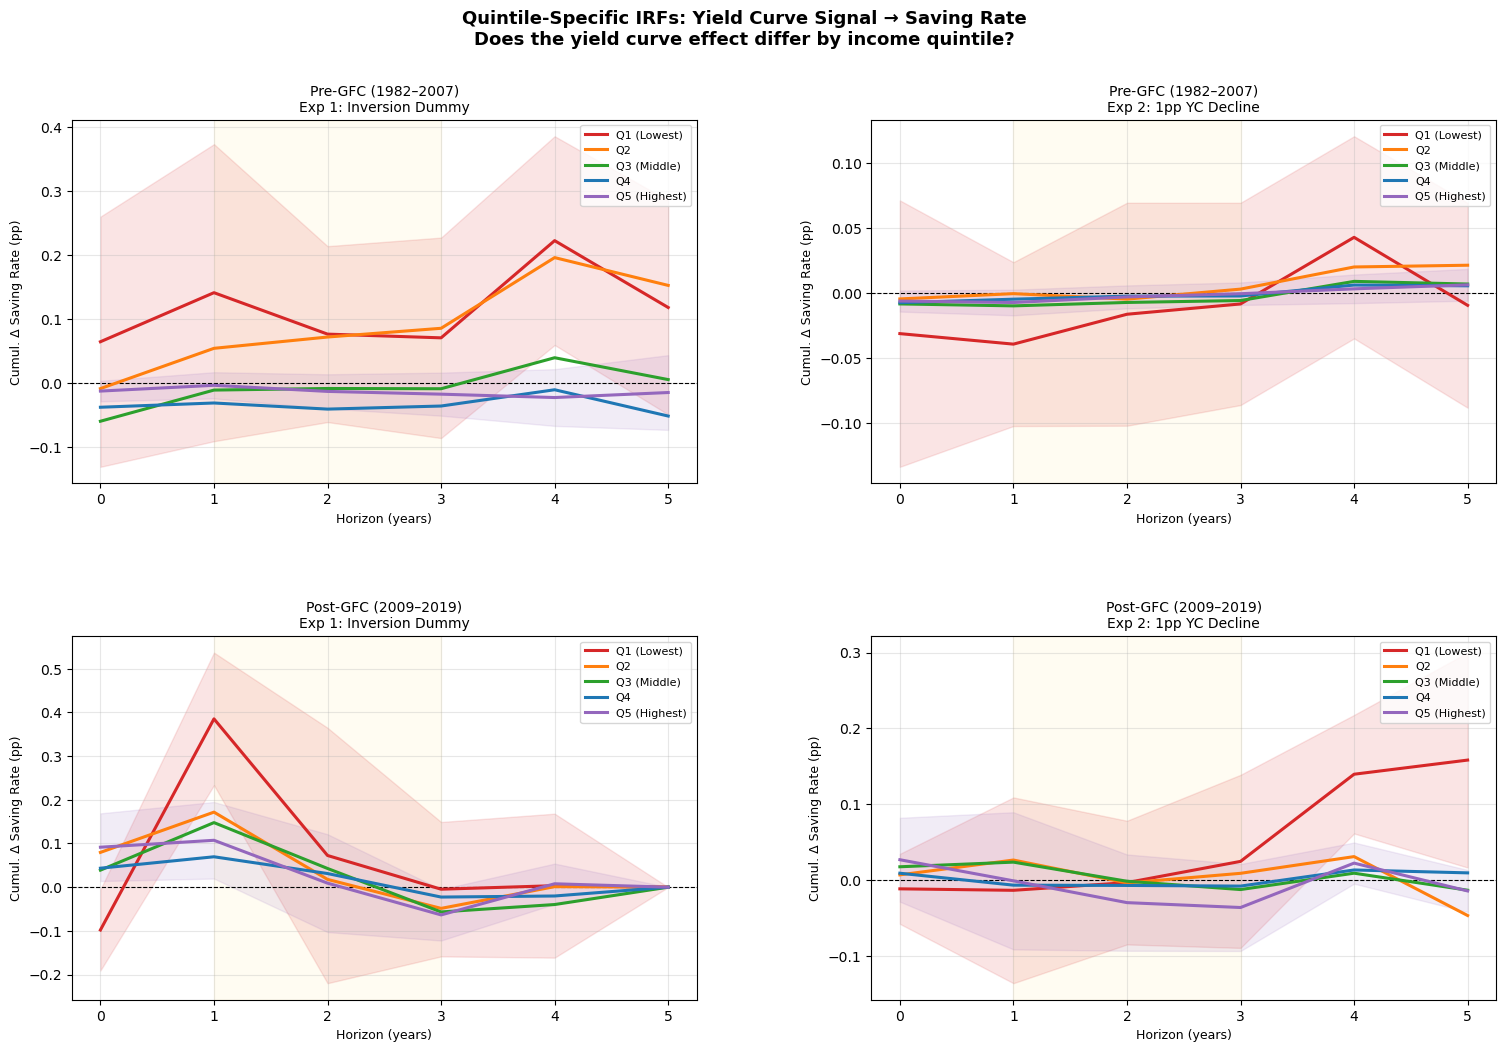


  PEAK RESPONSE TABLE — Post-GFC Regime (2009–2019)
  Exp 2: 1pp YC Decline  |  horizon where |coef| is maximised
  ────────────────────────────────────────────────────────────────────
  Quintile           Peak β   at h       SE   CI_low  CI_high   Sig?
  ────────────────────────────────────────────────────────────────────
  Q1 (Lowest)         0.158      5    0.073    0.016    0.300      ✓
  Q2                 -0.047      5    0.057   -0.157    0.063       
  Q3 (Middle)         0.024      1    0.038   -0.049    0.096       
  Q4                  0.013      4    0.009   -0.004    0.030       
  Q5 (Highest)       -0.036      3    0.030   -0.094    0.021       

  Sig? = 90% CI excludes zero
  Hypothesis: Q1 peak β < Q5 peak β (lower quintiles less sensitive)


In [59]:
##############################################################################
# QUINTILE-SPECIFIC IRFs — Does the yield curve effect differ by income group?
# Hypothesis: lower quintiles are LESS sensitive (precautionary motive weaker
# when households are already liquidity-constrained and cannot adjust saving)
##############################################################################

# ─────────────────────────────────────────────────────────────────────────────
# SECTION A: LP estimation per quintile
# ─────────────────────────────────────────────────────────────────────────────

def estimate_lp_single_quintile(df, quintile_id, start_year, end_year,
                                  x_var, max_h=MAX_H):
    """
    Runs LP for a SINGLE quintile over a given sub-period.
    
    With only one quintile, the time-series dimension is ~26 obs (Pre-GFC)
    or ~11 obs (Post-GFC). We keep P_LAGS=1 here to preserve degrees of 
    freedom — using 2 lags on 11 obs would be unreliable.
    """
    mask   = ((df["quintile"] == quintile_id) &
              (df["year"] >= start_year) &
              (df["year"] <= end_year))
    df_sub = df[mask].copy().sort_values("year")

    # Use only 1 lag per variable when the sub-sample is short
    n_obs   = len(df_sub)
    p_local = 1 if n_obs < 20 else P_LAGS
    lag_cols = [f"PSR_L{l}" for l in range(1, p_local + 1)] + \
               [f"Spread_L{l}" for l in range(1, p_local + 1)]
    lag_cols = [c for c in lag_cols if c in df_sub.columns]

    results = []
    for h in range(0, max_h + 1):
        outcome_col = f"y_h{h}"
        if outcome_col not in df_sub.columns:
            continue

        cols_needed = [outcome_col, x_var] + lag_cols
        sub = df_sub[cols_needed].dropna()

        # Minimum obs: k+2 where k = number of regressors
        k_regs = 1 + 1 + len(lag_cols)   # const + x_var + lags
        if len(sub) < k_regs + 2:
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})
            continue

        X = pd.concat(
            [pd.Series(1.0, index=sub.index, name="const"),
             sub[[x_var] + lag_cols]],
            axis=1
        ).astype(float)
        y    = sub[outcome_col].astype(float)
        Xmat = X.values
        yvec = y.values

        try:
            XtX_inv  = np.linalg.pinv(Xmat.T @ Xmat)
            beta     = XtX_inv @ (Xmat.T @ yvec)
            resid    = yvec - Xmat @ beta
            n, k     = Xmat.shape

            meat    = (Xmat * resid[:, None]).T @ (Xmat * resid[:, None])
            V_cov   = (n / (n - k)) * XtX_inv @ meat @ XtX_inv
            se_vec  = np.sqrt(np.diag(V_cov))

            coef_val = beta[1]
            se_val   = se_vec[1]
            t_crit   = scipy_stats.t.ppf(1 - ALPHA / 2, df=n - k)

            results.append({
                "h":       h,
                "coef":    coef_val,
                "se":      se_val,
                "ci_low":  coef_val - t_crit * se_val,
                "ci_high": coef_val + t_crit * se_val,
            })
        except np.linalg.LinAlgError:
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})

    return pd.DataFrame(results)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION B: Estimate IRFs for each quintile × regime × experiment
# ─────────────────────────────────────────────────────────────────────────────

QUINTILES    = [1, 2, 3, 4, 5]
Q_LABELS     = {1: "Q1 (Lowest)", 2: "Q2", 3: "Q3 (Middle)",
                4: "Q4", 5: "Q5 (Highest)"}
Q_COLORS     = {1: "#d62728", 2: "#ff7f0e", 3: "#2ca02c",
                4: "#1f77b4", 5: "#9467bd"}

print("Estimating quintile-specific LPs…")

irf_by_q = {}
for q in QUINTILES:
    irf_by_q[q] = {
        "pre_inv":  estimate_lp_single_quintile(
                        df_lp_q, q, 1982, 2007, "Inversion"),
        "post_inv": estimate_lp_single_quintile(
                        df_lp_q, q, 2009, 2019, "Inversion"),
        "pre_neg":  estimate_lp_single_quintile(
                        df_lp_q, q, 1982, 2007, "Neg_Spread"),
        "post_neg": estimate_lp_single_quintile(
                        df_lp_q, q, 2009, 2019, "Neg_Spread"),
    }
    print(f"  Q{q} done.")

print("Done.")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION C: Plot — All quintiles overlaid, by regime and experiment
# ─────────────────────────────────────────────────────────────────────────────
# Layout: 2 rows (Pre-GFC / Post-GFC) × 2 cols (Exp1 / Exp2)
# Each panel overlays Q1–Q5 IRFs (point estimates only, for readability)
# with shaded CI only for Q1 and Q5 to show the range

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

scenarios = [
    ("pre_inv",  "post_inv", "Exp 1: Inversion Dummy"),
    ("pre_neg",  "post_neg", "Exp 2: 1pp YC Decline"),
]
regime_labels = ["Pre-GFC (1982–2007)", "Post-GFC (2009–2019)"]

for col, (pre_key, post_key, exp_title) in enumerate(scenarios):
    for row, (regime_key, regime_label) in enumerate(
            zip([pre_key, post_key], regime_labels)):

        ax = axes[row, col]
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.axvspan(1, 3, alpha=0.05, color="gold")

        any_plotted = False
        for q in QUINTILES:
            irf = irf_by_q[q][regime_key]
            if irf.empty or irf["coef"].isna().all():
                continue

            color = Q_COLORS[q]
            label = Q_LABELS[q]

            ax.plot(irf["h"], irf["coef"],
                    color=color, linewidth=2.2,
                    label=label, zorder=3)

            # Shaded CI only for Q1 and Q5 to avoid visual clutter
            if q in [1, 5]:
                ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                                alpha=0.12, color=color)
            any_plotted = True

        if not any_plotted:
            ax.text(0.5, 0.5, "Insufficient data",
                    ha="center", va="center",
                    transform=ax.transAxes, color="gray")

        ax.set_title(f"{regime_label}\n{exp_title}", fontsize=10)
        ax.set_xlabel("Horizon (years)", fontsize=9)
        ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(alpha=0.3)

plt.suptitle(
    "Quintile-Specific IRFs: Yield Curve Signal → Saving Rate\n"
    "Does the yield curve effect differ by income quintile?",
    fontsize=13, fontweight="bold",
)
plt.subplots_adjust(top=0.88, bottom=0.08, left=0.08, right=0.97,
                    hspace=0.42, wspace=0.28)
plt.savefig("quintile_specific_irfs.png", dpi=150, bbox_inches="tight")
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# SECTION D: Peak coefficient table — one row per quintile
# Summarises the maximum IRF response in the Post-GFC regime
# This is the key table for testing your hypothesis
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*70}")
print("  PEAK RESPONSE TABLE — Post-GFC Regime (2009–2019)")
print("  Exp 2: 1pp YC Decline  |  horizon where |coef| is maximised")
print(f"  {'─'*68}")
print(f"  {'Quintile':<16} {'Peak β':>8} {'at h':>6} "
      f"{'SE':>8} {'CI_low':>8} {'CI_high':>8} {'Sig?':>6}")
print(f"  {'─'*68}")

for q in QUINTILES:
    irf = irf_by_q[q]["post_neg"]
    valid = irf.dropna(subset=["coef"])
    if valid.empty:
        print(f"  {Q_LABELS[q]:<16} {'—':>8}")
        continue
    peak_idx = valid["coef"].abs().idxmax()   # peak by absolute magnitude
    r        = valid.loc[peak_idx]
    sig      = "✓" if (r["ci_low"] > 0 or r["ci_high"] < 0) else ""
    print(f"  {Q_LABELS[q]:<16} {r['coef']:>8.3f} {int(r['h']):>6} "
          f"{r['se']:>8.3f} {r['ci_low']:>8.3f} {r['ci_high']:>8.3f} {sig:>6}")

print(f"\n  Sig? = 90% CI excludes zero")
print(f"  Hypothesis: Q1 peak β < Q5 peak β (lower quintiles less sensitive)")

In [60]:
print(irf_by_q[1]["post_neg"].to_string())

   h      coef        se    ci_low   ci_high
0  0 -0.011704  0.024371 -0.057876  0.034468
1  1 -0.013657  0.064668 -0.136176  0.108863
2  2 -0.003483  0.043049 -0.085043  0.078078
3  3  0.024514  0.060244 -0.089623  0.138652
4  4  0.139486  0.041258  0.061319  0.217653
5  5  0.158146  0.072953  0.016385  0.299908


### 4.2 Whole sample

#### 4.2.1 Pooled quintile data

Estimating pooled LP — full sample (1982–2019)…
Done.


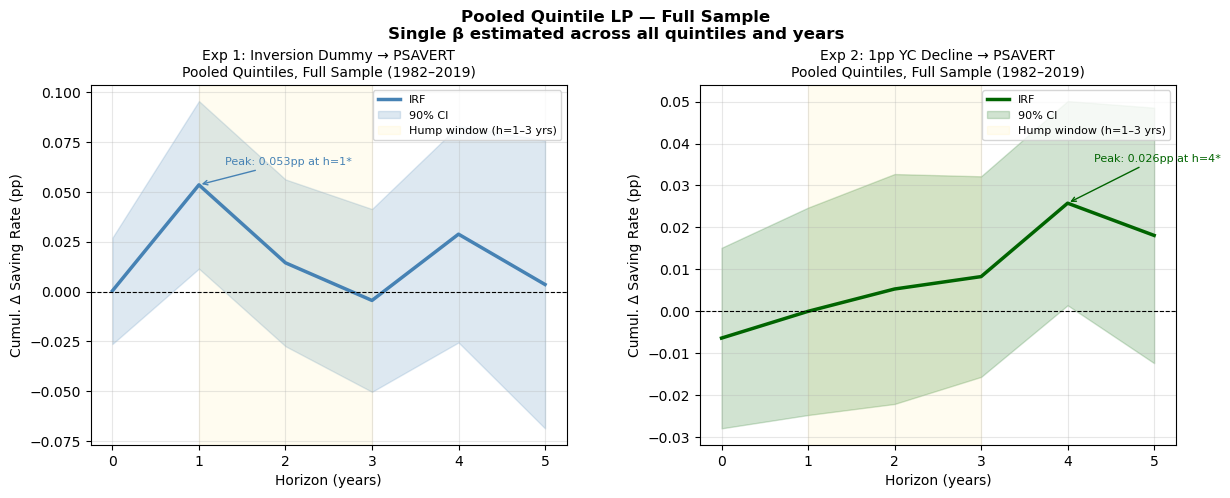


  POOLED FULL SAMPLE — Coefficient Table
  [[coef]] = 90% CI excludes zero
     h       Inv β              Inv CI       Neg β              Neg CI
  ──────────────────────────────────────────────────────────────
     0       0.000     [-0.026, 0.027]      -0.006     [-0.028, 0.015]
     1   [[0.053]]      [0.011, 0.095]      -0.000     [-0.025, 0.025]
     2       0.014     [-0.027, 0.056]       0.005     [-0.022, 0.033]
     3      -0.004     [-0.050, 0.041]       0.008     [-0.016, 0.032]
     4       0.029     [-0.025, 0.083]   [[0.026]]      [0.001, 0.050]
     5       0.004     [-0.069, 0.076]       0.018     [-0.012, 0.049]


In [61]:
##############################################################################
# FULL SAMPLE — Pooled Quintile LP (1982–2019)
##############################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings("ignore")

# ── Parameters ────────────────────────────────────────────────────────────────
MAX_H  = 5
ALPHA  = 0.10
P_LAGS = 2

LAG_CONTROLS = (
    [f"PSR_L{l}"    for l in range(1, P_LAGS + 1)] +
    [f"Spread_L{l}" for l in range(1, P_LAGS + 1)]
)

# ── Estimate ──────────────────────────────────────────────────────────────────
print("Estimating pooled LP — full sample (1982–2019)…")

irf_full_inv = estimate_quintile_lp(df_lp_q, 1982, 2019, "Inversion")
irf_full_neg = estimate_quintile_lp(df_lp_q, 1982, 2019, "Neg_Spread")

print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, irf, title, color in [
    (axes[0], irf_full_inv,
     "Exp 1: Inversion Dummy → PSAVERT\nPooled Quintiles, Full Sample (1982–2019)",
     "steelblue"),
    (axes[1], irf_full_neg,
     "Exp 2: 1pp YC Decline → PSAVERT\nPooled Quintiles, Full Sample (1982–2019)",
     "darkgreen"),
]:
    valid = irf.dropna(subset=["coef"])

    ax.plot(irf["h"], irf["coef"], color=color, linewidth=2.5, label="IRF")
    ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                    alpha=0.18, color=color, label="90% CI")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvspan(1, 3, alpha=0.06, color="gold", label="Hump window (h=1–3 yrs)")

    if not valid.empty:
        peak_idx = valid["coef"].idxmax()
        peak_h   = valid.loc[peak_idx, "h"]
        peak_val = valid.loc[peak_idx, "coef"]
        sig      = (valid.loc[peak_idx, "ci_low"] > 0 or
                    valid.loc[peak_idx, "ci_high"] < 0)
        label_str = f"Peak: {peak_val:.3f}pp at h={peak_h}{'*' if sig else ''}"
        ax.annotate(label_str,
                    xy=(peak_h, peak_val),
                    xytext=(peak_h + 0.3, peak_val + 0.01),
                    arrowprops=dict(arrowstyle="->", color=color),
                    fontsize=8, color=color)

    ax.set_xlabel("Horizon (years)", fontsize=10)
    ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Pooled Quintile LP — Full Sample\n"
    "Single β estimated across all quintiles and years",
    fontsize=12, fontweight="bold"
)
plt.subplots_adjust(top=0.83, wspace=0.28)
plt.savefig("pooled_full_sample.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Coefficient table ─────────────────────────────────────────────────────────
print(f"\n{'='*62}")
print("  POOLED FULL SAMPLE — Coefficient Table")
print(f"  [[coef]] = 90% CI excludes zero")
print(f"{'='*62}")
print(f"  {'h':>4}  {'Inv β':>10}  {'Inv CI':>18}  "
      f"{'Neg β':>10}  {'Neg CI':>18}")
print(f"  {'─'*62}")

for h in range(0, MAX_H + 1):
    row_i = irf_full_inv[irf_full_inv["h"] == h].iloc[0]
    row_n = irf_full_neg[irf_full_neg["h"] == h].iloc[0]

    def fmt(r):
        if pd.isna(r["coef"]):
            return "—", "—"
        sig  = (r["ci_low"] > 0) or (r["ci_high"] < 0)
        coef = f"[[{r['coef']:.3f}]]" if sig else f"{r['coef']:.3f}"
        ci   = f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]"
        return coef, ci

    ci_i, ci_str_i = fmt(row_i)
    ci_n, ci_str_n = fmt(row_n)
    print(f"  {h:>4}  {ci_i:>10}  {ci_str_i:>18}  {ci_n:>10}  {ci_str_n:>18}")

#### 4.2.2 By quintile

Estimating quintile-specific LPs — full sample (1982–2019)…
  Q1 done.
  Q2 done.
  Q3 done.
  Q4 done.
  Q5 done.
Done.


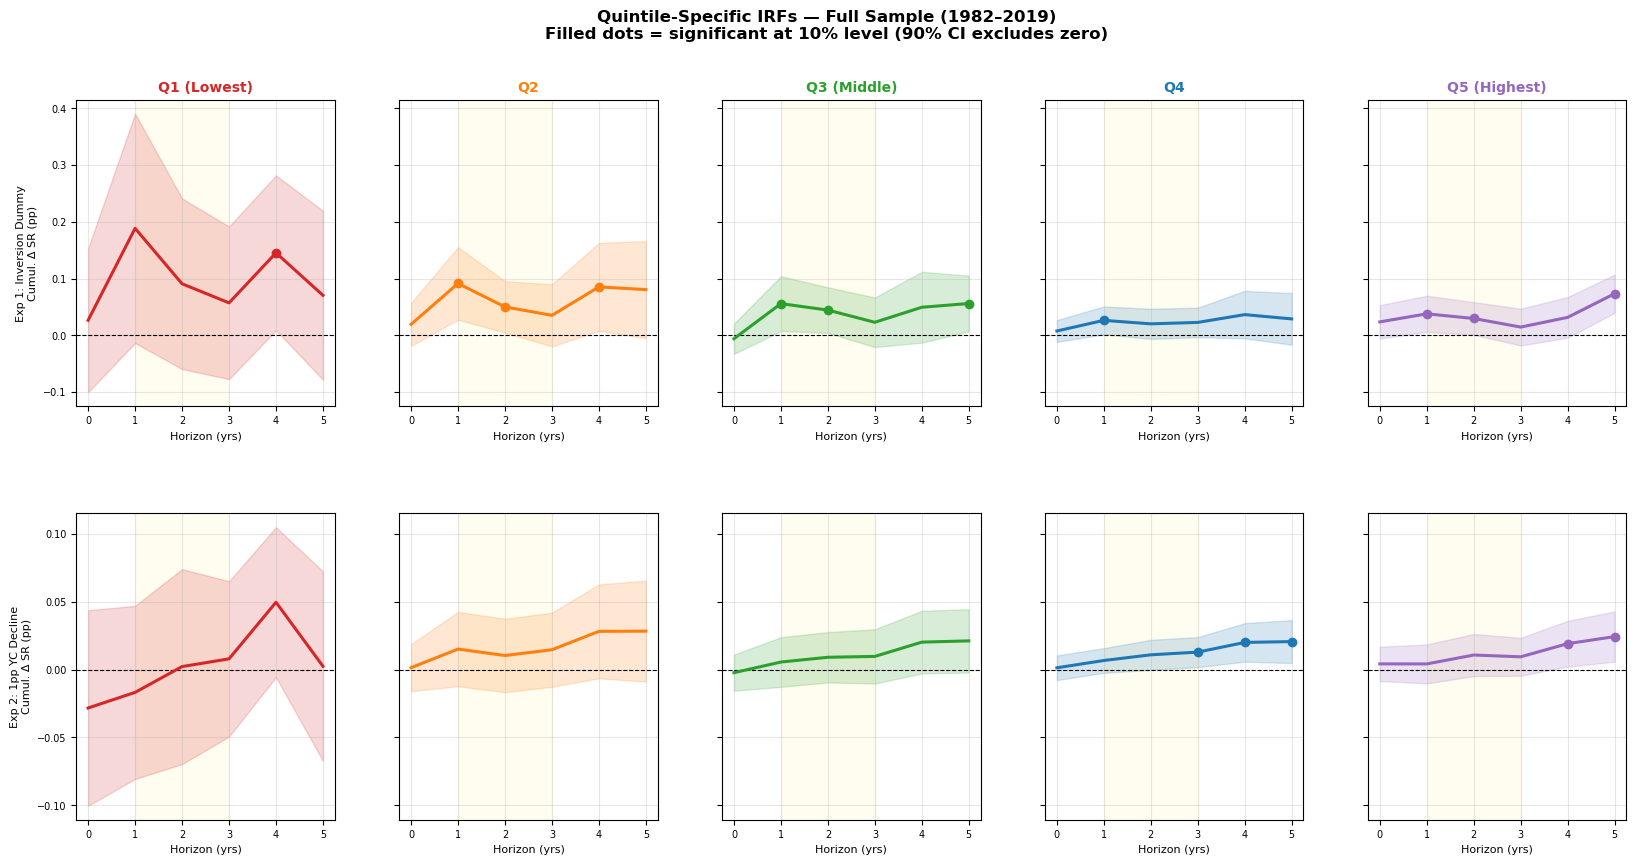


  PEAK RESPONSE — Full Sample (1982–2019), Exp 2: 1pp YC Decline
  [[coef]] = significant at 10%
  ──────────────────────────────────────────────────────────────────────
  Quintile           Peak β   at h       SE   CI_low  CI_high   Sig?
  ──────────────────────────────────────────────────────────────────────
  Q1 (Lowest)         0.050      4    0.032   -0.006    0.105       
  Q2                  0.028      5    0.022   -0.009    0.066       
  Q3 (Middle)         0.021      5    0.014   -0.002    0.045       
  Q4                  0.021      5    0.009    0.005    0.036      ✓
  Q5 (Highest)        0.024      5    0.011    0.006    0.043      ✓

  Hypothesis: Q1 peak β < Q5 peak β
  Q1 peak = 0.050  |  Q5 peak = 0.024  →  Q1 > Q5 ✗ (hypothesis rejected)


In [62]:
##############################################################################
# FULL SAMPLE — Quintile-Specific LPs (1982–2019)
##############################################################################

# ── Estimate one IRF per quintile ─────────────────────────────────────────────
print("Estimating quintile-specific LPs — full sample (1982–2019)…")

irf_full_by_q = {}
for q in QUINTILES:
    irf_full_by_q[q] = {
        "inv": estimate_lp_single_quintile(
                   df_lp_q, q, 1982, 2019, "Inversion", max_h=MAX_H),
        "neg": estimate_lp_single_quintile(
                   df_lp_q, q, 1982, 2019, "Neg_Spread", max_h=MAX_H),
    }
    print(f"  Q{q} done.")

print("Done.")

# ── Plot: 2 rows (Exp1 / Exp2) × 5 cols (Q1–Q5) ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 9), sharey="row")

for col, q in enumerate(QUINTILES):
    color = Q_COLORS[q]

    for row, (exp_key, exp_label) in enumerate([
        ("inv", "Exp 1: Inversion Dummy"),
        ("neg", "Exp 2: 1pp YC Decline"),
    ]):
        ax  = axes[row, col]
        irf = irf_full_by_q[q][exp_key]

        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.axvspan(1, 3, alpha=0.06, color="gold")

        if irf.empty or irf["coef"].isna().all():
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
        else:
            ax.plot(irf["h"], irf["coef"],
                    color=color, linewidth=2.2)
            ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                            alpha=0.18, color=color)

            # Mark significant horizons with a dot
            for _, r in irf.iterrows():
                if pd.notna(r["ci_low"]) and (r["ci_low"] > 0 or r["ci_high"] < 0):
                    ax.plot(r["h"], r["coef"], "o",
                            color=color, markersize=6, zorder=4)

        if row == 0:
            ax.set_title(f"{Q_LABELS[q]}", fontsize=10, fontweight="bold",
                         color=color)
        if col == 0:
            ax.set_ylabel(f"{exp_label}\nCumul. Δ SR (pp)", fontsize=8)
        ax.set_xlabel("Horizon (yrs)", fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)

plt.suptitle(
    "Quintile-Specific IRFs — Full Sample (1982–2019)\n"
    "Filled dots = significant at 10% level (90% CI excludes zero)",
    fontsize=12, fontweight="bold"
)
plt.subplots_adjust(top=0.88, bottom=0.08, hspace=0.35, wspace=0.25)
plt.savefig("quintile_specific_full_sample.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary peak table ────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print("  PEAK RESPONSE — Full Sample (1982–2019), Exp 2: 1pp YC Decline")
print(f"  [[coef]] = significant at 10%")
print(f"  {'─'*70}")
print(f"  {'Quintile':<16} {'Peak β':>8} {'at h':>6} "
      f"{'SE':>8} {'CI_low':>8} {'CI_high':>8} {'Sig?':>6}")
print(f"  {'─'*70}")

for q in QUINTILES:
    irf   = irf_full_by_q[q]["neg"]
    valid = irf.dropna(subset=["coef"])
    if valid.empty:
        print(f"  {Q_LABELS[q]:<16} {'—':>8}")
        continue
    peak_idx = valid["coef"].abs().idxmax()
    r        = valid.loc[peak_idx]
    sig      = "✓" if (r["ci_low"] > 0 or r["ci_high"] < 0) else ""
    print(f"  {Q_LABELS[q]:<16} {r['coef']:>8.3f} {int(r['h']):>6} "
          f"{r['se']:>8.3f} {r['ci_low']:>8.3f} {r['ci_high']:>8.3f} {sig:>6}")

print(f"\n  Hypothesis: Q1 peak β < Q5 peak β")
q1_peak = irf_full_by_q[1]["neg"].dropna(subset=["coef"])
q5_peak = irf_full_by_q[5]["neg"].dropna(subset=["coef"])
if not q1_peak.empty and not q5_peak.empty:
    b1 = q1_peak.loc[q1_peak["coef"].abs().idxmax(), "coef"]
    b5 = q5_peak.loc[q5_peak["coef"].abs().idxmax(), "coef"]
    direction = "Q1 < Q5 ✓ (hypothesis supported)" if b1 < b5 \
                else "Q1 > Q5 ✗ (hypothesis rejected)"
    print(f"  Q1 peak = {b1:.3f}  |  Q5 peak = {b5:.3f}  →  {direction}")

### 4.3 Panel Data Approach

#### 4.3.1 Quintile FE Only (Within Estimator)

Estimating Panel LP with Quintile FE — full sample (1982–2019)…
  Clustering at year level — G = ~38 clusters
Done.


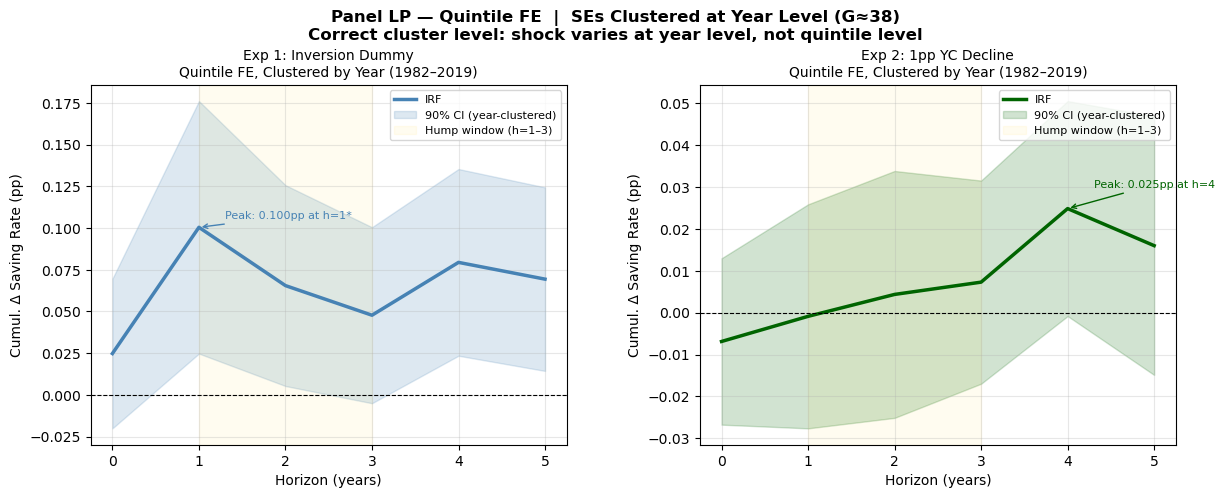


  PANEL LP — Quintile FE  |  Year-Clustered SEs  |  Full Sample
  [[coef]] = significant at 10%
  ───────────────────────────────────────────────────────────────
    h       Inv β                Inv CI       Neg β                Neg CI
  ───────────────────────────────────────────────────────────────
    0       0.025       [-0.020, 0.070]      -0.007       [-0.027, 0.013]
    1   [[0.100]]        [0.025, 0.176]      -0.001       [-0.028, 0.026]
    2   [[0.065]]        [0.005, 0.126]       0.004       [-0.025, 0.034]
    3       0.048       [-0.005, 0.100]       0.007       [-0.017, 0.032]
    4   [[0.079]]        [0.023, 0.135]       0.025       [-0.001, 0.051]
    5   [[0.069]]        [0.014, 0.124]       0.016       [-0.015, 0.047]


In [ ]:
##############################################################################
# PANEL LP — Quintile Fixed Effects + Year-level clustering (corrected)
##############################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings("ignore")

MAX_H  = 5
ALPHA  = 0.10
P_LAGS = 2

LAG_CONTROLS = (
    [f"PSR_L{l}"    for l in range(1, P_LAGS + 1)] +
    [f"Spread_L{l}" for l in range(1, P_LAGS + 1)]
)

def estimate_panel_lp_qfe(df, start_year, end_year, x_var, max_h=MAX_H):
    """
    Panel LP with quintile fixed effects and SEs clustered at year level.
    Clustering at year level is correct because the shock (Inversion /
    Neg_Spread) varies only at the year level, not within year across
    quintiles. See Cameron & Miller (2015, Journal of Human Resources)
    on choosing the correct cluster level.
    """
    mask   = (df["year"] >= start_year) & (df["year"] <= end_year)
    df_sub = df[mask].copy()

    # Quintile dummies (Q1 = baseline, omitted)
    for q in [2, 3, 4, 5]:
        df_sub[f"D_q{q}"] = (df_sub["quintile"] == q).astype(float)
    q_dummies = [f"D_q{q}" for q in [2, 3, 4, 5]]

    lag_cols = [c for c in LAG_CONTROLS if c in df_sub.columns]

    results = []
    for h in range(0, max_h + 1):
        outcome_col = f"y_h{h}"
        if outcome_col not in df_sub.columns:
            continue

        # No "interactions" here — that variable only exists in the
        # heterogeneous slopes function. This function only uses
        # q_dummies for the fixed effects.
        cols_needed = (
            [outcome_col, x_var, "year", "quintile"]
            + q_dummies
            + lag_cols
        )
        sub = df_sub[cols_needed].dropna()

        if len(sub) < 30:
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})
            continue

        # Design matrix: const + shock + quintile dummies + lag controls
        feature_cols = [x_var] + q_dummies + lag_cols
        X = pd.concat(
            [pd.Series(1.0, index=sub.index, name="const"),
             sub[feature_cols]],
            axis=1
        ).astype(float)
        y    = sub[outcome_col].astype(float)
        Xmat = X.values
        yvec = y.values

        try:
            XtX_inv = np.linalg.pinv(Xmat.T @ Xmat)
            beta    = XtX_inv @ (Xmat.T @ yvec)
            resid   = yvec - Xmat @ beta
            n, k    = Xmat.shape

            # Cluster at YEAR level (G ≈ 38)
            clusters  = sub["year"].values
            unique_cl = np.unique(clusters)
            G         = len(unique_cl)

            meat = np.zeros((k, k))
            for cl in unique_cl:
                idx   = clusters == cl
                score = Xmat[idx].T @ resid[idx]
                meat += np.outer(score, score)

            # Small-sample correction: (G/(G-1)) * ((n-1)/(n-k))
            correction = (G / (G - 1)) * ((n - 1) / (n - k))
            V_cl       = correction * XtX_inv @ meat @ XtX_inv
            se_vec     = np.sqrt(np.diag(V_cl))

            coef_val = beta[1]      # x_var is position 1 (after const)
            se_val   = se_vec[1]
            t_crit   = scipy_stats.t.ppf(1 - ALPHA / 2, df=G - 1)

            results.append({
                "h":       h,
                "coef":    coef_val,
                "se":      se_val,
                "ci_low":  coef_val - t_crit * se_val,
                "ci_high": coef_val + t_crit * se_val,
            })
        except np.linalg.LinAlgError:
            results.append({"h": h, "coef": np.nan, "se": np.nan,
                            "ci_low": np.nan, "ci_high": np.nan})

    return pd.DataFrame(results)


# ── Estimate ──────────────────────────────────────────────────────────────────
print("Estimating Panel LP with Quintile FE — full sample (1982–2019)…")
irf_qfe_inv = estimate_panel_lp_qfe(df_lp_q, 1982, 2019, "Inversion")
irf_qfe_neg = estimate_panel_lp_qfe(df_lp_q, 1982, 2019, "Neg_Spread")
print(f"  Clustering at year level — G = ~38 clusters")
print("Done.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, irf, title, color in [
    (axes[0], irf_qfe_inv,
     "Exp 1: Inversion Dummy\nQuintile FE, Clustered by Year (1982–2019)",
     "steelblue"),
    (axes[1], irf_qfe_neg,
     "Exp 2: 1pp YC Decline\nQuintile FE, Clustered by Year (1982–2019)",
     "darkgreen"),
]:
    ax.plot(irf["h"], irf["coef"], color=color, linewidth=2.5, label="IRF")
    ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                    alpha=0.18, color=color, label="90% CI (year-clustered)")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvspan(1, 3, alpha=0.06, color="gold", label="Hump window (h=1–3)")

    valid = irf.dropna(subset=["coef"])
    if not valid.empty:
        peak_idx = valid["coef"].idxmax()
        r        = valid.loc[peak_idx]
        sig      = r["ci_low"] > 0 or r["ci_high"] < 0
        ax.annotate(
            f"Peak: {r['coef']:.3f}pp at h={int(r['h'])}{'*' if sig else ''}",
            xy=(r["h"], r["coef"]),
            xytext=(r["h"] + 0.3, r["coef"] + 0.005),
            arrowprops=dict(arrowstyle="->", color=color),
            fontsize=8, color=color)

    ax.set_xlabel("Horizon (years)", fontsize=10)
    ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Panel LP — Quintile FE  |  SEs Clustered at Year Level (G≈38)\n"
    "Correct cluster level: shock varies at year level, not quintile level",
    fontsize=12, fontweight="bold"
)
plt.subplots_adjust(top=0.83, wspace=0.28)
plt.savefig("panel_lp_qfe_yearclustered.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Coefficient table ─────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print("  PANEL LP — Quintile FE  |  Year-Clustered SEs  |  Full Sample")
print(f"  [[coef]] = significant at 10%")
print(f"  {'─'*63}")
print(f"  {'h':>3}  {'Inv β':>10}  {'Inv CI':>20}  {'Neg β':>10}  {'Neg CI':>20}")
print(f"  {'─'*63}")

for h in range(0, MAX_H + 1):
    ri = irf_qfe_inv[irf_qfe_inv["h"] == h].iloc[0]
    rn = irf_qfe_neg[irf_qfe_neg["h"] == h].iloc[0]

    def fmt(r):
        if pd.isna(r["coef"]):
            return "—", "—"
        sig  = (r["ci_low"] > 0) or (r["ci_high"] < 0)
        coef = f"[[{r['coef']:.3f}]]" if sig else f"{r['coef']:.3f}"
        ci   = f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]"
        return coef, ci

    ci_i, s_i = fmt(ri)
    ci_n, s_n = fmt(rn)
    print(f"  {h:>3}  {ci_i:>10}  {s_i:>20}  {ci_n:>10}  {s_n:>20}")

#### 4.3.2 Heterogeneous slopes: shock x quintile interaction

Estimating heterogeneous-slope Panel LP — full sample (1982–2019)…
Done.


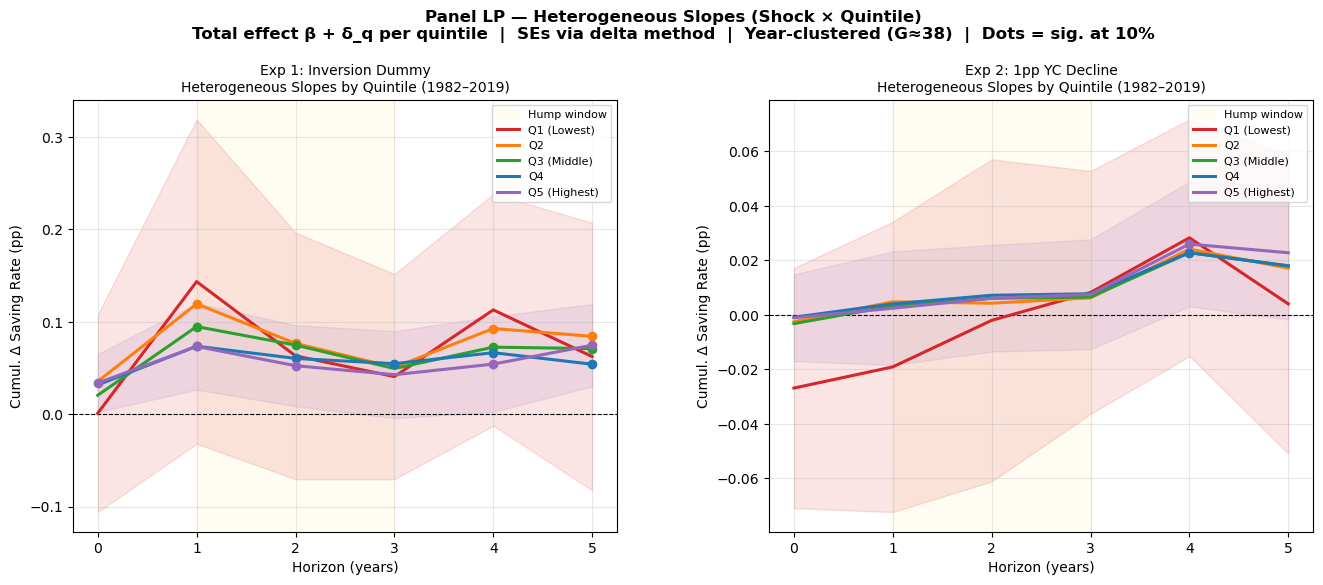


  HETEROGENEOUS SLOPES — Peak β per quintile
  Exp 2: 1pp YC Decline  |  Full Sample (1982–2019)
  Total effect = β_Q1 + δ_q  |  Delta method SE  |  Year-clustered
  ──────────────────────────────────────────────────────────────────────
  Quintile           Peak β   at h       SE   CI_low  CI_high   Sig?
  ──────────────────────────────────────────────────────────────────────
  Q1 (Lowest)         0.028      4    0.026   -0.015    0.072       
  Q2                  0.024      4    0.018   -0.007    0.055       
  Q3 (Middle)         0.023      4    0.015   -0.002    0.048       
  Q4                  0.023      4    0.013    0.000    0.046      ✓
  Q5 (Highest)        0.026      4    0.014    0.003    0.049      ✓

  Hypothesis: Q1 peak β < Q5 peak β
  Q1 peak = 0.028  |  Q5 peak = 0.026  →  Q1 > Q5 ✗ hypothesis rejected


In [74]:
##############################################################################
# PANEL LP — Heterogeneous Slopes (Shock × Quintile Interaction)
# Year-level clustering (corrected)
##############################################################################

def estimate_panel_lp_interact(df, start_year, end_year, x_var, max_h=MAX_H):
    """
    Panel LP with quintile FE AND shock × quintile interactions.

    The interaction terms δ_q (q=2..5) test whether quintile q responds
    differently from Q1. The total effect for quintile q is β + δ_q.
    SEs clustered at year level (G ≈ 38) — correct level because the
    shock varies only at the year level, not within year across quintiles.
    See Cameron & Miller (2015, Journal of Human Resources).
    Delta method used for SE of total effect β + δ_q per quintile.
    """
    mask   = (df["year"] >= start_year) & (df["year"] <= end_year)
    df_sub = df[mask].copy()

    for q in [2, 3, 4, 5]:
        df_sub[f"D_q{q}"]         = (df_sub["quintile"] == q).astype(float)
        df_sub[f"{x_var}_x_q{q}"] = df_sub[x_var] * df_sub[f"D_q{q}"]

    q_dummies    = [f"D_q{q}"         for q in [2, 3, 4, 5]]
    interactions = [f"{x_var}_x_q{q}" for q in [2, 3, 4, 5]]
    lag_cols     = [c for c in LAG_CONTROLS if c in df_sub.columns]

    # Position of each coefficient in the design matrix:
    # const(0), x_var(1), q_dummies(2-5), interactions(6-9), lag_cols(10+)
    x_var_pos    = 1
    interact_pos = {q: 1 + 1 + 4 + i for i, q in enumerate([2, 3, 4, 5])}

    results_pooled = []
    results_by_q   = {q: [] for q in [1, 2, 3, 4, 5]}

    for h in range(0, max_h + 1):
        outcome_col = f"y_h{h}"
        if outcome_col not in df_sub.columns:
            continue

        cols_needed = (
            [outcome_col, x_var, "year", "quintile"]
            + q_dummies
            + interactions
            + lag_cols
        )
        sub = df_sub[cols_needed].dropna()

        if len(sub) < 30:
            results_pooled.append({"h": h, "coef": np.nan, "se": np.nan,
                                   "ci_low": np.nan, "ci_high": np.nan})
            for q in [1, 2, 3, 4, 5]:
                results_by_q[q].append({"h": h, "coef": np.nan, "se": np.nan,
                                        "ci_low": np.nan, "ci_high": np.nan})
            continue

        X = pd.concat(
            [pd.Series(1.0, index=sub.index, name="const"),
             sub[[x_var] + q_dummies + interactions + lag_cols]],
            axis=1
        ).astype(float)
        y    = sub[outcome_col].astype(float)
        Xmat = X.values
        yvec = y.values

        try:
            XtX_inv = np.linalg.pinv(Xmat.T @ Xmat)
            beta    = XtX_inv @ (Xmat.T @ yvec)
            resid   = yvec - Xmat @ beta
            n, k    = Xmat.shape

            # Cluster at YEAR level
            clusters  = sub["year"].values
            unique_cl = np.unique(clusters)
            G         = len(unique_cl)

            meat = np.zeros((k, k))
            for cl in unique_cl:
                idx   = clusters == cl
                score = Xmat[idx].T @ resid[idx]
                meat += np.outer(score, score)

            correction = (G / (G - 1)) * ((n - 1) / (n - k))
            V_cl       = correction * XtX_inv @ meat @ XtX_inv
            se_vec     = np.sqrt(np.diag(V_cl))
            t_crit     = scipy_stats.t.ppf(1 - ALPHA / 2, df=G - 1)

            # Q1 baseline effect (β only, no interaction)
            b1  = beta[x_var_pos]
            se1 = se_vec[x_var_pos]
            results_pooled.append({
                "h": h, "coef": b1, "se": se1,
                "ci_low":  b1 - t_crit * se1,
                "ci_high": b1 + t_crit * se1,
            })
            results_by_q[1].append({
                "h": h, "coef": b1, "se": se1,
                "ci_low":  b1 - t_crit * se1,
                "ci_high": b1 + t_crit * se1,
            })

            # Q2–Q5 total effect = β + δ_q (delta method SE)
            for q in [2, 3, 4, 5]:
                pos    = interact_pos[q]
                bq     = b1 + beta[pos]

                # Var(β + δ_q) = Var(β) + Var(δ_q) + 2·Cov(β, δ_q)
                var_sum = (V_cl[x_var_pos, x_var_pos] +
                           V_cl[pos, pos] +
                           2 * V_cl[x_var_pos, pos])
                se_sum  = np.sqrt(max(var_sum, 0))
                results_by_q[q].append({
                    "h":       h,
                    "coef":    bq,
                    "se":      se_sum,
                    "ci_low":  bq - t_crit * se_sum,
                    "ci_high": bq + t_crit * se_sum,
                })

        except np.linalg.LinAlgError:
            results_pooled.append({"h": h, "coef": np.nan, "se": np.nan,
                                   "ci_low": np.nan, "ci_high": np.nan})
            for q in [1, 2, 3, 4, 5]:
                results_by_q[q].append({"h": h, "coef": np.nan, "se": np.nan,
                                        "ci_low": np.nan, "ci_high": np.nan})

    return (pd.DataFrame(results_pooled),
            {q: pd.DataFrame(v) for q, v in results_by_q.items()})


# ── Estimate ──────────────────────────────────────────────────────────────────
print("Estimating heterogeneous-slope Panel LP — full sample (1982–2019)…")

pooled_inv, by_q_inv = estimate_panel_lp_interact(
    df_lp_q, 1982, 2019, "Inversion")
pooled_neg, by_q_neg = estimate_panel_lp_interact(
    df_lp_q, 1982, 2019, "Neg_Spread")

print("Done.")

# ── Plot: Q1–Q5 overlaid for each experiment ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, by_q, title in [
    (axes[0], by_q_inv,
     "Exp 1: Inversion Dummy\nHeterogeneous Slopes by Quintile (1982–2019)"),
    (axes[1], by_q_neg,
     "Exp 2: 1pp YC Decline\nHeterogeneous Slopes by Quintile (1982–2019)"),
]:
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvspan(1, 3, alpha=0.05, color="gold", label="Hump window")

    for q in QUINTILES:
        irf   = by_q[q]
        color = Q_COLORS[q]
        label = Q_LABELS[q]

        if irf.empty or irf["coef"].isna().all():
            continue

        ax.plot(irf["h"], irf["coef"],
                color=color, linewidth=2.2, label=label)

        # CI shading only for Q1 and Q5 to avoid visual clutter
        if q in [1, 5]:
            ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                            alpha=0.12, color=color)

        # Dot on significant horizons
        for _, r in irf.iterrows():
            if pd.notna(r["ci_low"]) and (r["ci_low"] > 0 or r["ci_high"] < 0):
                ax.plot(r["h"], r["coef"], "o",
                        color=color, markersize=6, zorder=4)

    ax.set_xlabel("Horizon (years)", fontsize=10)
    ax.set_ylabel("Cumul. Δ Saving Rate (pp)", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

plt.suptitle(
    "Panel LP — Heterogeneous Slopes (Shock × Quintile)\n"
    "Total effect β + δ_q per quintile  |  SEs via delta method  "
    "|  Year-clustered (G≈38)  |  Dots = sig. at 10%",
    fontsize=12, fontweight="bold"
)
plt.subplots_adjust(top=0.83, wspace=0.28)
plt.savefig("panel_lp_interact_yearclustered.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary peak table ────────────────────────────────────────────────────────
print(f"\n{'='*72}")
print("  HETEROGENEOUS SLOPES — Peak β per quintile")
print("  Exp 2: 1pp YC Decline  |  Full Sample (1982–2019)")
print(f"  Total effect = β_Q1 + δ_q  |  Delta method SE  |  Year-clustered")
print(f"  {'─'*70}")
print(f"  {'Quintile':<16} {'Peak β':>8} {'at h':>6} "
      f"{'SE':>8} {'CI_low':>8} {'CI_high':>8} {'Sig?':>6}")
print(f"  {'─'*70}")

for q in QUINTILES:
    irf   = by_q_neg[q]
    valid = irf.dropna(subset=["coef"])
    if valid.empty:
        print(f"  {Q_LABELS[q]:<16} {'—':>8}")
        continue
    peak_idx = valid["coef"].abs().idxmax()
    r        = valid.loc[peak_idx]
    sig      = "✓" if (r["ci_low"] > 0 or r["ci_high"] < 0) else ""
    print(f"  {Q_LABELS[q]:<16} {r['coef']:>8.3f} {int(r['h']):>6} "
          f"{r['se']:>8.3f} {r['ci_low']:>8.3f} {r['ci_high']:>8.3f} {sig:>6}")

print(f"\n  Hypothesis: Q1 peak β < Q5 peak β")
b1_df = by_q_neg[1].dropna(subset=["coef"])
b5_df = by_q_neg[5].dropna(subset=["coef"])
if not b1_df.empty and not b5_df.empty:
    v1 = b1_df.loc[b1_df["coef"].abs().idxmax(), "coef"]
    v5 = b5_df.loc[b5_df["coef"].abs().idxmax(), "coef"]
    direction = ("Q1 < Q5 ✓ hypothesis supported"
                 if v1 < v5 else "Q1 > Q5 ✗ hypothesis rejected")
    print(f"  Q1 peak = {v1:.3f}  |  Q5 peak = {v5:.3f}  →  {direction}")